<a href="https://colab.research.google.com/github/momomonk/emotional-patterns-XIA/blob/main/User_modular_version_of_emotional_patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from graphviz import Digraph
from IPython.display import display

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# PROFUNDIDAD DE CADA NODO
# ============================================
# Instalar soporte para archivos RAR
!apt-get install -y unrar

# Extraer el archivo RAR
!unrar x cremad.rar

EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}
# ============================================
# CLASES PRESENTES BAJO UN NODO
# ============================================
# ============================================
# VISUALIZACIÓN TEXTUAL DEL SUBÁRBOL
# ============================================
# ============================================
# VISUALIZACIÓN GRÁFICA LIGERA (GRAPHVIZ)
# ============================================
def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()
from graphviz import Digraph

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):

    # ===== Path real del audio =====
    if sample_id is not None:
        path_nodes = {step["node"] for step in predict_path(sample_id)[0]}
    else:
        path_nodes = set()

    # ===== Nodos donde aparece el feature =====
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root = nodes[0]["node_id"]

    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")

    visited = set()
    subtree_nodes = set()

    def recurse(node, depth):
        if depth > max_depth or node in visited:
            return

        visited.add(node)
        subtree_nodes.add(node)

        # ===== Hoja =====
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            is_path = node in path_nodes

            dot.node(
                str(node),
                label=f"🍂 Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                shape="box",
                style="filled",
                fillcolor="#ffcccc" if is_path else "#eaffea",
                color="red" if is_path else "black",
                penwidth="3" if is_path else "1"
            )
            return

        # ===== Nodo interno =====
        feat = tree.feature[node]
        thr = tree.threshold[node]
        lvl = NODE_DEPTH[node]

        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        is_path = node in path_nodes
        r2 = get_r2(str(feat))

        #r2 = get_r2(feature_name)

        dot.node(
            str(node),
            label = (
                f"Nodo {node} (lvl {lvl})\n"
                f"feature {feat} ≤ {thr:.4f}\n"
                f"r² LASSO: {r2:.3f}\n"
                f"Clases: {', '.join(class_names)}"
            )
            ,
            shape="ellipse",
            style="filled",
            fillcolor="#ffd6d6" if is_path else "#eef4ff",
            color="red" if is_path else "black",
            penwidth="3" if is_path else "1"
        )

        for child, edge_label in [
            (tree.children_left[node], "TRUE"),
            (tree.children_right[node], "FALSE")
        ]:
            dot.edge(str(node), str(child), label=edge_label)
            recurse(child, depth + 1)

    recurse(root, 0)

    # ===== Aviso claro si el path no pasa por este feature =====
    if sample_id is not None and path_nodes.isdisjoint(subtree_nodes):
        print("ℹ️ El audio NO recorre este subárbol (el feature no está en su path).")

    return dot


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ Inicializar profundidad de nodos
NODE_DEPTH = np.zeros(tree.node_count, dtype=int)
stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))


# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)
show_general_checkbox = widgets.Checkbox(
    value=False,
    description="Información del Feature",
    indent=False
)

# ▪ Checkboxes para mostrar/ocultar secciones
show_graph_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Grafico del subárbol",
    indent=False
)

show_path_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Recorrido del árbol",
    indent=False
)

show_samples_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Ejemplos de clasificación",
    indent=False
)
show_top_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar Tabla de Top 10 coeficientes",
    indent=False
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================
def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print(f"\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # Si "Mostrar General" está activo, se muestran todas las secciones
        if show_general_checkbox.value:
            mostrar_lasso(feature_name)
            mostrar_nodos(feature_name)
            mostrar_valor_audio(feature_name, sample_id)
            mostrar_clase_predicha(sample_id)
        if show_graph_checkbox.value:
            mostrar_subarbol(feature_name)
        if show_path_checkbox.value:
            mostrar_recorrido(feature_name, sample_id)

        if show_top_checkbox.value:
            mostrar_top_r2(10)
        if show_samples_checkbox.value:
            print("\nPROCESANDO ...\n")
            mostrar_audios(feature_name)
            print("\nPROCESADO ...\n")
def mostrar_lasso(feature_name):
    lasso_info = get_lasso_info(feature_name)
    print("\n==============================")
    print("📊 Info LASSO")
    print("==============================")
    if lasso_info:
        print(f"  • r²: {lasso_info['r2']:.5f}")
        print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
        print(f"  • Variables originales:")
        for v in lasso_info["vars"]:
            print("    -", v)
    else:
        print("⚠️ No se encontró información LASSO.")

def mostrar_nodos(feature_name):
    print("\n==============================")
    print("🌳 Nodos del árbol donde aparece el feature")
    print("==============================")
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
    else:
        for n in nodes:
            print(f"➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

def mostrar_subarbol(feature_name):
    print("\n==============================")
    print("🌿 Subárbol del Feature Seleccionado")
    print("==============================")
    subtree_graph = visualize_feature_subtree(feature_name)
    if subtree_graph:
        display(subtree_graph)

def mostrar_valor_audio(feature_name, sample_id):
    val = get_feature_value(feature_name, sample_id)
    print("\n==============================")
    print(f"🎧 Valor del feature para ID {sample_id}: {val}")
    print("==============================\n")

def mostrar_recorrido(feature_name, sample_id):
    print("\n==============================")
    print("🛣️ Recorrido completo del árbol")
    print("==============================")
    path, pred_class = predict_path(sample_id)
    for step in path:
        node = step['node']
        lvl = NODE_DEPTH[node]
        feat = step['feature']
        thr = step['threshold']
        val_node = step['value']
        decision = step['decision']
        left_classes = classes_under_node(tree.children_left[node])
        right_classes = classes_under_node(tree.children_right[node])
        r2_value = get_r2(feat)

        print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
        print(f"  Valor real: {val_node} → {'TRUE' if decision else 'FALSE'}")
        print(f"  r²: {r2_value:.5f}")
        print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
        print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])

def mostrar_clase_predicha(sample_id):
    _, pred_class = predict_path(sample_id)
    emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]
    print("\n==============================")
    print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
    print("==============================")

def mostrar_audios(feature_name):
    print("\n==============================")
    print(f"🎧 Audios que pasan por el feature {feature_name}")
    print("==============================\n")
    feature_nodes = [n['node_id'] for n in find_feature_nodes(feature_name)]
    samples_through_feature = []

    for sample_id in df_features["id"]:
        current = 0
        path_nodes = []
        while tree.feature[current] != _tree.TREE_UNDEFINED:
            path_nodes.append(current)
            feat = str(tree.feature[current])
            thr = tree.threshold[current]
            val = df_features[df_features["id"] == sample_id].iloc[0][feat]
            current = tree.children_left[current] if val <= thr else tree.children_right[current]
        path_nodes.append(current)  # hoja final

        if any(n in path_nodes for n in feature_nodes):
            samples_through_feature.append({
                "sample_id": sample_id,
                "leaf_node": current
            })

    # Agrupar por hoja
    from collections import defaultdict
    leaf_groups = defaultdict(list)
    for s in samples_through_feature:
        leaf_groups[s['leaf_node']].append(s['sample_id'])

    for leaf, ids in leaf_groups.items():
        print(f"Hoja {leaf} ({len(ids)} audios):")
        for i in ids:
            print("  -", i)
def mostrar_top_r2(n=10):
    top_r2 = df_lasso.sort_values(by="r2", ascending=False).head(n)
    print(f"\n==============================")
    print(f"🏆 Top {n} features según r² LASSO")
    print("==============================")
    for i, row in enumerate(top_r2.itertuples(), 1):
        feature = row.embedding_feature
        r2_val = row.r2
        n_vars = row.n_vars_used
        print(f"{i}. Feature: {feature} | r²: {r2_val:.5f} | Variables usadas: {n_vars}")


btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, show_general_checkbox, show_path_checkbox, show_graph_checkbox, show_top_checkbox,show_samples_checkbox, btn, output)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from cremad.rar

Creating    cremad                                                    OK
Creating    cremad/results                                            OK
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv       0%  OK 
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv       0%  OK 
Creating    cremad/surrogate                                          OK
Extracting  cremad/surrogate/features_surrogate_features1.csv             36%  OK 
Extracting  cremad/surrogate/surrogate_model1.pkl                         36%  OK 
Extracting  cremad/surrogate/surrogate_tree1.txt            

## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Checkbox(value=False, description='Información del Feature', indent=False)

...

Checkbox(value=False, description='Mostrar Grafico del subárbol', indent=False)

Checkbox(value=True, description='Mostrar Tabla de Top 10 coeficientes', indent=False)

Checkbox(value=False, description='Mostrar Ejemplos de clasificación', indent=False)

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
#Examples of few parts of the code, by the transition of modularization in different Generations of the Hibrid model to Cnn basic: System, Auxiliar models and Personal Notes structure, examples or references
##Leyend:
## Decision tree(DT), Progaming oriented to object(POO), Vision transformer (VIT)
## Types of Embedding (x/y), features (metadata/opensmile/tag), class(POO or emotion id(5)), Characteristics(Vocal Characteristics)
## Emotion id - Class: Anger (0), Disgust (1), Fear (2), Happy (3), Neutral (4), Sad (5).

In [ ]:
#USER MODULE

In [ ]:
# Instalar soporte para archivos RAR
!apt-get install -y unrar

# Extraer el archivo RAR
!unrar x cremad.rar


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from cremad.rar

Creating    cremad/results                                            OK
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv       0%  OK 
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv       0%  OK 
Creating    cremad/surrogate                                          OK
Extracting  cremad/surrogate/features_surrogate_features1.csv             36%  OK 
Extracting  cremad/surrogate/surrogate_model1.pkl                         36%  OK 
Extracting  cremad/surrogate/surrogate_tree1.txt                          36%  OK 
Extracting  cremad/val_df (5).csv        

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from graphviz import Digraph
from IPython.display import display

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# PROFUNDIDAD DE CADA NODO
# ============================================
# Instalar soporte para archivos RAR
!apt-get install -y unrar

# Extraer el archivo RAR
!unrar x cremad.rar

EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}
# ============================================
# CLASES PRESENTES BAJO UN NODO
# ============================================
# ============================================
# VISUALIZACIÓN TEXTUAL DEL SUBÁRBOL
# ============================================
# ============================================
# VISUALIZACIÓN GRÁFICA LIGERA (GRAPHVIZ)
# ============================================
def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()
from graphviz import Digraph

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):

    # ===== Path real del audio =====
    if sample_id is not None:
        path_nodes = {step["node"] for step in predict_path(sample_id)[0]}
    else:
        path_nodes = set()

    # ===== Nodos donde aparece el feature =====
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root = nodes[0]["node_id"]

    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")

    visited = set()
    subtree_nodes = set()

    def recurse(node, depth):
        if depth > max_depth or node in visited:
            return

        visited.add(node)
        subtree_nodes.add(node)

        # ===== Hoja =====
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            is_path = node in path_nodes

            dot.node(
                str(node),
                label=f"🍂 Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                shape="box",
                style="filled",
                fillcolor="#ffcccc" if is_path else "#eaffea",
                color="red" if is_path else "black",
                penwidth="3" if is_path else "1"
            )
            return

        # ===== Nodo interno =====
        feat = tree.feature[node]
        thr = tree.threshold[node]
        lvl = NODE_DEPTH[node]

        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        is_path = node in path_nodes
        r2 = get_r2(str(feat))

        #r2 = get_r2(feature_name)

        dot.node(
            str(node),
            label = (
                f"Nodo {node} (lvl {lvl})\n"
                f"feature {feat} ≤ {thr:.4f}\n"
                f"r² LASSO: {r2:.3f}\n"
                f"Clases: {', '.join(class_names)}"
            )
            ,
            shape="ellipse",
            style="filled",
            fillcolor="#ffd6d6" if is_path else "#eef4ff",
            color="red" if is_path else "black",
            penwidth="3" if is_path else "1"
        )

        for child, edge_label in [
            (tree.children_left[node], "TRUE"),
            (tree.children_right[node], "FALSE")
        ]:
            dot.edge(str(node), str(child), label=edge_label)
            recurse(child, depth + 1)

    recurse(root, 0)

    # ===== Aviso claro si el path no pasa por este feature =====
    if sample_id is not None and path_nodes.isdisjoint(subtree_nodes):
        print("ℹ️ El audio NO recorre este subárbol (el feature no está en su path).")

    return dot


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ Inicializar profundidad de nodos
NODE_DEPTH = np.zeros(tree.node_count, dtype=int)
stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))


# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)
show_general_checkbox = widgets.Checkbox(
    value=False,
    description="Información del Feature",
    indent=False
)

# ▪ Checkboxes para mostrar/ocultar secciones
show_graph_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Grafico del subárbol",
    indent=False
)

show_path_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Recorrido del árbol",
    indent=False
)

show_samples_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar Ejemplos de clasificación",
    indent=False
)
show_top_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar Tabla de Top 10 coeficientes",
    indent=False
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================
def analizar_click(b):

    output.clear_output()

    with output:
        try:
            feature_name = feature_dropdown.value
            sample_id = id_dropdown.value

            print(f"\n==============================")
            print(f"🔍 Feature seleccionado: {feature_name}")
            print("==============================\n")

            if show_general_checkbox.value:
                mostrar_lasso(feature_name)
                mostrar_nodos(feature_name)
                mostrar_valor_audio(feature_name, sample_id)
                mostrar_clase_predicha(sample_id)

            if show_graph_checkbox.value:
                mostrar_subarbol(feature_name)

            if show_path_checkbox.value:
                mostrar_recorrido(feature_name, sample_id)

            if show_top_checkbox.value:
                mostrar_top_r2(10)

            if show_samples_checkbox.value:
                mostrar_audios(feature_name)

        except Exception as e:
            print("❌ ERROR CONTROLADO")
            print("El sistema no se cerró.")
            print("Detalle:", str(e))

def mostrar_lasso(feature_name):
    lasso_info = get_lasso_info(feature_name)
    print("\n==============================")
    print("📊 Info LASSO")
    print("==============================")
    if lasso_info:
        print(f"  • r²: {lasso_info['r2']:.5f}")
        print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
        print(f"  • Variables originales:")
        for v in lasso_info["vars"]:
            print("    -", v)
    else:
        print("⚠️ No se encontró información LASSO.")

def mostrar_nodos(feature_name):
    print("\n==============================")
    print("🌳 Nodos del árbol donde aparece el feature")
    print("==============================")
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
    else:
        for n in nodes:
            print(f"➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

def mostrar_subarbol(feature_name):
    print("\n==============================")
    print("🌿 Subárbol del Feature Seleccionado")
    print("==============================")
    subtree_graph = visualize_feature_subtree(feature_name)
    if subtree_graph:
        display(subtree_graph)

def mostrar_valor_audio(feature_name, sample_id):
    val = get_feature_value(feature_name, sample_id)
    print("\n==============================")
    print(f"🎧 Valor del feature para ID {sample_id}: {val}")
    print("==============================\n")

def sample_passes_feature(feature_name, sample_id):
    path, _ = predict_path(sample_id)
    return any(step["feature"] == feature_name for step in path)

def mostrar_recorrido(feature_name, sample_id):

    # 🔒 VERIFICACIÓN CLAVE
    if not sample_passes_feature(feature_name, sample_id):
        print("\n==============================")
        print("ℹ️ AVISO")
        print("==============================")
        print(f"El audio {sample_id} NO pasa por el feature {feature_name}.")
        print("No se muestra el recorrido para este feature.")
        return  # ⛔ SALE LIMPIO, NO ROMPE NADA

    print("\n==============================")
    print("🛣️ Recorrido completo del árbol")
    print("==============================")

    path, pred_class = predict_path(sample_id)

    for step in path:
        node = step['node']
        lvl = NODE_DEPTH[node]
        feat = step['feature']
        thr = step['threshold']
        val_node = step['value']
        decision = step['decision']
        left_classes = classes_under_node(tree.children_left[node])
        right_classes = classes_under_node(tree.children_right[node])
        r2_value = get_r2(feat)

        print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
        print(f"  Valor real: {val_node} → {'TRUE' if decision else 'FALSE'}")
        print(f"  r²: {r2_value:.5f}")
        print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
        print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])

def mostrar_clase_predicha(sample_id):
    _, pred_class = predict_path(sample_id)
    emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]
    print("\n==============================")
    print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
    print("==============================")

def mostrar_audios(feature_name):
    print("\n==============================")
    print(f"🎧 Audios que pasan por el feature {feature_name}")
    print("==============================\n")
    feature_nodes = [n['node_id'] for n in find_feature_nodes(feature_name)]
    samples_through_feature = []

    for sample_id in df_features["id"]:
        current = 0
        path_nodes = []
        while tree.feature[current] != _tree.TREE_UNDEFINED:
            path_nodes.append(current)
            feat = str(tree.feature[current])
            thr = tree.threshold[current]
            val = df_features[df_features["id"] == sample_id].iloc[0][feat]
            current = tree.children_left[current] if val <= thr else tree.children_right[current]
        path_nodes.append(current)  # hoja final

        if any(n in path_nodes for n in feature_nodes):
            samples_through_feature.append({
                "sample_id": sample_id,
                "leaf_node": current
            })

    # Agrupar por hoja
    from collections import defaultdict
    leaf_groups = defaultdict(list)
    for s in samples_through_feature:
        leaf_groups[s['leaf_node']].append(s['sample_id'])

    for leaf, ids in leaf_groups.items():
        print(f"Hoja {leaf} ({len(ids)} audios):")
        for i in ids:
            print("  -", i)
def mostrar_top_r2(n=10):
    top_r2 = df_lasso.sort_values(by="r2", ascending=False).head(n)
    print(f"\n==============================")
    print(f"🏆 Top {n} features según r² LASSO")
    print("==============================")
    for i, row in enumerate(top_r2.itertuples(), 1):
        feature = row.embedding_feature
        r2_val = row.r2
        n_vars = row.n_vars_used
        print(f"{i}. Feature: {feature} | r²: {r2_val:.5f} | Variables usadas: {n_vars}")


btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, show_general_checkbox, show_path_checkbox, show_graph_checkbox, show_top_checkbox,show_samples_checkbox, btn, output)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from cremad.rar

Creating    cremad                                                    OK
Creating    cremad/results                                            OK
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv       0%  OK 
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv       0%  OK 
Creating    cremad/surrogate                                          OK
Extracting  cremad/surrogate/features_surrogate_features1.csv             36%  OK 
Extracting  cremad/surrogate/surrogate_model1.pkl                         36%  OK 
Extracting  cremad/surrogate/surrogate_tree1.txt            

## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Checkbox(value=False, description='Información del Feature', indent=False)

...

Checkbox(value=False, description='Mostrar Grafico del subárbol', indent=False)

Checkbox(value=True, description='Mostrar Tabla de Top 10 coeficientes', indent=False)

Checkbox(value=False, description='Mostrar Ejemplos de clasificación', indent=False)

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from graphviz import Digraph
from IPython.display import display

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# PROFUNDIDAD DE CADA NODO
# ============================================
# Instalar soporte para archivos RAR
!apt-get install -y unrar

# Extraer el archivo RAR
!unrar x cremad.rar

NODE_DEPTH = np.zeros(tree.node_count, dtype=int)

stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))
EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}
# ============================================
# CLASES PRESENTES BAJO UN NODO
# ============================================
# ============================================
# VISUALIZACIÓN TEXTUAL DEL SUBÁRBOL
# ============================================
# ============================================
# VISUALIZACIÓN GRÁFICA LIGERA (GRAPHVIZ)
# ============================================
def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()
from graphviz import Digraph

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):

    # ===== Path real del audio =====
    if sample_id is not None:
        path_nodes = {step["node"] for step in predict_path(sample_id)[0]}
    else:
        path_nodes = set()

    # ===== Nodos donde aparece el feature =====
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root = nodes[0]["node_id"]

    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")

    visited = set()
    subtree_nodes = set()

    def recurse(node, depth):
        if depth > max_depth or node in visited:
            return

        visited.add(node)
        subtree_nodes.add(node)

        # ===== Hoja =====
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            is_path = node in path_nodes

            dot.node(
                str(node),
                label=f"🍂 Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                shape="box",
                style="filled",
                fillcolor="#ffcccc" if is_path else "#eaffea",
                color="red" if is_path else "black",
                penwidth="3" if is_path else "1"
            )
            return

        # ===== Nodo interno =====
        feat = tree.feature[node]
        thr = tree.threshold[node]
        lvl = NODE_DEPTH[node]

        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        is_path = node in path_nodes
        r2 = get_r2(str(feat))

        #r2 = get_r2(feature_name)

        dot.node(
            str(node),
            label = (
                f"Nodo {node} (lvl {lvl})\n"
                f"feature {feat} ≤ {thr:.4f}\n"
                f"r² LASSO: {r2:.3f}\n"
                f"Clases: {', '.join(class_names)}"
            )
            ,
            shape="ellipse",
            style="filled",
            fillcolor="#ffd6d6" if is_path else "#eef4ff",
            color="red" if is_path else "black",
            penwidth="3" if is_path else "1"
        )

        for child, edge_label in [
            (tree.children_left[node], "TRUE"),
            (tree.children_right[node], "FALSE")
        ]:
            dot.edge(str(node), str(child), label=edge_label)
            recurse(child, depth + 1)

    recurse(root, 0)

    # ===== Aviso claro si el path no pasa por este feature =====
    if sample_id is not None and path_nodes.isdisjoint(subtree_nodes):
        print("ℹ️ El audio NO recorre este subárbol (el feature no está en su path).")

    return dot


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Checkboxes para mostrar/ocultar secciones
show_graph_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar subárbol",
    indent=False
)

show_path_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar recorrido del árbol",
    indent=False
)

show_samples_checkbox = widgets.Checkbox(
    value=False,
    description="Mostrar audios del feature",
    indent=False
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================
def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print(f"\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Info LASSO --------
        lasso_info = get_lasso_info(feature_name)
        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        # -------- Nodos donde aparece el feature --------
        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")
        nodes = find_feature_nodes(feature_name)
        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
        else:
            for n in nodes:
                print(f"➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Subárbol gráfico --------
        if show_graph_checkbox.value:
            print("\n==============================")
            print("🌿 Subárbol del Feature Seleccionado")
            print("==============================")
            subtree_graph = visualize_feature_subtree(feature_name)
            if subtree_graph:
                display(subtree_graph)

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        if show_path_checkbox.value:
            print("\n==============================")
            print("🛣️ Recorrido completo del árbol")
            print("==============================")
            path, pred_class = predict_path(sample_id)
            for step in path:
                node = step['node']
                lvl = NODE_DEPTH[node]
                feat = step['feature']
                thr = step['threshold']
                val_node = step['value']
                decision = step['decision']
                left_classes = classes_under_node(tree.children_left[node])
                right_classes = classes_under_node(tree.children_right[node])
                r2_value = get_r2(feat)

                print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
                print(f"  Valor real: {val_node} → {'TRUE' if decision else 'FALSE'}")
                print(f"  r²: {r2_value:.5f}")
                print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
                print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])

        # -------- Clase predicha --------
        path, pred_class = predict_path(sample_id)
        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]
        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")
        # -------- Audios que pasan por el feature --------
        if show_samples_checkbox.value:
            feature_nodes = [n['node_id'] for n in find_feature_nodes(feature_name)]
            samples_through_feature = []

            for sample_id in df_features["id"]:
                current = 0
                path_nodes = []
                while tree.feature[current] != _tree.TREE_UNDEFINED:
                    path_nodes.append(current)
                    feat = str(tree.feature[current])
                    thr = tree.threshold[current]
                    val = df_features[df_features["id"] == sample_id].iloc[0][feat]
                    current = tree.children_left[current] if val <= thr else tree.children_right[current]
                path_nodes.append(current)  # hoja final

                if any(n in path_nodes for n in feature_nodes):
                    samples_through_feature.append({
                        "sample_id": sample_id,
                        "leaf_node": current
                    })

            # Agrupar por hoja
            from collections import defaultdict
            leaf_groups = defaultdict(list)
            for s in samples_through_feature:
                leaf_groups[s['leaf_node']].append(s['sample_id'])

            print("\n==============================")
            print(f"🎧 Audios que pasan por el feature {feature_name}")
            print("==============================\n")
            for leaf, ids in leaf_groups.items():
                print(f"Hoja {leaf} ({len(ids)} audios):")
                for i in ids:
                    print("  -", i)

btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, show_graph_checkbox, show_path_checkbox, show_samples_checkbox, btn, output)



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from cremad.rar


Would you like to replace the existing file cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv
 33739 bytes, modified on 2025-06-25 01:06
with a new one
 33739 bytes, modified on 2025-06-25 01:06

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit A

Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv       0%  OK 
Extracting  cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv       0%  OK 
Extracting  cremad/surrogate/features_surrogate_features1.csv             36%  OK 
Extracting  cremad/surrogate/surrogate_model1.pkl                         36%  OK 
Extracting  cr

## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Checkbox(value=True, description='Mostrar subárbol', indent=False)

Checkbox(value=True, description='Mostrar recorrido del árbol', indent=False)

Checkbox(value=False, description='Mostrar audios del feature', indent=False)

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from graphviz import Digraph

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))

print("✅ Archivos cargados OK")

# ============================================
# 2) PROFUNDIDAD DE CADA NODO
# ============================================

NODE_DEPTH = np.zeros(tree.node_count, dtype=int)

stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))

EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}

# ============================================
# FUNCIONES DE APOYO
# ============================================

def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()

def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes

def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# VISUALIZACIÓN GRÁFICA
# ============================================

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):
    from graphviz import Digraph

    path_nodes = set()
    if sample_id is not None:
        path_nodes = {step["node"] for step in predict_path(sample_id)[0]}

    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root = nodes[0]["node_id"]
    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")

    visited = set()
    subtree_nodes = set()

    def recurse(node, depth):
        if depth > max_depth or node in visited:
            return
        visited.add(node)
        subtree_nodes.add(node)

        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            is_path = node in path_nodes
            dot.node(str(node),
                     label=f"Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                     shape="box",
                     style="filled",
                     fillcolor="#ffcccc" if is_path else "#eaffea")
            return

        feat = tree.feature[node]
        thr = tree.threshold[node]
        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        is_path = node in path_nodes
        r2 = get_r2(str(feat))

        dot.node(str(node),
                 label=f"Nodo {node} (lvl {NODE_DEPTH[node]})\nfeature {feat} ≤ {thr:.4f}\nr²: {r2:.3f}\nClases: {', '.join(class_names)}",
                 shape="ellipse",
                 style="filled",
                 fillcolor="#ffd6d6" if is_path else "#eef4ff")

        for child in [tree.children_left[node], tree.children_right[node]]:
            dot.edge(str(node), str(child))
            recurse(child, depth + 1)

    recurse(root, 0)

    if sample_id is not None and path_nodes.isdisjoint(subtree_nodes):
        print("ℹ️ El audio NO recorre este subárbol (el feature no está en su path).")

    return dot

# ============================================
# INTERFAZ INTERACTIVA
# ============================================

feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))
feature_dropdown = widgets.Dropdown(options=feature_list, description="Feature:")
id_list = sorted(df_features["id"].tolist())
id_dropdown = widgets.Dropdown(options=id_list, description="ID Audio:")

show_graph_checkbox = widgets.Checkbox(value=True, description="Mostrar subárbol", indent=False)
show_path_checkbox = widgets.Checkbox(value=True, description="Mostrar recorrido del árbol", indent=False)
show_samples_checkbox = widgets.Checkbox(value=False, description="Mostrar audios del feature", indent=False)
show_general_info_checkbox = widgets.Checkbox(value=True, description="Mostrar info general del feature", indent=False
)
output = widgets.Output()

# ===== NUEVO BOTÓN PARA INFO GENERAL =====
show_info = False
info_button = widgets.Button(description="Mostrar Info General", button_style="info")
def toggle_info(b):
    global show_info
    show_info = not show_info
    info_button.description = "Ocultar Info General" if show_info else "Mostrar Info General"
info_button.on_click(toggle_info)

btn = widgets.Button(description="Analizar", button_style="primary", icon="search")

# =======================================================
# FUNCION PRINCIPAL
# =======================================================

def analizar_click(b):
    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value
    output.clear_output()
    with output:
        if show_info:
            print("\n==============================")
            print("ℹ️ INFORMACIÓN GENERAL DEL SISTEMA")
            print("==============================")
            print(f"Número de nodos del árbol: {tree.node_count}")
            print(f"Número de features: {len(feature_list)}")
            print(f"Número de IDs: {len(id_list)}")
            print("==============================\n")

        print(f"\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Info LASSO --------
        lasso_info = get_lasso_info(feature_name)
        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        # -------- Nodos --------
        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")
        nodes = find_feature_nodes(feature_name)
        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
        else:
            for n in nodes:
                print(f"➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Subárbol gráfico --------
        if show_graph_checkbox.value:
            print("\n==============================")
            print("🌿 Subárbol del Feature Seleccionado")
            print("==============================")
            subtree_graph = visualize_feature_subtree(feature_name)
            if subtree_graph:
                display(subtree_graph)

        # -------- Valor del feature --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")
        # -------- Info general del feature --------
        if show_general_info_checkbox.value:
            feature_values = df_features[feature_name]
            print("ℹ️ Información general del feature:")
            print(f"  • Media: {feature_values.mean():.5f}")
            print(f"  • Desviación estándar: {feature_values.std():.5f}")
            print(f"  • Mínimo: {feature_values.min():.5f}")
            print(f"  • Máximo: {feature_values.max():.5f}")
            print(f"  • Número de muestras: {len(feature_values)}\n")

btn.on_click(analizar_click)

display(Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate"))
display(feature_dropdown, id_dropdown, show_graph_checkbox, show_path_checkbox, show_samples_checkbox, info_button, btn, output)


✅ Archivos cargados OK


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Checkbox(value=True, description='Mostrar subárbol', indent=False)

Checkbox(value=True, description='Mostrar recorrido del árbol', indent=False)

Checkbox(value=False, description='Mostrar audios del feature', indent=False)

Button(button_style='info', description='Mostrar Info General', style=ButtonStyle())

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
from graphviz import Digraph

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO (opcional)
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [
    c.replace("feature_", "") if c.startswith("feature_") else c
    for c in df_features.columns
]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(
    lambda x: x.replace("feature_", "")
)

# ============================================
# 3) NODOS Y PROFUNDIDAD
# ============================================

NODE_DEPTH = np.zeros(tree.node_count, dtype=int)
stack = [(0, 0)]
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))

EMOTION_NAMES = {
    0: "Anger", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Neutral", 5: "Sad"
}

# ============================================
# 4) FUNCIONES DEL SISTEMA
# ============================================

def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()

def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty: return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes

def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]
        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]
        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    return info['r2'] if info else 0.0

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        return None
    root = nodes[0]["node_id"]
    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")
    visited = set()

    path_nodes = {step["node"] for step in predict_path(sample_id)[0]} if sample_id else set()

    def recurse(node, depth):
        if depth > max_depth or node in visited: return
        visited.add(node)
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            dot.node(
                str(node),
                label=f"Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                shape="box",
                style="filled",
                fillcolor="#ffcccc" if node in path_nodes else "#eaffea"
            )
            return
        feat = tree.feature[node]
        thr = tree.threshold[node]
        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        r2 = get_r2(str(feat))
        dot.node(
            str(node),
            label=f"Nodo {node} (lvl {NODE_DEPTH[node]})\nfeature {feat} ≤ {thr:.4f}\nr² LASSO: {r2:.3f}\nClases: {', '.join(class_names)}",
            shape="ellipse",
            style="filled",
            fillcolor="#ffd6d6" if node in path_nodes else "#eef4ff"
        )
        for child, label_edge in [(tree.children_left[node], "TRUE"), (tree.children_right[node], "FALSE")]:
            dot.edge(str(node), str(child), label=label_edge)
            recurse(child, depth + 1)

    recurse(root, 0)
    return dot

# ============================================
# 5) INTERFAZ INTERACTIVA
# ============================================

feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))
feature_dropdown = widgets.Dropdown(options=feature_list, description="Feature:")
id_list = sorted(df_features["id"].tolist())
id_dropdown = widgets.Dropdown(options=id_list, description="ID Audio:")

show_graph_checkbox = widgets.Checkbox(value=True, description="Mostrar subárbol", indent=False)
show_path_checkbox = widgets.Checkbox(value=True, description="Mostrar recorrido del árbol", indent=False)
show_samples_checkbox = widgets.Checkbox(value=False, description="Mostrar audios del feature", indent=False)

btn = widgets.Button(description="Analizar", button_style="primary", icon="search")
output = widgets.Output()

# =======================================================
# 🔎 FUNCIÓN PRINCIPAL
# =======================================================

def analizar_click(b):
    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value
    output.clear_output()
    with output:
        print(f"🔍 Feature seleccionado: {feature_name}")
        lasso_info = get_lasso_info(feature_name)
        if lasso_info:
            print(f"r²: {lasso_info['r2']:.5f}, Num. vars usadas: {lasso_info['n_vars_used']}")
            print("Variables originales:", lasso_info["vars"])
        nodes = find_feature_nodes(feature_name)
        if nodes:
            print("Nodos del árbol donde aparece el feature:")
            for n in nodes:
                print(f" Nodo {n['node_id']}: ≤ {n['threshold']:.4f}")
        if show_graph_checkbox.value:
            subtree_graph = visualize_feature_subtree(feature_name)
            if subtree_graph: display(subtree_graph)
        val = get_feature_value(feature_name, sample_id)
        print(f"\nValor del feature para ID {sample_id}: {val}")
        if show_path_checkbox.value:
            path, pred_class = predict_path(sample_id)
            print("Recorrido del árbol:")
            for step in path:
                node = step['node']
                print(f" Nodo {node}: {step['feature']} ≤ {step['threshold']:.4f}, Valor real: {step['value']}, Decisión: {'TRUE' if step['decision'] else 'FALSE'}")
        _, pred_class = predict_path(sample_id)
        print(f"\nClase predicha: {EMOTION_NAMES[pred_class]}")

btn.on_click(analizar_click)

display(Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar."))
display(feature_dropdown, id_dropdown, show_graph_checkbox, show_path_checkbox, show_samples_checkbox, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Checkbox(value=True, description='Mostrar subárbol', indent=False)

Checkbox(value=True, description='Mostrar recorrido del árbol', indent=False)

Checkbox(value=False, description='Mostrar audios del feature', indent=False)

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# Feature seleccionado desde el dropdown
feature_name = feature_dropdown.value

# Encontrar todos los nodos donde aparece este feature
feature_nodes = [n['node_id'] for n in find_feature_nodes(feature_name)]

# Lista de audios que pasan por alguno de esos nodos
samples_through_feature = []

for sample_id in df_features["id"]:
    current = 0
    path_nodes = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        path_nodes.append(current)
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]
        current = tree.children_left[current] if val <= thr else tree.children_right[current]
    path_nodes.append(current)  # hoja final

    # Si el audio pasó por alguno de los nodos del feature
    if any(n in path_nodes for n in feature_nodes):
        samples_through_feature.append({
            "sample_id": sample_id,
            "leaf_node": current
        })

# Mostrar resultados agrupados por hoja
from collections import defaultdict

leaf_groups = defaultdict(list)
for s in samples_through_feature:
    leaf_groups[s['leaf_node']].append(s['sample_id'])

print(f"Audios que pasan por el feature {feature_name}:\n")
for leaf, ids in leaf_groups.items():
    print(f"Hoja {leaf} ({len(ids)} audios):")
    for i in ids:
        print("  -", i)


Audios que pasan por el feature 38422:

Hoja 24 (28 audios):
  - 1028_IOM_ANG_XX_seg1
  - 1069_IWW_ANG_XX_seg1
  - 1060_ITS_ANG_XX_seg1
  - 1034_TSI_ANG_XX_seg1
  - 1073_IWL_ANG_XX_seg1
  - 1091_TAI_ANG_XX_seg1
  - 1002_TIE_ANG_XX_seg1
  - 1047_IWW_ANG_XX_seg1
  - 1083_WSI_ANG_XX_seg1
  - 1085_TSI_ANG_XX_seg1
  - 1089_TSI_ANG_XX_seg1
  - 1031_ITS_ANG_XX_seg1
  - 1002_IWW_ANG_XX_seg1
  - 1035_IOM_ANG_XX_seg1
  - 1059_IOM_ANG_XX_seg1
  - 1085_TAI_ANG_XX_seg1
  - 1082_IWW_ANG_XX_seg1
  - 1006_TIE_ANG_XX_seg2
  - 1081_ITH_ANG_XX_seg1
  - 1077_IWW_ANG_XX_seg1
  - 1010_DFA_ANG_XX_seg1
  - 1043_WSI_ANG_XX_seg1
  - 1018_IWW_ANG_XX_seg1
  - 1028_DFA_ANG_XX_seg1
  - 1016_IOM_ANG_XX_seg1
  - 1031_DFA_ANG_XX_seg1
  - 1026_ITS_ANG_XX_seg1
  - 1019_IWW_ANG_XX_seg1
Hoja 69 (219 audios):
  - 1019_TAI_ANG_XX_seg1
  - 1032_MTI_ANG_XX_seg1
  - 1021_IEO_ANG_HI_seg0
  - 1044_IEO_ANG_MD_seg0
  - 1081_ITH_ANG_XX_seg0
  - 1026_WSI_ANG_XX_seg0
  - 1031_IEO_ANG_LO_seg0
  - 1089_WSI_ANG_XX_seg0
  - 1002_IWL_ANG_

In [ ]:
# Ordenar el DataFrame por r² descendente
top_r2 = df_lasso.sort_values(by="r2", ascending=False)

# Mostrar los 10 primeros (puedes cambiar el número)
top_n = 10
print(f"Top {top_n} features según r² LASSO:\n")
for i, row in top_r2.head(top_n).iterrows():
    feature = row["embedding_feature"]
    r2_val = row["r2"]
    n_vars = row["n_vars_used"]
    print(f"{i+1}. Feature: {feature} | r²: {r2_val:.5f} | Variables usadas: {n_vars}")


Top 10 features según r² LASSO:

43. Feature: 38422 | r²: 0.76394 | Variables usadas: 10
38. Feature: 55460 | r²: 0.67814 | Variables usadas: 13
34. Feature: 50934 | r²: 0.61964 | Variables usadas: 16
33. Feature: 28332 | r²: 0.61342 | Variables usadas: 19
12. Feature: 147608 | r²: 0.50875 | Variables usadas: 15
21. Feature: 51807 | r²: 0.50216 | Variables usadas: 25
59. Feature: 90702 | r²: 0.48704 | Variables usadas: 14
16. Feature: 127153 | r²: 0.47101 | Variables usadas: 11
40. Feature: 21924 | r²: 0.45490 | Variables usadas: 17
10. Feature: 97204 | r²: 0.44944 | Variables usadas: 13


In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from graphviz import Digraph
from IPython.display import display

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# PROFUNDIDAD DE CADA NODO
# ============================================

NODE_DEPTH = np.zeros(tree.node_count, dtype=int)

stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))
EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}
# ============================================
# CLASES PRESENTES BAJO UN NODO
# ============================================
# ============================================
# VISUALIZACIÓN TEXTUAL DEL SUBÁRBOL
# ============================================

# ============================================
# VISUALIZACIÓN GRÁFICA LIGERA (GRAPHVIZ)
# ============================================
def classes_under_node(node_id):
    if tree.feature[node_id] == _tree.TREE_UNDEFINED:
        return [np.argmax(tree.value[node_id][0])]
    value = tree.value[node_id][0]
    return np.where(value > 0)[0].tolist()
from graphviz import Digraph

def visualize_feature_subtree(feature_name, sample_id=None, max_depth=2):

    # ===== Path real del audio =====
    if sample_id is not None:
        path_nodes = {step["node"] for step in predict_path(sample_id)[0]}
    else:
        path_nodes = set()

    # ===== Nodos donde aparece el feature =====
    nodes = find_feature_nodes(feature_name)
    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root = nodes[0]["node_id"]

    dot = Digraph(format="png")
    dot.attr(rankdir="TB", fontsize="10")

    visited = set()
    subtree_nodes = set()

    def recurse(node, depth):
        if depth > max_depth or node in visited:
            return

        visited.add(node)
        subtree_nodes.add(node)

        # ===== Hoja =====
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree.value[node][0])
            is_path = node in path_nodes

            dot.node(
                str(node),
                label=f"🍂 Hoja {node}\nClase: {EMOTION_NAMES[pred]}",
                shape="box",
                style="filled",
                fillcolor="#ffcccc" if is_path else "#eaffea",
                color="red" if is_path else "black",
                penwidth="3" if is_path else "1"
            )
            return

        # ===== Nodo interno =====
        feat = tree.feature[node]
        thr = tree.threshold[node]
        lvl = NODE_DEPTH[node]

        classes = classes_under_node(node)
        class_names = [EMOTION_NAMES[c] for c in classes]
        is_path = node in path_nodes
        r2 = get_r2(str(feat))

        #r2 = get_r2(feature_name)

        dot.node(
            str(node),
            label = (
                f"Nodo {node} (lvl {lvl})\n"
                f"feature {feat} ≤ {thr:.4f}\n"
                f"r² LASSO: {r2:.3f}\n"
                f"Clases: {', '.join(class_names)}"
            )
            ,
            shape="ellipse",
            style="filled",
            fillcolor="#ffd6d6" if is_path else "#eef4ff",
            color="red" if is_path else "black",
            penwidth="3" if is_path else "1"
        )

        for child, edge_label in [
            (tree.children_left[node], "TRUE"),
            (tree.children_right[node], "FALSE")
        ]:
            dot.edge(str(node), str(child), label=edge_label)
            recurse(child, depth + 1)

    recurse(root, 0)

    # ===== Aviso claro si el path no pasa por este feature =====
    if sample_id is not None and path_nodes.isdisjoint(subtree_nodes):
        print("ℹ️ El audio NO recorre este subárbol (el feature no está en su path).")

    return dot


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)
        print("\n==============================")
        print("🌿 Subárbol del Feature Seleccionado")
        print("==============================")

        subtree_graph = visualize_feature_subtree(feature_name)
        if subtree_graph:
            display(subtree_graph)
        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        for step in path:

          node = step['node']
          lvl = NODE_DEPTH[node]
          feat = step['feature']
          thr = step['threshold']
          val = step['value']
          decision = step['decision']

          left_classes = classes_under_node(tree.children_left[node])
          right_classes = classes_under_node(tree.children_right[node])

          r2_value = get_r2(feat)   # ← NUEVO

          print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
          print(f"  Valor real: {val} → {'TRUE' if decision else 'FALSE'}")
          print(f"  r²: {r2_value:.5f}")   # ← NUEVO

          print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
          print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])


        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)
# ▪ Checkboxes para mostrar/ocultar información
show_graph_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar subárbol",
    indent=False
)

show_path_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar recorrido del árbol",
    indent=False
)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# ▪ Checkboxes para mostrar/ocultar información
show_graph_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar subárbol",
    indent=False
)

show_path_checkbox = widgets.Checkbox(
    value=True,
    description="Mostrar recorrido del árbol",
    indent=False
)


In [ ]:
# Botón para mostrar/ocultar datos básicos
toggle_data = widgets.ToggleButton(
    value=False,
    description='Mostrar Datos Básicos',
    button_style='info',
    icon='table'
)

# Botón para mostrar/ocultar recorrido completo
toggle_path = widgets.ToggleButton(
    value=False,
    description='Mostrar Recorrido Completo',
    button_style='warning',
    icon='road'
)
output_data = widgets.Output()
output_path = widgets.Output()
def update_output(change):
    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output_data.clear_output()
    output_path.clear_output()

    if toggle_data.value:
        with output_data:
            val = get_feature_value(feature_name, sample_id)
            print(f"🎧 Valor del feature para ID {sample_id}: {val}")
            lasso_info = get_lasso_info(feature_name)
            if lasso_info:
                print(f"📊 Info LASSO: r²={lasso_info['r2']:.5f}, Num vars={lasso_info['n_vars_used']}")
            else:
                print("⚠️ No se encontró información LASSO.")

    if toggle_path.value:
        with output_path:
            path, pred_class = predict_path(sample_id)
            emotions = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sad"]
            for step in path:
                node = step['node']
                feat = step['feature']
                thr = step['threshold']
                val = step['value']
                decision = step['decision']
                print(f"Nodo {node}: feature {feat} <= {thr:.4f}, valor={val} → {'TRUE' if decision else 'FALSE'}")
            print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
toggle_data.observe(update_output, 'value')
toggle_path.observe(update_output, 'value')
display(toggle_data, output_data)
display(toggle_path, output_path)


ToggleButton(value=False, button_style='info', description='Mostrar Datos Básicos', icon='table')

Output()

ToggleButton(value=False, button_style='warning', description='Mostrar Recorrido Completo', icon='road')

Output()

In [ ]:
import pandas as pd

df_features = pd.read_csv("/content/cremad/surrogate/features_surrogate_features1.csv")
display(df_features.head())


,id,feature_529,feature_533,feature_2076,feature_4089,feature_4283,feature_7902,feature_10682,feature_10843,feature_12383,...,feature_120634,feature_123357,feature_127153,feature_140314,feature_140477,feature_141090,feature_141829,feature_143867,feature_145530,feature_147608
0,1048_WSI_DIS_XX_seg1,0.023387,0.083017,0.013569,0.0,0.000000,0.000000,0.094987,0.023153,0.009613,...,0.013730,0.008550,0.026336,0.096195,0.060664,0.020830,0.027110,0.026120,0.071765,0.000000
1,1006_ITS_FEA_XX_seg0,0.091491,0.109926,0.014048,0.0,0.039970,0.012654,0.099005,0.028930,0.007186,...,0.024236,0.009290,0.080102,0.000000,0.096545,0.015957,0.013302,0.014652,0.061416,0.000000
2,1005_ITH_HAP_XX_seg1,0.010144,0.118851,0.019615,0.0,0.012438,0.000000,0.096316,0.021609,0.016726,...,0.034261,0.028551,0.071765,0.000000,0.150599,0.034520,0.040070,0.010466,0.071765,0.000000
3,1014_IWL_NEU_XX_seg0,0.109936,0.065154,0.000370,0.0,0.000000,0.024368,0.155635,0.054355,0.023704,...,0.070586,0.000000,0.075182,0.062135,0.046069,0.038413,0.000000,0.000000,0.071765,0.055886
4,1028_IOM_ANG_XX_seg1,0.022358,0.049464,0.000000,0.0,0.000000,0.000000,0.119920,0.000000,0.000000,...,0.109640,0.028551,0.041501,0.004899,0.056761,0.000000,0.000000,0.000000,0.071765,0.000000


In [ ]:
import ipywidgets as widgets
from IPython.display import display

btn_subtree = widgets.Button(description="Mostrar subárbol", button_style="info")
btn_path = widgets.Button(description="Mostrar recorrido completo", button_style="success")
output = widgets.Output()

def show_subtree(b):
    output.clear_output()
    with output:
        dot = visualize_feature_subtree(feature_dropdown.value, id_dropdown.value)
        if dot:
            display(dot)

def show_path(b):
    output.clear_output()
    with output:
        path, pred_class = predict_path(id_dropdown.value)
        for step in path:
            print(step)

btn_subtree.on_click(show_subtree)
btn_path.on_click(show_path)

display(feature_dropdown, id_dropdown, btn_subtree, btn_path, output)


Dropdown(description='Feature:', index=16, options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10…

Dropdown(description='ID Audio:', index=16, options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO…

Button(button_style='info', description='Mostrar subárbol', style=ButtonStyle())

Button(button_style='success', description='Mostrar recorrido completo', style=ButtonStyle())

Output()

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"

# ============================================
# VISUALIZACIÓN TEXTUAL DEL SUBÁRBOL
# ============================================

def visualize_feature_subtree(feature_name, max_depth=3):

    nodes = find_feature_nodes(feature_name)

    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return

    root = nodes[0]["node_id"]

    def recurse(node, depth):
        if depth > max_depth:
            return
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            leaf_val = tree.value[node][0]
            pred = np.argmax(leaf_val)
            print("  " * depth + f"🍂 Hoja → {EMOTION_NAMES[pred]}")
            return

        feat = tree.feature[node]
        thr = tree.threshold[node]

        print("  " * depth + f"🔹 Nodo {node} | feature {feat} <= {thr:.4f}")

        recurse(tree.children_left[node], depth + 1)
        recurse(tree.children_right[node], depth + 1)

    print(f"\n🌿 Subárbol del feature {feature_name} (desde nodo {root})\n")
    recurse(root, 0)


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)
        print("\n==============================")
        print("🌿 Subárbol del Feature Seleccionado")
        print("==============================")

        subtree_graph = visualize_feature_subtree(feature_name)
        if subtree_graph:
            display(subtree_graph)
        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        for step in path:

          node = step['node']
          lvl = NODE_DEPTH[node]
          feat = step['feature']
          thr = step['threshold']
          val = step['value']
          decision = step['decision']

          left_classes = classes_under_node(tree.children_left[node])
          right_classes = classes_under_node(tree.children_right[node])

          r2_value = get_r2(feat)   # ← NUEVO

          print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
          print(f"  Valor real: {val} → {'TRUE' if decision else 'FALSE'}")
          print(f"  r²: {r2_value:.5f}")   # ← NUEVO

          print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
          print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])


        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 15))
tree.plot_tree(
    surrogate,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown


# ============================================
# 1) ARCHIVOS DE ENTRADA
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class

def get_r2(feature_name):
    info = get_lasso_info(feature_name)
    if info:
        return info['r2']
    return 0.0

# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)
        print("\n==============================")
        print("🌿 Subárbol del Feature Seleccionado")
        print("==============================")

        subtree_graph = visualize_feature_subtree(feature_name)

        if subtree_graph:
            display(subtree_graph)
        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        for step in path:

          node = step['node']
          lvl = NODE_DEPTH[node]
          feat = step['feature']
          thr = step['threshold']
          val = step['value']
          decision = step['decision']

          left_classes = classes_under_node(tree.children_left[node])
          right_classes = classes_under_node(tree.children_right[node])

          r2_value = get_r2(feat)   # ← NUEVO

          print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
          print(f"  Valor real: {val} → {'TRUE' if decision else 'FALSE'}")
          print(f"  r²: {r2_value:.5f}")   # ← NUEVO

          print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
          print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])


        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# ============================================
# PROFUNDIDAD DE CADA NODO
# ============================================

NODE_DEPTH = np.zeros(tree.node_count, dtype=int)

stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    NODE_DEPTH[node_id] = depth
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    if left != _tree.TREE_LEAF:
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))
EMOTION_NAMES = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Neutral",
    5: "Sad"
}
# ============================================
# CLASES PRESENTES BAJO UN NODO
# ============================================

def classes_under_node(node_id):
    """Devuelve las clases presentes en el subárbol"""
    if node_id == _tree.TREE_LEAF:
        return []

    value = tree.value[node_id][0]
    classes = np.where(value > 0)[0]
    return classes.tolist()
# ============================================
# VISUALIZAR SUBÁRBOL DE UN FEATURE
# ============================================


def visualize_feature_subtree(feature_name, max_depth=3):
    nodes = find_feature_nodes(feature_name)

    if not nodes:
        print(f"⚠️ El feature {feature_name} no aparece en el árbol.")
        return None

    root_node = nodes[0]["node_id"]

    fig, ax = plt.subplots(figsize=(16, 8))

    plot_tree(
        surrogate,
        feature_names=df_features.columns[1:],
        class_names=list(EMOTION_NAMES.values()),
        filled=True,
        max_depth=NODE_DEPTH[root_node] + max_depth,
        ax=ax
    )

    plt.title(f"🌿 Subárbol del feature {feature_name} (desde nodo {root_node})")
    plt.show()

    return fig


In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 15))
tree.plot_tree(
    surrogate,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()



🔍 Fidelidad surrogate vs modelo CNN+Transformer: 0.91

🧠 Reglas interpretables del surrogate:
|--- feature_30181 <= 0.03
|   |--- feature_10682 <= 0.13
|   |   |--- feature_140477 <= 0.09
|   |   |   |--- feature_20666 <= 0.11
|   |   |   |   |--- class: 5
|   |   |   |--- feature_20666 >  0.11
|   |   |   |   |--- class: 0
|   |   |--- feature_140477 >  0.09
|   |   |   |--- feature_10843 <= 0.00
|   |   |   |   |--- class: 5
|   |   |   |--- feature_10843 >  0.00
|   |   |   |   |--- class: 3
|   |--- feature_10682 >  0.13
|   |   |--- feature_23640 <= 0.19
|   |   |   |--- feature_41041 <= 0.07
|   |   |   |   |--- class: 4
|   |   |   |--- feature_41041 >  0.07
|   |   |   |   |--- class: 2
|   |   |--- feature_23640 >  0.19
|   |   |   |--- class: 2
|--- feature_30181 >  0.03
|   |--- feature_30493 <= 0.11
|   |   |--- feature_110668 <= 0.03
|   |   |   |--- class: 1
|   |   |--- feature_110668 >  0.03
|   |   |   |--- class: 2
|   |--- feature_30493 >  0.11
|   |   |--- feature_

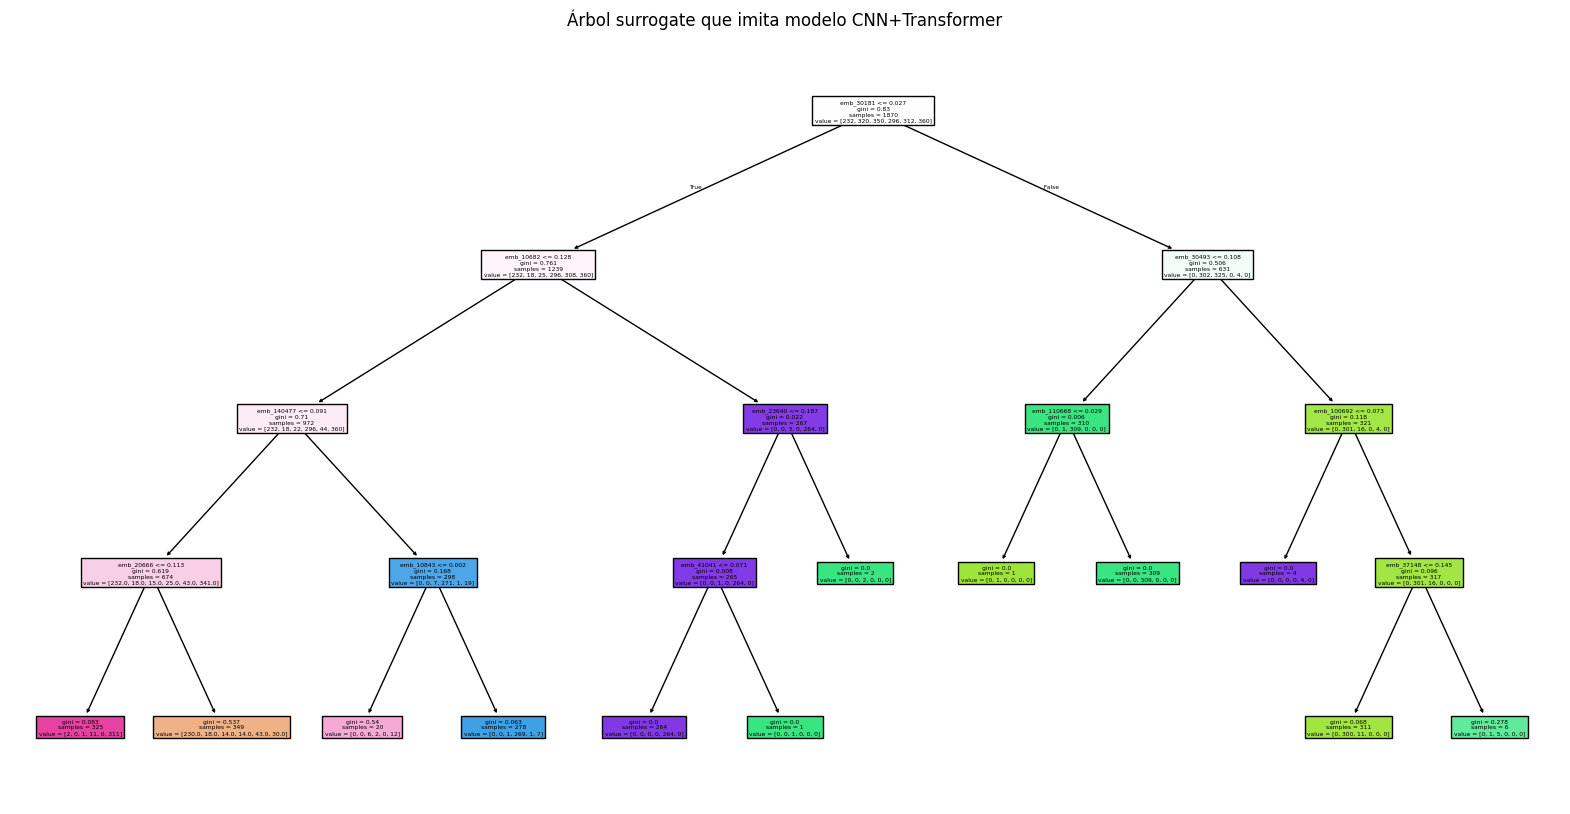

In [ ]:
# --- Entrenar surrogate model (Decision Tree) ---
surrogate = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surrogate.fit(X_emb, y_pred_model)

# --- Evaluar fidelidad ---
fidelidad = accuracy_score(y_pred_model, surrogate.predict(X_emb))
print(f"\n🔍 Fidelidad surrogate vs modelo CNN+Transformer: {fidelidad:.2f}")

# --- Mostrar reglas ---
print("\n🧠 Reglas interpretables del surrogate:")
print(export_text(surrogate, max_depth=6))

# --- Visualizar árbol ---
plt.figure(figsize=(20,10))
plot_tree(surrogate, filled=True, feature_names=[f"emb_{i}" for i in range(X_emb.shape[1])])
plt.title("Árbol surrogate que imita modelo CNN+Transformer")
plt.show()

In [ ]:
# ============================================
# 📌 SISTEMA COMPLETO PARA EXPLORAR ÁRBOLES DE DECISIÓN
#    Funciona con archivos .txt (export_text) y .pkl (sklearn)
# ============================================

!pip install ipywidgets --quiet
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, Markdown
import re
import pickle

print("📥 Sube tus archivos del árbol (.txt y/o .pkl)")
uploaded = files.upload()

# ============================================
# 1) CARGA DEL ARCHIVO TXT (ÁRBOL EN TEXTO)
# ============================================

tree_txt = None
for fname in uploaded.keys():
    if fname.endswith(".txt"):
        tree_txt = fname

if tree_txt:
    with open(tree_txt, "r") as f:
        tree_content = f.read()
    print(f"📄 Archivo TXT cargado: {tree_txt}")
else:
    print("⚠️ No se subió un archivo .txt")


# ============================================
# 🔍 EXPLORADOR DE FEATURES EN EL ARCHIVO TXT
# ============================================

def crear_explorador_features(tree_content):
    feature_input = widgets.Text(
        value='30181',
        description='Feature:',
        placeholder='Ej: 30181',
        layout=widgets.Layout(width='300px')
    )

    output = widgets.Output()

    def explorar_feature(change):
        feature = feature_input.value.strip()
        patron = fr"feature_{feature} [<>=]"

        output.clear_output()
        with output:
            if re.search(patron, tree_content):
                print(f"🔍 Coincidencias para feature_{feature}:\n")
                coincidencias = [
                    line for line in tree_content.split("\n")
                    if f"feature_{feature}" in line
                ]
                for c in coincidencias:
                    print(c)
            else:
                print(f"⚠️ La feature {feature} no aparece en el árbol.")

    feature_input.observe(explorar_feature, names='value')
    display(Markdown("### 🔍 Explorador de Features (archivo TXT)"))
    display(feature_input, output)


if tree_txt:
    crear_explorador_features(tree_content)



# ============================================
# 2) CARGA DEL ARCHIVO PKL (MODELO SKLEARN)
# ============================================

model = None
tree = None

for fname in uploaded.keys():
    if fname.endswith(".pkl"):
        with open(fname, "rb") as f:
            model = pickle.load(f)
        print(f"🌳 Archivo PKL cargado: {fname}")
        break

if model:
    try:
        tree = model.tree_
    except:
        print("⚠️ El archivo PKL no contiene un árbol sklearn válido.")


# ============================================
# 🧭 EXPLORADOR INTERACTIVO DE NODOS DEL MODELO
# ============================================

def nodo_info(idx):
    if idx < 0 or idx >= tree.node_count:
        return "Nodo fuera de rango."

    if tree.children_left[idx] == tree.children_right[idx]:  # hoja
        return (
            f"🌿 Nodo hoja {idx}\n"
            f"Clase: {tree.value[idx]}\n"
            f"Muestras: {tree.n_node_samples[idx]}"
        )

    return (
        f"🌲 Nodo {idx}\n"
        f"Feature: {tree.feature[idx]}\n"
        f"Threshold: {tree.threshold[idx]:.4f}\n"
        f"Hijo izquierdo: {tree.children_left[idx]}\n"
        f"Hijo derecho: {tree.children_right[idx]}\n"
        f"Muestras: {tree.n_node_samples[idx]}"
    )


def crear_explorador_nodos(tree):
    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=tree.node_count - 1,
        step=1,
        description='Nodo:',
        continuous_update=True,
        layout=widgets.Layout(width='600px')
    )

    out = widgets.Output()

    def actualizar(change):
        out.clear_output()
        with out:
            print(nodo_info(slider.value))

    slider.observe(actualizar, names='value')

    display(Markdown("### 🧭 Explorador de nodos del árbol (archivo PKL)"))
    display(slider, out)


if tree is not None:
    crear_explorador_nodos(tree)



# ============================================
# SISTEMA CARGADO
# ============================================
display(
    Markdown("""
# ✅ Sistema listo
Puedes:
- Buscar **features** en el árbol de texto (.txt)
- Explorar **nodos** del árbol sklearn (.pkl)
""")
)


📥 Sube tus archivos del árbol (.txt y/o .pkl)


Saving surrogate_tree1.txt to surrogate_tree1 (1).txt
📄 Archivo TXT cargado: surrogate_tree1 (1).txt


### 🔍 Explorador de Features (archivo TXT)

Text(value='30181', description='Feature:', layout=Layout(width='300px'), placeholder='Ej: 30181')

Output()


# ✅ Sistema listo
Puedes:
- Buscar **features** en el árbol de texto (.txt)
- Explorar **nodos** del árbol sklearn (.pkl)


In [ ]:
# Ver primeros bytes del archivo para identificar formato
import binascii

with open("surrogate_model1.pkl", "rb") as f:
    header = f.read(16)

print("Cabecera en bytes:", header)
print("Hex:", binascii.hexlify(header))


Cabecera en bytes: b'\x80\x04\x95F\x02\x00\x00\x00\x00\x00\x00\x8c\x15skl'
Hex: b'80049546020000000000008c15736b6c'


In [ ]:
import pickle

with open("surrogate_model1.pkl", "rb") as f:
    model = pickle.load(f)

print("✔ Modelo cargado correctamente")
print(type(model))


UnpicklingError: invalid load key, '\x0e'.

In [ ]:
import pandas as pd
import joblib
from sklearn.tree import _tree

# ==========================================================
# 🔹 CARGAR CSV DE FEATURES
# ==========================================================
df_features = pd.read_csv("/content/cremad/surrogate/features_surrogate_features1.csv")

# Convertir nombres "feature_529" → "529"
df_features.columns = [
    c.replace("feature_", "") if c.startswith("feature_") else c
    for c in df_features.columns
]


# ==========================================================
# 🔹 CARGAR CSV DEL LASSO
# ==========================================================
df_lasso = pd.read_csv("/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv")

# Convertir "feature_18489" → "18489"
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(
    lambda x: x.replace("feature_", "")
)


# ==========================================================
# 🔹 MÓDULO 1: valor del feature para ID
# ==========================================================
def get_feature_value(df, feature_name, sample_id):
    if feature_name not in df.columns:
        raise KeyError(f"La columna {feature_name} no existe en el CSV.")

    row = df[df["id"] == sample_id]
    if row.empty:
        raise KeyError(f"El ID {sample_id} no existe en el CSV.")

    return row.iloc[0][feature_name]


# ==========================================================
# 🔹 MÓDULO 2: cargar árbol .pkl o .txt
# ==========================================================
def load_tree(file_path):
    if file_path.endswith(".pkl"):
        surrogate = joblib.load(file_path)
        tree = surrogate.tree_

        # Feature names son "0", "1", "2", ...
        feature_cols_tree = [str(i) for i in range(tree.n_features)]

        return tree, feature_cols_tree

    elif file_path.endswith(".txt"):
        with open(file_path, "r") as f:
            return f.readlines()

    else:
        raise ValueError("Archivo debe ser .pkl o .txt")


# ==========================================================
# 🔹 MÓDULO 3: clases bajo un nodo
# ==========================================================
def get_classes_under_node(tree, node_id):
    classes = []

    def recurse(n):
        if tree.feature[n] == _tree.TREE_UNDEFINED:
            vals = tree.value[n][0]
            cls = [i for i, v in enumerate(vals) if v > 0]
            classes.extend(cls)
        else:
            recurse(tree.children_left[n])
            recurse(tree.children_right[n])

    recurse(node_id)
    return sorted(list(set(classes)))


# ==========================================================
# 🔹 MÓDULO 4: nodos donde se usa la feature
# ==========================================================
def find_feature_nodes(tree, feature_cols_tree, feature_name):
    if feature_name not in feature_cols_tree:
        return []

    idx = feature_cols_tree.index(feature_name)
    nodes = []

    for node_id in range(tree.node_count):
        if tree.feature[node_id] == idx:
            threshold = tree.threshold[node_id]
            nodes.append({
                "node_id": node_id,
                "feature": feature_name,
                "threshold": threshold,
                "sign": "<=",
                "true_classes": get_classes_under_node(tree, tree.children_left[node_id]),
                "false_classes": get_classes_under_node(tree, tree.children_right[node_id])
            })

    return nodes


# ==========================================================
# 🔹 MÓDULO 5: LASSO — features originales
# ==========================================================
def get_lasso_vars(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return []
    return eval(row.iloc[0]["used_vars"])  # convierte lista en python


# ==========================================================
# 🔹 MÓDULO FINAL: análisis completo
# ==========================================================
def analyze_feature_for_sample(tree_file, df, feature_name, sample_id):
    # 1. Cargar árbol
    tree, feature_cols_tree = load_tree(tree_file)

    # 2. Nodos donde aparece el feature
    nodes = find_feature_nodes(tree, feature_cols_tree, feature_name)
    if not nodes:
        print(f"⚠️ Feature {feature_name} NO aparece en el árbol.")
        return

    # 3. Valor del CSV
    value = get_feature_value(df, feature_name, sample_id)

    # 4. Variables originales del LASSO
    lasso_vars = get_lasso_vars(feature_name)

    print(f"\n🔍 Análisis completo para feature '{feature_name}' (ID: {sample_id})")
    print(f"Valor en CSV: {value}")
    print(f"Variables originales del LASSO: {lasso_vars}")

    # 5. Evaluar cada nodo
    for n in nodes:
        thr = n["threshold"]
        is_true = value <= thr

        print(f"\n➡️ Nodo {n['node_id']}: {feature_name} <= {thr:.5f}")
        print(f"Resultado: {'TRUE' if is_true else 'FALSE'}")
        print(f"✔️ Clases si TRUE : {n['true_classes']}")
        print(f"❌ Clases si FALSE: {n['false_classes']}")

# Cargar el CSV
df = pd.read_csv("/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv")

# Selecciona embeddings, caracteristicas
cols = pd.concat([df.iloc[:, :1], df.iloc[:, -2:]], axis=1)

# Mostrar las primeras 5 filas como ejemplo
cols.head()
# ==========================================================
# EJEMPLO DE USO
# ==========================================================
tree_file = "/content/cremad/surrogate/surrogate_model1.pkl"
# Cargar el CSV
df = pd.read_csv("/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv")

# Selecciona embeddings, caracteristicas
cols = pd.concat([df.iloc[:, :1], df.iloc[:, -3:]], axis=1)

# Mostrar las primeras 5 filas como ejemplo
cols.head()
feature_name = input("Ingresa el nombre de la característica (feature_name): ") #feature_name = "30181"           # SIN prefix
sample_id = input("Ingresa el ID de la muestra (sample_id): ") #sample_id = "1048_WSI_DIS_XX_seg1"

analyze_feature_for_sample(tree_file, df_features, feature_name, sample_id)


Ingresa el nombre de la característica (feature_name): 30181
Ingresa el ID de la muestra (sample_id): 1048_WSI_DIS_XX_seg1

🔍 Análisis completo para feature '30181' (ID: 1048_WSI_DIS_XX_seg1)
Valor en CSV: 0.030768644
Variables originales del LASSO: ['f0semitonefrom27.5hz_sma3nz_percentile20.0', 'f0semitonefrom27.5hz_sma3nz_pctlrange0-2', 'f0semitonefrom27.5hz_sma3nz_meanrisingslope', 'f0semitonefrom27.5hz_sma3nz_stddevrisingslope', 'f0semitonefrom27.5hz_sma3nz_meanfallingslope', 'f0semitonefrom27.5hz_sma3nz_stddevfallingslope', 'loudness_sma3_meanrisingslope', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevnorm', 'mfcc4_sma3_amean', 'mfcc4_sma3_stddevnorm', 'logrelf0-h1-h2_sma3nz_stddevnorm', 'logrelf0-h1-a3_sma3nz_amean', 'f1frequency_sma3nz_amean', 'f1bandwidth_sma3nz_amean', 'f2frequency_sma3nz_amean', 'f2bandwidth_sma3nz_amean', 'f3frequency_sma3nz_amean', 'f3bandwidth_sma3nz_amean', 'f3amplitudelogrelf0_sma3nz_amean', 'slopev500-1500_sma3nz_stddevnorm', 'mfcc2v_sma3nz_amean', 'mfcc2v_sma3

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown


# ============================================
# 1) ARCHIVOS DE ENTRADA (AJUSTA SOLO ESTO)
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

## Nodos donde aparece el feature
def find_feature_nodes(feature_name):
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == int(feature_name):
            nodes.append({
                "node_id": node_id,
                "threshold": tree.threshold[node_id],
                "left": tree.children_left[node_id],
                "right": tree.children_right[node_id],
            })
    return nodes


## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class


# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)

        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        for step in path:

            node = step['node']
            lvl = NODE_DEPTH[node]
            feat = step['feature']
            thr = step['threshold']
            val = step['value']
            decision = step['decision']

            left_classes = classes_under_node(tree.children_left[node])
            right_classes = classes_under_node(tree.children_right[node])

            print(f"\n• Nodo {node} (nivel {lvl}): feature {feat} <= {thr:.4f}")
            print(f"  Valor real: {val} → {'TRUE' if decision else 'FALSE'}")

            print("  Emociones si TRUE :", [EMOTION_NAMES[c] for c in left_classes])
            print("  Emociones si FALSE:", [EMOTION_NAMES[c] for c in right_classes])


        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

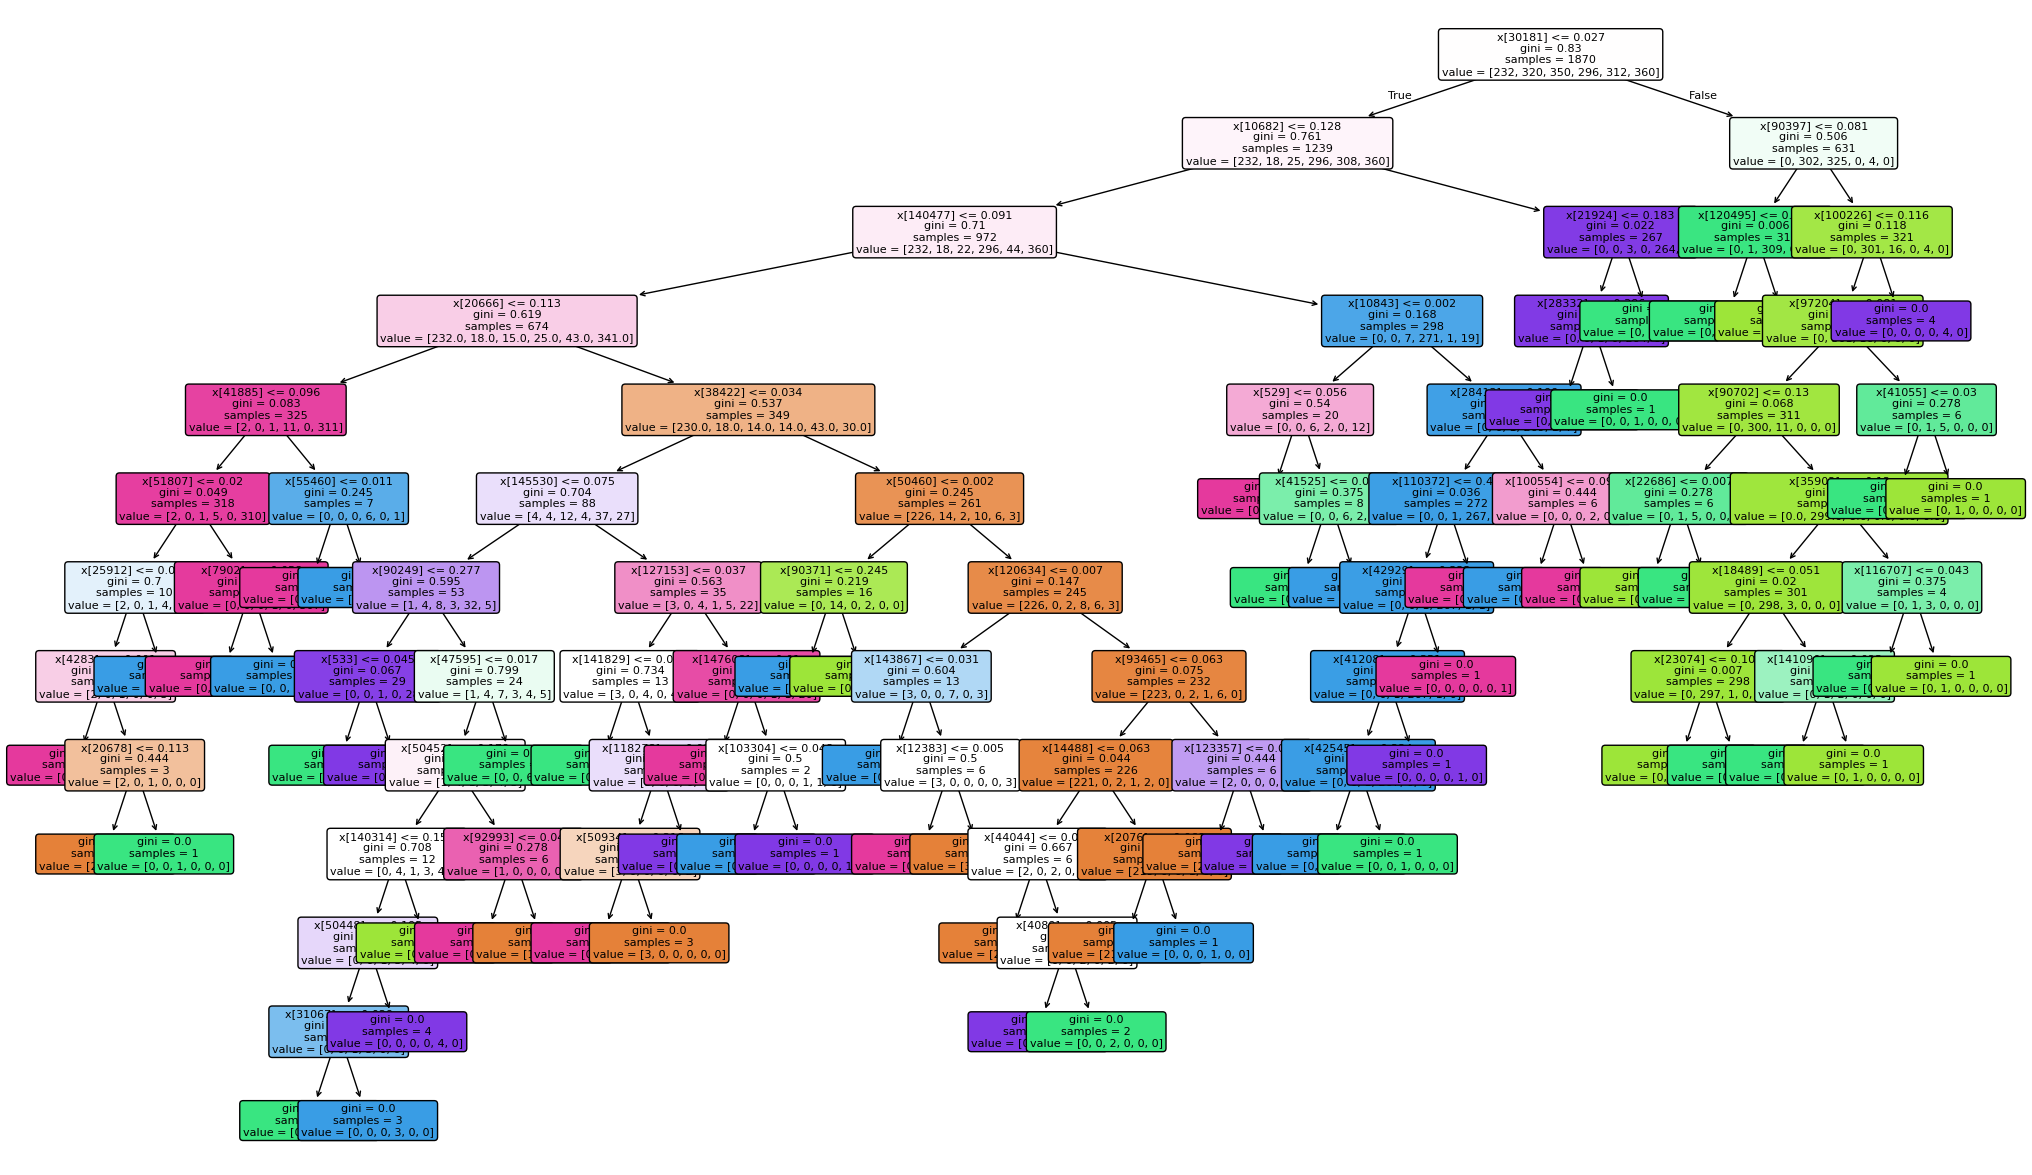

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 15))
tree.plot_tree(
    surrogate,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


In [ ]:
# =====================================================
# 🔹 Extraer subárbol visual del feature seleccionado
# =====================================================

def get_ancestor_nodes(target_nodes):
    parents = {}
    for node in range(tree.node_count):
        left = tree.children_left[node]
        right = tree.children_right[node]
        if left != -1:
            parents[left] = node
            parents[right] = node

    # Añadir todos los ancestros
    expanded = set(target_nodes)
    for n in target_nodes:
        while n in parents:
            p = parents[n]
            expanded.add(p)
            n = p
    return sorted(list(expanded))

def visualize_feature_subtree(feature_name):
    feature_nodes = [n['node_id'] for n in find_feature_nodes(feature_name)]
    if not feature_nodes:
        print("⚠️ Este feature no aparece en el árbol.")
        return None

    sub_nodes = get_ancestor_nodes(feature_nodes)

    # generate DOT manually
    dot = "digraph Tree {\n"
    dot += 'node [shape=box, style="filled, rounded", fontname="helvetica"];\n'

    for n in sub_nodes:
        if tree.feature[n] != _tree.TREE_UNDEFINED:
            label = f"Node {n}\\n(feature {tree.feature[n]} <= {tree.threshold[n]:.3f})"
            color = "#a6cee3" if tree.feature[n] == int(feature_name) else "#b2df8a"
        else:
            # Leaf
            cls = np.argmax(tree.value[n][0])
            label = f"Leaf {n}\\nClass: {cls} ({EMOTION_NAMES[cls]})"
            color = "#fb9a99"

        dot += f'{n} [label="{label}", fillcolor="{color}"];\n'

    # Draw edges
    for n in sub_nodes:
        if tree.feature[n] != _tree.TREE_UNDEFINED:
            L = tree.children_left[n]
            R = tree.children_right[n]
            if L in sub_nodes:
                dot += f'{n} -> {L} [label="True"];\n'
            if R in sub_nodes:
                dot += f'{n} -> {R} [label="False"];\n'

    dot += "}"

    return graphviz.Source(dot)
print("\n==============================")
print("🌿 Subárbol del Feature Seleccionado")
print("==============================")

subtree_graph = visualize_feature_subtree(feature_name)
if subtree_graph:
    display(subtree_graph)



🌿 Subárbol del Feature Seleccionado


NameError: name 'feature_name' is not defined

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown


# ============================================
# 1) ARCHIVOS DE ENTRADA (AJUSTA SOLO ESTO)
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

# =======================================================
# 🔹 Nodos donde aparece el feature + nivel + emociones
# =======================================================

EMOTION_NAMES = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]


# Obtener emociones bajo un nodo (todas las hojas descendientes)
def classes_under_node(node):
    classes = set()

    def recurse(n):
        if tree.feature[n] == _tree.TREE_UNDEFINED:
            vals = tree.value[n][0]
            for cls_idx, v in enumerate(vals):
                if v > 0:
                    classes.add(cls_idx)
        else:
            recurse(tree.children_left[n])
            recurse(tree.children_right[n])

    recurse(node)
    return sorted(list(classes))


# Calcular nivel del nodo
def compute_depths():
    depth = [None] * tree.node_count
    depth[0] = 0  # raíz

    stack = [0]
    while stack:
        n = stack.pop()
        if tree.children_left[n] != -1:
            depth[tree.children_left[n]] = depth[n] + 1
            depth[tree.children_right[n]] = depth[n] + 1
            stack.append(tree.children_left[n])
            stack.append(tree.children_right[n])

    return depth


NODE_DEPTH = compute_depths()


# Nodos donde aparece la feature
def find_feature_nodes(feature_name):
    feature_index = int(feature_name)
    nodes = []

    for node_id in range(tree.node_count):
        if tree.feature[node_id] == feature_index:

            thr = tree.threshold[node_id]
            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            nodes.append({
                "node_id": node_id,
                "level": NODE_DEPTH[node_id],
                "threshold": thr,
                "left_classes": classes_under_node(left),
                "right_classes": classes_under_node(right)
            })

    # Ordenar por nivel
    nodes = sorted(nodes, key=lambda x: x["level"])
    return nodes



## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class


# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)

        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        for step in path:
            print(f"\n• Nodo {step['node']}: feature {step['feature']} <= {step['threshold']:.4f}")
            print(f"  Valor: {step['value']} → {'TRUE' if step['decision'] else 'FALSE'}")

        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
# ============================================
# 🔰 SISTEMA UNIFICADO DE ANÁLISIS DEL SURROGATE
# ============================================

import pandas as pd
import numpy as np
import joblib
from sklearn.tree import _tree
import ipywidgets as widgets
from IPython.display import display, Markdown


# ============================================
# 1) ARCHIVOS DE ENTRADA (AJUSTA SOLO ESTO)
# ============================================

TREE_PKL = "/content/cremad/surrogate/surrogate_model1.pkl"
TREE_TXT = "/content/cremad/surrogate/surrogate_tree1.txt"
DF_FEATURES = "/content/cremad/surrogate/features_surrogate_features1.csv"
DF_LASSO = "/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_Crema.csv"


# ============================================
# 2) CARGA DE ARCHIVOS
# ============================================

# ▪ ÁRBOL PICKLE
surrogate = joblib.load(TREE_PKL)
tree = surrogate.tree_

# ▪ ÁRBOL TEXTO
with open(TREE_TXT, "r") as f:
    tree_text = f.read()

# ▪ FEATURES
df_features = pd.read_csv(DF_FEATURES)
df_features.columns = [c.replace("feature_", "") if c.startswith("feature_") else c for c in df_features.columns]

# ▪ LASSO
df_lasso = pd.read_csv(DF_LASSO)
df_lasso["embedding_feature"] = df_lasso["embedding_feature"].apply(lambda x: x.replace("feature_", ""))


# ============================================
# 3) MÓDULOS DEL SISTEMA
# ============================================

## Obtener valor de feature para un ID
def get_feature_value(feature_name, sample_id):
    row = df_features[df_features["id"] == sample_id]
    return row.iloc[0][feature_name]

## Obtener datos del LASSO
def get_lasso_info(feature_name):
    row = df_lasso[df_lasso["embedding_feature"] == feature_name]
    if row.empty:
        return None
    return {
        "r2": row.iloc[0]["r2"],
        "n_vars_used": row.iloc[0]["n_vars_used"],
        "vars": eval(row.iloc[0]["used_vars"])
    }

# =======================================================
# 🔹 Nodos donde aparece el feature + nivel + emociones
# =======================================================

EMOTION_NAMES = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]


# Obtener emociones bajo un nodo (todas las hojas descendientes)
def classes_under_node(node):
    classes = set()

    def recurse(n):
        if tree.feature[n] == _tree.TREE_UNDEFINED:
            vals = tree.value[n][0]
            for cls_idx, v in enumerate(vals):
                if v > 0:
                    classes.add(cls_idx)
        else:
            recurse(tree.children_left[n])
            recurse(tree.children_right[n])

    recurse(node)
    return sorted(list(classes))


# Calcular nivel del nodo
def compute_depths():
    depth = [None] * tree.node_count
    depth[0] = 0  # raíz

    stack = [0]
    while stack:
        n = stack.pop()
        if tree.children_left[n] != -1:
            depth[tree.children_left[n]] = depth[n] + 1
            depth[tree.children_right[n]] = depth[n] + 1
            stack.append(tree.children_left[n])
            stack.append(tree.children_right[n])

    return depth


NODE_DEPTH = compute_depths()


# Nodos donde aparece la feature
def find_feature_nodes(feature_name):
    feature_index = int(feature_name)
    nodes = []

    for node_id in range(tree.node_count):
        if tree.feature[node_id] == feature_index:

            thr = tree.threshold[node_id]
            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            nodes.append({
                "node_id": node_id,
                "level": NODE_DEPTH[node_id],
                "threshold": thr,
                "left_classes": classes_under_node(left),
                "right_classes": classes_under_node(right)
            })

    # Ordenar por nivel
    nodes = sorted(nodes, key=lambda x: x["level"])
    return nodes



## Recorrido del árbol para un sample
def predict_path(sample_id):
    current = 0
    path = []
    while tree.feature[current] != _tree.TREE_UNDEFINED:
        feat = str(tree.feature[current])
        thr = tree.threshold[current]
        val = df_features[df_features["id"] == sample_id].iloc[0][feat]

        decision = val <= thr
        next_node = tree.children_left[current] if decision else tree.children_right[current]

        path.append({
            "node": current,
            "feature": feat,
            "threshold": thr,
            "value": val,
            "decision": decision
        })
        current = next_node
    # Nodo final hoja
    leaf_val = tree.value[current][0]
    predicted_class = np.argmax(leaf_val)
    return path, predicted_class


# ============================================
# 4) INTERFAZ INTERACTIVA
# ============================================

# ▪ Lista de features disponibles
feature_list = sorted(df_features.columns[1:], key=lambda x: int(x))

feature_dropdown = widgets.Dropdown(
    options=feature_list,
    description="Feature:"
)

# ▪ Lista de IDs disponibles
id_list = sorted(df_features["id"].tolist())

id_dropdown = widgets.Dropdown(
    options=id_list,
    description="ID Audio:"
)

# ▪ Botón de análisis
btn = widgets.Button(
    description="Analizar",
    button_style="primary",
    icon="search"
)

output = widgets.Output()


# =======================================================
# 🔎 FUNCIÓN PRINCIPAL AL HACER CLICK
# =======================================================

def analizar_click(b):

    feature_name = feature_dropdown.value
    sample_id = id_dropdown.value

    output.clear_output()

    with output:

        print("\n==============================")
        print(f"🔍 Feature seleccionado: {feature_name}")
        print("==============================\n")

        # -------- Mostrar info del LASSO --------
        lasso_info = get_lasso_info(feature_name)

        if lasso_info:
            print("📊 Info LASSO:")
            print(f"  • r²: {lasso_info['r2']:.5f}")
            print(f"  • Num. variables usadas: {lasso_info['n_vars_used']}")
            print(f"  • Variables originales:")
            for v in lasso_info["vars"]:
                print("    -", v)
        else:
            print("⚠️ No se encontró información LASSO.")

        print("\n==============================")
        print("🌳 Nodos del árbol donde aparece el feature")
        print("==============================")

        nodes = find_feature_nodes(feature_name)
        print("\n==============================")
        print("🌿 Subárbol del Feature Seleccionado")
        print("==============================")

        subtree_graph = visualize_feature_subtree(feature_name)
        if subtree_graph:
            display(subtree_graph)

        if not nodes:
            print(f"⚠️ El feature {feature_name} no aparece en el surrogate.")
            return

        for n in nodes:
            print(f"\n➡ Nodo {n['node_id']}: feature {feature_name} <= {n['threshold']:.4f}")

        # -------- Valor del feature para el audio --------
        val = get_feature_value(feature_name, sample_id)
        print("\n==============================")
        print(f"🎧 Valor del feature para ID {sample_id}: {val}")
        print("==============================\n")

        # -------- Recorrido del árbol --------
        print("\n==============================")
        print("🛣️ Recorrido completo del árbol")
        print("==============================")

        path, pred_class = predict_path(sample_id)

        emotions = ["Anger(0)", "Disgust(1)", "Fear(2)", "Happy(3)", "Neutral(4)", "Sad(5)"]

        for step in path:
            print(f"\n• Nodo {step['node']}: feature {step['feature']} <= {step['threshold']:.4f}")
            print(f"  Valor: {step['value']} → {'TRUE' if step['decision'] else 'FALSE'}")

        print("\n==============================")
        print(f"🎯 CLASE PREDICHA: {emotions[pred_class]}")
        print("==============================")



btn.on_click(analizar_click)

display(
    Markdown("## 🌟 Sistema de Interpretabilidad del Árbol Surrogate\nSelecciona un feature y un ID para analizar.")
)
display(feature_dropdown, id_dropdown, btn, output)


## 🌟 Sistema de Interpretabilidad del Árbol Surrogate
Selecciona un feature y un ID para analizar.

Dropdown(description='Feature:', options=('529', '533', '2076', '4089', '4283', '7902', '10682', '10843', '123…

Dropdown(description='ID Audio:', options=('1001_DFA_NEU_XX_seg1', '1001_DFA_SAD_XX_seg1', '1001_IEO_ANG_HI_se…

Button(button_style='primary', description='Analizar', icon='search', style=ButtonStyle())

Output()

In [ ]:
!pip install opensmile kagglehub numpy pandas librosa matplotlib opensmile kaggle shap lime
#Generacion 3 generacion de espectrogramas
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import librosa
import librosa.display
from tqdm import tqdm
import opensmile
import kagglehub
import glob
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from datetime import datetime
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf



# === CONFIGURACIONES ===
valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
invalid_audio_ids = ['1088_ITH_HAP_XX.wav', '1017_IEO_SAD_HI.wav', '1040_ITH_SAD_X.wav', '1076_MTI_SAD_XX.wav']
max_files = 7500
batch_size = 20
segment_duration = 5  # duración del segmento en segundos (None para no dividir)

def set_seed(seed):
    """Configura la semilla para reproducibilidad."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Para CUDA, si está disponible
    torch.backends.cudnn.deterministic = True  # Hace que las operaciones sean deterministas
    torch.backends.cudnn.benchmark = False  # Desactiva la optimización para entradas con dimensiones variables
    import random
    random.seed(seed)

# --- Llamar a la función set_seed con un valor de semilla ---
seed = 42  # Puedes cambiar este valor para experimentar con diferentes semillas
set_seed(seed)

def generate_spectrogram(file_path, output_dir="spectrograms", normalize=True, segment_duration=None):
    sampling_rate = 16000
    window_size = 512
    hop_size = 256
    n_fft = 1024
    mel_bins = 128

    x, sr = librosa.load(file_path, sr=sampling_rate)

    if segment_duration:
        segment_samples = int(segment_duration * sampling_rate)
        total_segments = int(np.ceil(len(x) / segment_samples))
    else:
        segment_samples = len(x)
        total_segments = 1

    output_data = []

    for i in range(total_segments):
        start = i * segment_samples
        end = min((i + 1) * segment_samples, len(x))
        segment = x[start:end]

        if len(segment) < segment_samples:
            segment = np.pad(segment, (0, segment_samples - len(segment)))

        stft = librosa.stft(segment, n_fft=n_fft, hop_length=hop_size, win_length=window_size)
        magnitude = np.abs(stft)
        mel_filter = librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=mel_bins)
        mel_spectrogram = np.dot(mel_filter, magnitude)
        log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

        if normalize:
            std = np.std(log_mel_spectrogram)
            if std > 0:
                log_mel_spectrogram = (log_mel_spectrogram - np.mean(log_mel_spectrogram)) / std
            else:
                print(f"⚠️ Espectrograma plano en {file_path} (segmento {i}), se omitió normalización.")
        os.makedirs(output_dir, exist_ok=True)
        base_filename = os.path.basename(file_path).replace(".wav", f"_seg{i}.png")
        save_path = os.path.join(output_dir, base_filename)

        if not os.path.exists(save_path):
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(log_mel_spectrogram, sr=sampling_rate, x_axis='time', y_axis='mel')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f'Segment {i}: {base_filename}')
            plt.tight_layout()
            plt.savefig(save_path)
            plt.close()
            print(f"✅ Espectrograma generado: {save_path}")
        else:
            print(f"⏩ Espectrograma ya existe: {save_path}")

        output_data.append({
            "file": base_filename,
            "path": save_path,
            "height": log_mel_spectrogram.shape[0],
            "width": log_mel_spectrogram.shape[1],
            "shape": log_mel_spectrogram.shape
        })

    # Cambié la devolución para siempre devolver una lista, aunque no haya segmentación
    return output_data if segment_duration else [output_data[0]]  # Devuelve como lista, incluso sin segmentación


# === FUNCIONES DE MANEJO DE AUDIO ===
def get_audio_files(dataset_name="ejlok1/cremad", folder="AudioWAV", valid_ext=".wav", valid_emotions=None, invalid_audio_ids=None):
    path = kagglehub.dataset_download(dataset_name)
    print("[✔] Dataset descargado en:", path)
    audio_path = os.path.join(path, folder)
    audio_files = glob.glob(os.path.join(audio_path, f"*{valid_ext}"))

    if valid_emotions:
        audio_files = [f for f in audio_files if any(emotion in f for emotion in valid_emotions)]
    if invalid_audio_ids:
        audio_files = [f for f in audio_files if os.path.basename(f) not in invalid_audio_ids]

    return audio_files

# === PROCESAR AUDIOS EN BATCHES ===
def procesar_audios_n(audio_files, smile_models, max_files, output_root, batch_size=20,
                      segment_duration=None, modo="train", modelo_de_clasificacion=None,
                      csv_emociones_path=None,
                      transform=None, csv_emociones=None):
    for model_name, smile_model in smile_models.items():
        print(f"\n🔍 Procesando con modelo: {model_name}")
        model_output_root = os.path.join(output_root, model_name)
        features_dir = os.path.join(output_root, "features")
        spectrograms_dir = os.path.join(output_root, "spectrograms")
        os.makedirs(features_dir, exist_ok=True)
        os.makedirs(spectrograms_dir, exist_ok=True)

        combined_path = os.path.join(features_dir, "features_combined.csv")
        emotions_path = os.path.join(features_dir, "emotions_metadata.csv")
        features_path = os.path.join(features_dir, "features.csv")

        # Cargar si existen
        if os.path.exists(combined_path):
            combined_df = pd.read_csv(combined_path)
            processed_ids = set(combined_df["id"].astype(str))
        else:
            combined_df = pd.DataFrame()
            processed_ids = set()

        all_features = []
        all_combined = []
        all_emotions = []

        print(f"\n🎧 Procesando hasta {max_files} archivos de audio en batches de {batch_size}...")
        if csv_emociones is not None:
          csv_emociones["id"] = csv_emociones["id"].astype(str).str.strip()
          csv_emociones["emotion"] = csv_emociones["emotion"].str.strip().str.upper()

        for i, audio_path in enumerate(tqdm(audio_files[:max_files])):
            audio_filename = os.path.basename(audio_path)
            audio_id_base = os.path.splitext(audio_filename)[0]

            # === Dividir y generar espectrogramas por segmento ===
            segment_data_list = generate_spectrogram(audio_path, output_dir=spectrograms_dir, segment_duration=segment_duration)

            # === Procesar cada segmento individual ===
            for seg_idx, segment_data in enumerate(segment_data_list):
                segment_audio_id = f"{audio_id_base}_seg{seg_idx}"
                if segment_audio_id in processed_ids:
                    continue

                # === Extraer características del segmento de audio ===
                if segment_duration:
                    start_sample = seg_idx * int(segment_duration * 16000)
                    end_sample = (seg_idx + 1) * int(segment_duration * 16000)
                    x, sr = librosa.load(audio_path, sr=16000)
                    x_segment = x[start_sample:end_sample]
                    if len(x_segment) < end_sample - start_sample:
                        x_segment = np.pad(x_segment, (0, end_sample - start_sample))
                else:
                    x_segment, sr = librosa.load(audio_path, sr=16000)


                # Guardar segmento temporal para procesamiento por OpenSmile
                tmp_segment_path = f"tmp_segment_{segment_audio_id}.wav"
                sf.write(tmp_segment_path, x_segment, samplerate=16000)


                features = smile_model.process_file(tmp_segment_path)
                # ✅ Validar si está vacío
                if features.empty:
                    print(f"⚠️ Segmento sin características: {segment_audio_id}, posiblemente audio inválido.")
                    os.remove(tmp_segment_path)
                    continue  # Saltar este segmento y pasar al siguiente

                features["id"] = segment_audio_id
                all_features.append(features)

                # Eliminar la columna 'id' duplicada en caso de que ya exista en `features`
                if 'id' in features.columns:
                    features = features.drop(columns=['id'])
                metadata = {
                    "spectrogram_path": segment_data["path"],
                    "id": segment_audio_id,
                    "dimensions": f"{segment_data['height']}x{segment_data['width']}",
                    "height": segment_data['height'],
                    "width": segment_data['width'],
                    "sampling_rate": 16000,
                    "window_size": 512,
                    "hop_size": 256,
                    "n_fft": 1024,
                    "segment_index": seg_idx,
                    "segment_duration": segment_duration,
                    "window_function": 'Hamming'
                }

                metadata_df = pd.DataFrame([metadata])
                combined = pd.concat([metadata_df.reset_index(drop=True), features.reset_index(drop=True)], axis=1)
                all_combined.append(combined)
                # Ruta al CSV auxiliar con emociones (deberías definirla antes del bucle)
                if modo == "train":
                  emotion_found = False

                  if csv_emociones is not None:
                      matched = csv_emociones[csv_emociones["spectrogram_path"] == segment_data["path"]]
                      if not matched.empty:
                          found_emotion = matched.iloc[0]["emotion"]
                          if found_emotion in valid_emotions:
                              all_emotions.append({'id': segment_audio_id, 'emotion': found_emotion})
                              emotion_found = True

                  if not emotion_found:
                      print(f"⚠️ No se pudo asignar emoción a: {segment_audio_id}")



                elif modo == "test" and modelo_de_clasificacion and transform:
                    pred = predecir_emociones(modelo_de_clasificacion, segment_data["path"], transform)
                    all_emotions.append({'id': segment_audio_id, 'emotion': pred})
                os.remove(tmp_segment_path)  # limpieza

            # === Guardar batch ===
            if (i + 1) % batch_size == 0 or i == max_files - 1:
                print(f"📦 Guardando batch hasta el archivo #{i + 1}...")
                if all_features:
                    pd.concat(all_features).to_csv(features_path, mode='a', index=False, header=not os.path.exists(features_path))

                if all_combined:
                    pd.concat(all_combined).to_csv(combined_path, mode='a', index=False, header=not os.path.exists(combined_path))

                if all_emotions:
                    pd.DataFrame(all_emotions).to_csv(emotions_path, mode='a', index=False, header=not os.path.exists(emotions_path))

                all_features.clear()
                all_combined.clear()
                all_emotions.clear()
                print(f"🔍 Procesando segmento: {segment_audio_id}")

        # ✅ Guardado forzado al final por si quedó algún batch sin guardar
        if all_features:
            pd.concat(all_features).to_csv(features_path, mode='a', index=False, header=not os.path.exists(features_path))
        if all_combined:
            pd.concat(all_combined).to_csv(combined_path, mode='a', index=False, header=not os.path.exists(combined_path))
        if all_emotions:
            pd.DataFrame(all_emotions).to_csv(emotions_path, mode='a', index=False, header=not os.path.exists(emotions_path))

        print("\n✅ Procesamiento finalizado.")

# Función para predecir la emoción
def predecir_emociones(model, spectrogram_path, transform):
    image = Image.open(spectrogram_path).convert('L')  # Cargar la imagen en modo de escala de grises
    image = transform(image).unsqueeze(0)  # Aplicar las transformaciones y agregar una dimensión extra para el batch

    # Realizar la predicción
    with torch.no_grad():  # Desactivar el cálculo del gradiente durante la inferencia
        outputs = model(image)  # Pasar la imagen por el modelo
        _, preds = torch.max(outputs, 1)  # Obtener la clase con el valor más alto (predicción)

    # Mapear el índice a la emoción correspondiente
    prediccion = valid_emotions[preds.item()]  # Obtener la emoción predicha
    return prediccion
# === EJECUCIÓN ===
audio_files = get_audio_files(
    valid_emotions=valid_emotions,
    invalid_audio_ids=invalid_audio_ids
)

smiles = {
    "eGeMAPSv02": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02, feature_level=opensmile.FeatureLevel.Functionals),
    "emobase": opensmile.Smile(feature_set=opensmile.FeatureSet.emobase, feature_level=opensmile.FeatureLevel.Functionals),
    "eGeMAPS": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPS, feature_level=opensmile.FeatureLevel.Functionals)
}

class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, input_size=(128, 313), num_classes=len(valid_emotions)):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()
        dummy_input = torch.randn(1, 1, *input_size)  # Generar un tensor para obtener el tamaño de la entrada para la capa completamente conectada
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]  # Obtener el tamaño de la capa de entrada del FC
        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)  # Aplanar para la capa completamente conectada
        return self.fc(x)

#model_path = '/content/modelo_1_acc_98_20250426_113056.pth'  # Ruta a los pesos guardados
#model = VisionTransformer()  # Definir el modelo con las dimensiones correctas
#model.load_state_dict(torch.load(model_path))  # Cargar los pesos entrenados
#model.eval()  # Establecer el modelo en modo evaluación
# Transformaciones usadas durante el entrenamiento
input_size = (128, 313)
transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
])

model_path = '/content/modelo_final_99_20250501_213336.pth'  # Ruta a los pesos guardados
model = VisionTransformer(input_size=(128, 313))  # Definir el modelo con las dimensiones correctas
model.load_state_dict(torch.load(model_path))  # Cargar los pesos entrenados
model.eval()  # Establecer el modelo en modo evaluación

segment_durations = [1]  # Duraciones que quieres probar (en segundos)
#base_output = "/content/model/Dataset_CREMA-D_7438_1s.csv"
base_output = "/content/features/features_combined.csv"



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.0/996.0 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 14.2 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4cebad1611f908f90f1c5283d8e63b151376d1b8167289df17d7d8b0e1628375
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a1

/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(


In [ ]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("/content/cremad/results/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv")

# Selecciona embeddings, caracteristicas
cols = pd.concat([df.iloc[:, :1], df.iloc[:, -3:]], axis=1)

# Mostrar las primeras 5 filas como ejemplo
cols.head()


,embedding_feature,r2,n_vars_used,used_vars
0,feature_18489,0.001131,2,"['pcm_fftmag_spectralvariance_sma_lpgain', 'pc..."
1,feature_12383,0.015354,2,"['pcm_fftmag_spectralvariance_sma_lpgain', 'pc..."
2,feature_2076,0.020600,2,"['pcm_fftmag_spectralvariance_sma_lpgain', 'pc..."
3,feature_30181,0.007050,5,"['pcm_fftmag_spectralvariance_sma_lpgain', 'pc..."
4,feature_7902,0.001600,1,['pcm_fftmag_spectralvariance_sma_lpgain']


In [ ]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("/content/cremad/surrogate/features_surrogate_features1.csv")

# Selecciona embeddings, caracteristicas
cols = pd.concat([df.iloc[:, :1], df.iloc[:, -8:]], axis=1)

# Mostrar las primeras 5 filas como ejemplo
cols.head()

,id,feature_127153,feature_140314,feature_140477,feature_141090,feature_141829,feature_143867,feature_145530,feature_147608
0,1048_WSI_DIS_XX_seg1,0.026336,0.096195,0.060664,0.020830,0.027110,0.026120,0.071765,0.000000
1,1006_ITS_FEA_XX_seg0,0.080102,0.000000,0.096545,0.015957,0.013302,0.014652,0.061416,0.000000
2,1005_ITH_HAP_XX_seg1,0.071765,0.000000,0.150599,0.034520,0.040070,0.010466,0.071765,0.000000
3,1014_IWL_NEU_XX_seg0,0.075182,0.062135,0.046069,0.038413,0.000000,0.000000,0.071765,0.055886
4,1028_IOM_ANG_XX_seg1,0.041501,0.004899,0.056761,0.000000,0.000000,0.000000,0.071765,0.000000


In [ ]:
import pandas as pd

# ==============================
# 1. Cargar tu archivo CSV
# ==============================
# Cambia "tu_archivo.csv" por el nombre del archivo real
df = pd.read_csv("/content/Clips_Peliculas_EmoStim_21A_1s.csv")

# ==============================
# 2. Verificar columnas
# ==============================
print("Columnas del archivo:", df.columns.tolist())

# Asegúrate de que existen las columnas "id" y "emotion"

# ==============================
# 3. Extraer el nombre del clip (quitando '_segXX')
# ==============================
df["clip"] = df["id"].str.split("_seg").str[0]

# ==============================
# 4. Contar emociones por clip
# ==============================
conteo_clips = (
    df.groupby(["clip", "emotion"])
      .size()
      .reset_index(name="count")
)

print("\nConteo de emociones por clip:")
print(conteo_clips)

# ==============================
# 5. (Opcional) Guardar resultado en CSV
# ==============================
conteo_clips.to_csv("conteo_emociones_por_clip.csv", index=False)
print("\nArchivo 'conteo_emociones_por_clip.csv' creado.")


Columnas del archivo: ['spectrogram_path', 'id', 'dimensions', 'height', 'width', 'sampling_rate', 'window_size', 'hop_size', 'n_fft', 'segment_index', 'segment_duration', 'window_function', 'F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlu

In [ ]:
import pandas as pd

# ==============================================================
# 1. Cargar CSV de 1 segundo y obtener emoción dominante por clip
# ==============================================================

df_seg = pd.read_csv("/content/Clips_Peliculas_EmoStim_21A_1s.csv")

# Extraer el nombre del clip quitando "_segXX"
df_seg["clip"] = df_seg["id"].str.split("_seg").str[0]

# Contar cuántas veces aparece cada emoción por clip
conteo = (
    df_seg.groupby(["clip", "emotion"])
          .size()
          .reset_index(name="count")
)

# Obtener SOLO la emoción dominante por clip (la más frecuente)
top_emotion_csv = (
    conteo.sort_values(["clip", "count"], ascending=[True, False])
          .groupby("clip")
          .first()
          .reset_index()
)

print("\n=== EMOCIÓN MÁS FUERTE POR CLIP (CSV) ===")
print(top_emotion_csv.head())


# ==============================================================
# 2. Cargar Excel y obtener emoción máxima solo de columnas elegidas
# ==============================================================

df_details = pd.read_excel("/content/FilmClipsDetails.xlsx")

emotion_cols = df_details.columns[[3, 6, 10, 15]]
## Emotion id - Class: Anger (0), Disgust (1), Fear (2), Happy (3), Neutral (4), Sad (5).
## Emotion clip_name - Class: Fear (3), Anger (6), Sad (10), Disgust (5).
# Columnas de emociones (3 a 18)
#emotion_cols = df_details.columns[3:18]

print("\nEmociones seleccionadas del Excel:", emotion_cols.tolist())

# Calcular el valor máximo entre estas emociones
df_details["max_value"] = df_details[emotion_cols].max(axis=1)

# Determinar cuáles emociones alcanzan ese máximo
df_details["top_emotions"] = df_details.apply(
    lambda row: [emotion for emotion in emotion_cols if row[emotion] == row["max_value"]],
    axis=1
)

result_details = df_details[["clip_name", "max_value", "top_emotions"]]

print("\n=== EMOCIÓN MÁS FUERTE (Excel filtrado) ===")
print(result_details.head())


# ==============================================================
# 3. Normalizar nombres y COMBINAR AMBOS RESULTADOS
# ==============================================================

# Convertir nombres a minúsculas para que coincidan
top_emotion_csv["clip_lower"] = top_emotion_csv["clip"].str.lower()
result_details["clip_lower"] = result_details["clip_name"].str.lower()

# Merge usando la columna en minúsculas
merged = top_emotion_csv.merge(
    result_details,
    left_on="clip_lower",
    right_on="clip_lower",
    how="inner"
)

# Seleccionar columnas finales en orden deseado
merged_final = merged[["clip", "emotion", "count", "max_value", "top_emotions"]]

print("\n=== COMBINACIÓN FINAL ===")
print(merged_final.head())

# Guardar resultado final
merged_final.to_csv("union_emociones_fuerte.csv", index=False)
print("\nArchivo 'union_emociones_fuerte.csv' creado.")



=== EMOCIÓN MÁS FUERTE POR CLIP (CSV) ===
                   clip emotion  count
0  12yearsaslave_clip_1     ANG     57
1    28dayslater_clip_3     FEA     59
2    28dayslater_clip_5     ANG     34
3    28dayslater_clip_6     NEU     32
4    28dayslater_clip_7     FEA     62

Emociones seleccionadas del Excel: ['Fear', 'Anger', 'Sad', 'Disgust']

=== EMOCIÓN MÁS FUERTE (Excel filtrado) ===
              clip_name  max_value top_emotions
0  12YearsASlave_clip_1        4.4      [Anger]
1    28DaysLater_clip_1        2.0        [Sad]
2    28DaysLater_clip_2        2.9       [Fear]
3    28DaysLater_clip_3        3.6       [Fear]
4    28DaysLater_clip_4        3.1       [Fear]

=== COMBINACIÓN FINAL ===
                   clip emotion  count  max_value top_emotions
0  12yearsaslave_clip_1     ANG     57        4.4      [Anger]
1    28dayslater_clip_3     FEA     59        3.6       [Fear]
2    28dayslater_clip_5     ANG     34        2.5       [Fear]
3    28dayslater_clip_6     NEU     32 

/tmp/ipython-input-3109329922.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_details["clip_lower"] = result_details["clip_name"].str.lower()


In [ ]:
import pandas as pd

# ==============================================================
# 1. Cargar CSV de 1 segundo y obtener emoción dominante por clip
# ==============================================================

df_seg = pd.read_csv("/content/Clips_Peliculas_EmoStim_21A_1s.csv")

# Extraer el nombre del clip quitando "_segXX"
df_seg["clip"] = df_seg["id"].str.split("_seg").str[0]

# Filtrar para excluir emociones HAP y NEU
df_seg = df_seg[~df_seg["emotion"].isin(["HAP", "NEU"])]

# Contar cuántas veces aparece cada emoción por clip
conteo = (
    df_seg.groupby(["clip", "emotion"])
          .size()
          .reset_index(name="count")
)

# Obtener SOLO la emoción dominante por clip (la más frecuente)
top_emotion_csv = (
    conteo.sort_values(["clip", "count"], ascending=[True, False])
          .groupby("clip")
          .first()
          .reset_index()
)

print("\n=== EMOCIÓN MÁS FUERTE POR CLIP (CSV, sin HAP/NEU) ===")
print(top_emotion_csv.head())


# ==============================================================
# 2. Cargar Excel y obtener emoción máxima solo de columnas elegidas
# ==============================================================

df_details = pd.read_excel("/content/FilmClipsDetails.xlsx")

# Columnas de emociones específicas en Excel
emotion_cols = df_details.columns[[3, 6, 10, 15]]

print("\nEmociones seleccionadas del Excel:", emotion_cols.tolist())

# Calcular el valor máximo entre estas emociones
df_details["max_value"] = df_details[emotion_cols].max(axis=1)

# Determinar cuáles emociones alcanzan ese máximo
df_details["top_emotions"] = df_details.apply(
    lambda row: [emotion for emotion in emotion_cols if row[emotion] == row["max_value"]],
    axis=1
)

result_details = df_details[["clip_name", "max_value", "top_emotions"]]

print("\n=== EMOCIÓN MÁS FUERTE (Excel filtrado) ===")
print(result_details.head())


# ==============================================================
# 3. Normalizar nombres y COMBINAR AMBOS RESULTADOS
# ==============================================================

top_emotion_csv["clip_lower"] = top_emotion_csv["clip"].str.lower()
result_details["clip_lower"] = result_details["clip_name"].str.lower()

merged = top_emotion_csv.merge(
    result_details,
    left_on="clip_lower",
    right_on="clip_lower",
    how="inner"
)

merged_final = merged[["clip", "emotion", "count", "max_value", "top_emotions"]]

print("\n=== COMBINACIÓN FINAL ===")
print(merged_final.head())

# Guardar resultado final
merged_final.to_csv("union_emociones_fuerte_filtradas.csv", index=False)
print("\nArchivo 'union_emociones_fuerte_filtradas.csv' creado.")



=== EMOCIÓN MÁS FUERTE POR CLIP (CSV, sin HAP/NEU) ===
                   clip emotion  count
0  12yearsaslave_clip_1     ANG     57
1    28dayslater_clip_3     FEA     59
2    28dayslater_clip_5     ANG     34
3    28dayslater_clip_6     FEA     12
4    28dayslater_clip_7     FEA     62

Emociones seleccionadas del Excel: ['Fear', 'Anger', 'Sad', 'Disgust']

=== EMOCIÓN MÁS FUERTE (Excel filtrado) ===
              clip_name  max_value top_emotions
0  12YearsASlave_clip_1        4.4      [Anger]
1    28DaysLater_clip_1        2.0        [Sad]
2    28DaysLater_clip_2        2.9       [Fear]
3    28DaysLater_clip_3        3.6       [Fear]
4    28DaysLater_clip_4        3.1       [Fear]

=== COMBINACIÓN FINAL ===
                   clip emotion  count  max_value top_emotions
0  12yearsaslave_clip_1     ANG     57        4.4      [Anger]
1    28dayslater_clip_3     FEA     59        3.6       [Fear]
2    28dayslater_clip_5     ANG     34        2.5       [Fear]
3    28dayslater_clip_6   

/tmp/ipython-input-69838905.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_details["clip_lower"] = result_details["clip_name"].str.lower()


In [ ]:
# --------------------------
# MÓDULO 1
# --------------------------
df_features = pd.read_csv("/content/cremad/surrogate/features_surrogate_features1.csv")

def get_feature_value(df, feature_name, sample_id):
    # Verificar que la feature exista
    if feature_name not in df.columns:
        raise KeyError(f"La columna {feature_name} no existe en el CSV.")

    # Verificar que el ID exista
    row = df[df["id"] == sample_id]
    if row.empty:
        raise KeyError(f"El ID {sample_id} no existe en el CSV.")

    # Obtener el valor
    value = row.iloc[0][feature_name]
    return value
value = get_feature_value(df_features, "feature_529", "1048_WSI_DIS_XX_seg1")
print("Valor =", value)


Valor = 0.023386933


In [ ]:
import pandas as pd
import joblib
from sklearn.tree import export_text, _tree

# --------------------------
# MÓDULO 1
# --------------------------
df_features = pd.read_csv("/content/cremad/surrogate/features_surrogate_features1.csv")

def get_feature_value(df, feature_name, sample_id):
    # Verificar que la feature exista
    if feature_name not in df.columns:
        raise KeyError(f"La columna {feature_name} no existe en el CSV.")

    # Verificar que el ID exista
    row = df[df["id"] == sample_id]
    if row.empty:
        raise KeyError(f"El ID {sample_id} no existe en el CSV.")

    # Obtener el valor
    value = row.iloc[0][feature_name]
    return value
value = get_feature_value(df_features, "feature_529", "1048_WSI_DIS_XX_seg1")
print("Valor =", value)


# --------------------------
# FUNCIONES COMUNES
# --------------------------

def load_tree(file_path):
    """Carga un árbol desde .pkl o .txt"""
    if file_path.endswith(".pkl"):
        surrogate = joblib.load(file_path)
        tree = surrogate.tree_
        # Nombres de features según X_emb que se usó para entrenar
        feature_cols_tree = [f"emb_{i}" for i in range(tree.n_features)]
        return tree, feature_cols_tree
    elif file_path.endswith(".txt"):
        # Leer líneas del txt
        with open(file_path, "r") as f:
            lines = f.readlines()
        return lines
    else:
        raise ValueError("El archivo debe ser .pkl o .txt")


def get_classes_under_node(tree, node_id):
    """Clases presentes debajo de un nodo sklearn tree"""
    classes = []

    def recurse(n):
        if tree.feature[n] == _tree.TREE_UNDEFINED:  # hoja
            vals = tree.value[n][0]
            cls = [i for i,v in enumerate(vals) if v > 0]
            classes.extend(cls)
        else:
            recurse(tree.children_left[n])
            recurse(tree.children_right[n])

    recurse(node_id)
    return sorted(list(set(classes)))


def find_feature_nodes(tree, feature_cols_tree, feature_name):
    """Encuentra todos los nodos donde aparece feature_name en un sklearn tree"""
    if feature_name not in feature_cols_tree:
        return []
    idx = feature_cols_tree.index(feature_name)
    nodes = []
    for node_id in range(tree.node_count):
        if tree.feature[node_id] == idx:
            threshold = tree.threshold[node_id]
            nodes.append({
                "node_id": node_id,
                "feature": feature_name,
                "threshold": threshold,
                "sign": "<=",
                "true_classes": get_classes_under_node(tree, tree.children_left[node_id]),
                "false_classes": get_classes_under_node(tree, tree.children_right[node_id])
            })
    return nodes


def analyze_feature(tree_file, feature_name):
    """Función principal que analiza una feature en un árbol .pkl o .txt"""
    if tree_file.endswith(".pkl"):
        tree, feature_cols_tree = load_tree(tree_file)
        nodes = find_feature_nodes(tree, feature_cols_tree, feature_name)
        if not nodes:
            print(f"⚠️ Feature {feature_name} no encontrada en el árbol.")
            return []
        return nodes
    elif tree_file.endswith(".txt"):
        lines = load_tree(tree_file)
        result = []
        for line in lines:
            if feature_name in line:
                result.append(line.strip())
        return result
tree_file = "/content/cremad/surrogate/surrogate_model1.pkl"
feature_name = "emb_20678"

nodes_info = analyze_feature(tree_file, feature_name)
for n in nodes_info:
    print(f"\nNodo {n['node_id']}: {n['feature']} {n['sign']} {n['threshold']}")
    print(f"  Clases si TRUE  : {n['true_classes']}")
    print(f"  Clases si FALSE : {n['false_classes']}")



Nodo 9: emb_20678 <= 0.11334577202796936
  Clases si TRUE  : [0]
  Clases si FALSE : [2]


Total de embeddings usados: 42
Total de embeddings usados: 68


,Umbral R2,Embeddings explicables,Embeddings con fidelidad explicable (%),Características vocales únicas usadas,Lista de características,Modelo
0,0.0000,41,97.62,47,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
1,0.0174,37,88.10,47,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
2,0.0424,32,76.19,47,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
3,0.0634,28,66.67,47,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
4,0.0821,23,54.76,34,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
5,0.1145,19,45.24,34,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
6,0.1916,14,33.33,31,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
7,0.4024,10,23.81,29,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
8,0.5057,5,11.90,20,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",CREMA-D (None)
9,0.7639,0,0.00,0,[],CREMA-D (None)


,Umbral R2,Embeddings explicables,Embeddings con fidelidad explicable (%),Características vocales únicas usadas,Lista de características,Modelo
0,0.0000,59,86.76,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
1,0.0078,53,77.94,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
2,0.0246,46,67.65,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
3,0.0955,40,58.82,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
4,0.1207,33,48.53,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
5,0.1495,27,39.71,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
6,0.2022,20,29.41,51,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
7,0.2293,14,20.59,50,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
8,0.3124,7,10.29,45,"[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...",EMO-STIM (Balanced)
9,0.3935,0,0.00,0,[],EMO-STIM (Balanced)


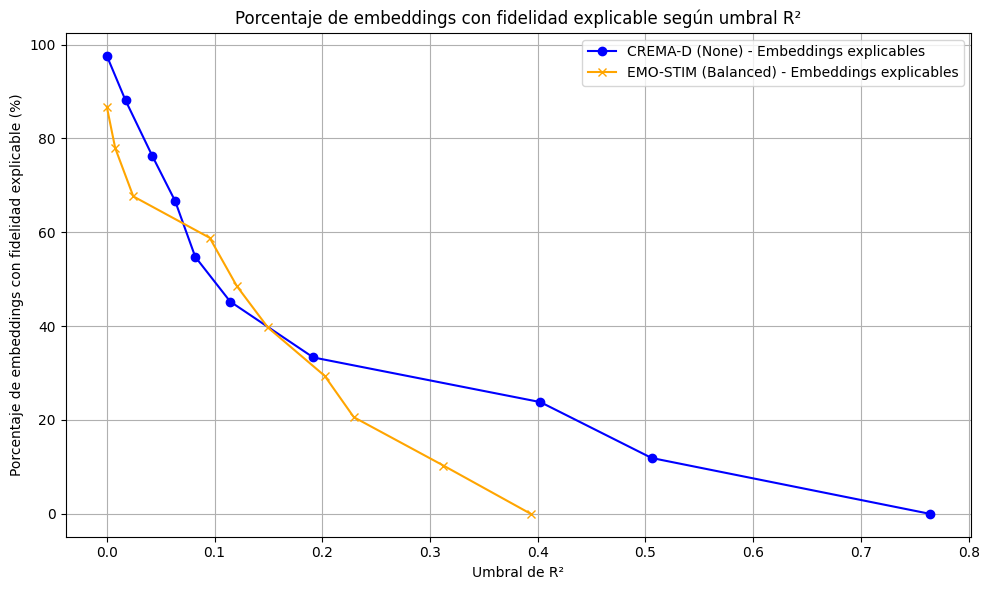

In [ ]:
import ast
import joblib
max_depth = 8
X_emb_none = np.load("/content/embeddings/emo_stim/X_emb.npy")
X_emb_bal = np.load("/content/embeddings/crema_d/X_emb.npy")
def features_usadas_hasta_depth(surrogate, max_depth):
    tree = surrogate.tree_
    features = set()
    def recurse(node_id=0, current_depth=0):
        if current_depth > max_depth or node_id == -1:
            return
        feature = tree.feature[node_id]
        if feature >= 0:
            features.add(feature)
            recurse(tree.children_left[node_id], current_depth + 1)
            recurse(tree.children_right[node_id], current_depth + 1)
    recurse()
    return sorted(features)
def calcular_variables_unicas_por_umbral(df_lasso, used_feature_names, n_points=10):
    df_usados = df_lasso[df_lasso['embedding_feature'].isin(used_feature_names)].copy()
    r2_values = np.sort(df_usados['lasso_r2'].unique())
    percentiles = np.percentile(r2_values, np.linspace(0, 100, n_points))

    cantidades = []
    listas = []
    umbrales = []

    for umbral in percentiles:
        subset = df_usados[df_usados['lasso_r2'] > umbral]
        variables_unicas = set()
        for v in subset['variables_usadas'].dropna():
            try:
                vars_list = ast.literal_eval(v)
                variables_unicas.update(vars_list)
            except:
                continue
        cantidades.append(len(variables_unicas))
        listas.append(sorted(list(variables_unicas)))
        umbrales.append(round(umbral, 4))

    return umbrales, cantidades, listas
def cargar_y_procesar_sampled(class_weight, max_depth, X_emb, n_points=10):
    surrogate = joblib.load(f"modelo_arbol_surrogate_depth{max_depth}_cw{class_weight}.joblib")
    used_features = features_usadas_hasta_depth(surrogate, max_depth)
    used_feature_names = [f"embedding_feature_{i}" for i in used_features]

    lasso_df = pd.read_csv(f"/content/lasso_r2_por_feature_depth{max_depth}_cw{class_weight}.csv")

    total_emb_used = len(used_feature_names)
    print(f"Total de embeddings usados: {total_emb_used}")

    r2_values = np.sort(lasso_df[lasso_df['embedding_feature'].isin(used_feature_names)]['lasso_r2'].unique())
    percentiles = np.percentile(r2_values, np.linspace(0, 100, n_points))

    cantidades = []
    porcentajes = []
    umbrales_sampled = []

    for umbral in percentiles:
        count_exp = (lasso_df[lasso_df['embedding_feature'].isin(used_feature_names)]['lasso_r2'] > umbral).sum()
        porcentaje_exp = 100 * count_exp / total_emb_used
        umbrales_sampled.append(round(umbral, 4))
        cantidades.append(count_exp)
        porcentajes.append(round(porcentaje_exp, 2))

    # NUEVO: calcular variables únicas
    umbrales_vars, cantidades_vars, listas_vars = calcular_variables_unicas_por_umbral(lasso_df, used_feature_names, n_points)

    return umbrales_sampled, cantidades, porcentajes, total_emb_used, cantidades_vars, listas_vars
r2_thr_none_s, cant_none_s, perc_none_s, total_none, vars_none_cant, vars_none_list = cargar_y_procesar_sampled(None, max_depth, X_emb_none)
r2_thr_bal_s, cant_bal_s, perc_bal_s, total_bal, vars_bal_cant, vars_bal_list = cargar_y_procesar_sampled('balanced', max_depth, X_emb_bal)
df_none = pd.DataFrame({
    'Umbral R2': r2_thr_none_s,
    'Embeddings explicables': cant_none_s,
    'Embeddings con fidelidad explicable (%)': perc_none_s,
    'Características vocales únicas usadas': vars_none_cant,
    'Lista de características': vars_none_list,
    'Modelo': 'CREMA-D (None)'
})

df_bal = pd.DataFrame({
    'Umbral R2': r2_thr_bal_s,
    'Embeddings explicables': cant_bal_s,
    'Embeddings con fidelidad explicable (%)': perc_bal_s,
    'Características vocales únicas usadas': vars_bal_cant,
    'Lista de características': vars_bal_list,
    'Modelo': 'EMO-STIM (Balanced)'
})
# Guardar los DataFrames en archivos CSV
df_none.to_csv("resultados_crema_d_none.csv", index=False)
df_bal.to_csv("resultados_emo_stim_bal.csv", index=False)

display(df_none)
display(df_bal)
plt.figure(figsize=(10,6))

# Porcentaje de embeddings con fidelidad explicable
plt.plot(df_none['Umbral R2'], df_none['Embeddings con fidelidad explicable (%)'],
         marker='o', label='CREMA-D (None) - Embeddings explicables', color='blue')

plt.plot(df_bal['Umbral R2'], df_bal['Embeddings con fidelidad explicable (%)'],
         marker='x', label='EMO-STIM (Balanced) - Embeddings explicables', color='orange')

plt.xlabel('Umbral de R²')
plt.ylabel('Porcentaje de embeddings con fidelidad explicable (%)')
plt.title('Porcentaje de embeddings con fidelidad explicable según umbral R²')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#ADMIN MODULE

In [ ]:
#Management of files and audios

In [ ]:
import os
#INICIO 1
import os
import glob
import kagglehub
import csv
import opensmile
import fnmatch  # Para hacer coincidir patrones con archivos

# Definir emociones válidas y archivos de audio no válidos
invalid_audio_ids = ['1088_ITH_HAP_XX.wav', '1017_IEO_SAD_HI.wav', '1040_ITH_SAD_X.wav', '1076_MTI_SAD_XX.wav']
valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Inicializa openSMILE con diferentes configuraciones
smiles = {
    "eGeMAPSv02": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02, feature_level=opensmile.FeatureLevel.Functionals),
    "emobase": opensmile.Smile(feature_set=opensmile.FeatureSet.emobase, feature_level=opensmile.FeatureLevel.Functionals),
    "eGeMAPS": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPS, feature_level=opensmile.FeatureLevel.Functionals)
}

# Función para obtener los archivos de audio
def get_audio_files(dataset_name="ejlok1/cremad", folder="AudioWAV", valid_ext=".wav", valid_emotions=None, invalid_audio_ids=None):
    path = kagglehub.dataset_download(dataset_name)
    print("[✔] Dataset descargado en:", path)

    audio_path = os.path.join(path, folder)
    audio_files = glob.glob(os.path.join(audio_path, f"*{valid_ext}"))

    if valid_emotions:
        audio_files = [f for f in audio_files if any(emotion in f for emotion in valid_emotions)]

    if invalid_audio_ids:
        audio_files = [f for f in audio_files if os.path.basename(f) not in invalid_audio_ids]

    return audio_files
# Obtener archivos de audio válidos
audio_files = get_audio_files(
    valid_emotions=valid_emotions,
    invalid_audio_ids=invalid_audio_ids
)
# Función para contar archivos con extensiones/patrones válidos
def contar_registros_en_carpeta(carpeta_o_lista, extensiones_validas=None):
    """
    Cuenta archivos en una carpeta o una lista de archivos que coincidan con las extensiones o patrones válidos.

    - `carpeta_o_lista`: Puede ser una lista de archivos o una ruta de carpeta.
    - `extensiones_validas`: Lista de extensiones y patrones a contar.
    """
    total = 0

    # Si se pasa una ruta de carpeta en lugar de una lista
    if isinstance(carpeta_o_lista, str) and os.path.isdir(carpeta_o_lista):
        # Obtener todos los archivos en la carpeta que coinciden con las extensiones o patrones
        archivos = []
        for root, dirs, files in os.walk(carpeta_o_lista):
            for file in files:
                archivos.append(os.path.join(root, file))
    else:
        # Si se pasa una lista de archivos, simplemente usaremos esa lista
        archivos = carpeta_o_lista

    # Contar los archivos que coinciden con las extensiones o patrones
    for archivo in archivos:
        for ext in extensiones_validas:
            if fnmatch.fnmatch(archivo.lower(), f"*{ext.lower()}"):
                total += 1
                break  # Si coincide con al menos un patrón, lo contamos y paramos el ciclo
    return total



# Definir las extensiones y patrones que deseas contar
extensiones_validas = [".wav", "lista*"]  # Puedes agregar más extensiones o patrones aquí

# Contar los archivos en la carpeta o lista de archivos
#audio_files = "/content/cremad/audio"  # Puede ser una carpeta en tu sistema
ya_generados_reg = contar_registros_en_carpeta(audio_files, [".wav", "lista*"])
# Si pasas una carpeta, funciona igual que antes:
# ya_generados_reg = contar_registros_en_carpeta(carpeta_o_lista=carpeta_audio, extensiones_validas=extensiones_validas)

# Mostrar el resultado
print(f"Se encontraron {ya_generados_reg} archivos válidos que coinciden con los patrones especificados.")

def extract_and_save_features(
    audio_files,
    smiles,
    output_folder,
    spectrogram_folder=None,
    metadata_folder=None,
    model_folder=None,
    results_folder=None,
    batch_folder=None,
    selected_keywords=None,
    required_headers_flat=None,
    batch_size=100,
    max_files=110
):
    audio_folder = audio_files or os.path.join(output_folder, "audio")
    spectrogram_folder = spectrogram_folder or os.path.join(output_folder, "spectrograms")
    metadata_folder = metadata_folder or os.path.join(output_folder, "metadata")
    model_folder = model_folder or os.path.join(output_folder, "models")
    results_folder = results_folder or os.path.join(output_folder, "results")
    batch_folder = batch_folder or os.path.join(output_folder, "batches")

    # Crear carpetas si no existen
    for folder in [spectrogram_folder, metadata_folder, model_folder, results_folder, batch_folder]:
        os.makedirs(folder, exist_ok=True)

    # Mostrar rutas
    print(f"Audio folder: {audio_folder}")
    print(f"Spectrograms folder: {spectrogram_folder}")
    print(f"Metadata folder: {metadata_folder}")
    print(f"Model folder: {model_folder}")
    print(f"Results folder: {results_folder}")
    print(f"Batch folder: {batch_folder}")
    print(f"Output folder: {output_folder}")
    print(f"Selected keywords: {selected_keywords}")
    print(f"Required headers: {required_headers_flat}")
    print(f"Batch size: {batch_size}")
    print(f"Max files: {max_files}")

    # Contar archivos según tipo
    conteos = {
        "Audio (.wav)": contar_registros_en_carpeta(audio_files, [".wav"]),
        "Spectrogramas (.png)": contar_registros_en_carpeta(spectrogram_folder, [".png"]),
        "Metadata (.csv)": contar_registros_en_carpeta(metadata_folder, [".csv"]),
        "Modelos (.pth)": contar_registros_en_carpeta(model_folder, [".pth"]),
        "Resultados (.csv)": contar_registros_en_carpeta(results_folder, [".csv"]),
        "Batches (.csv)": contar_registros_en_carpeta(batch_folder, [".csv"]),
    }

    # Imprimir conteos
    print("\n📊 Conteo de archivos por carpeta:")
    for tipo, cantidad in conteos.items():
        print(f" - {tipo}: {cantidad} archivos")


extract_and_save_features(audio_files, smiles,
    output_folder="/content/cremad",  # Carpeta de salida donde se almacenan los resultados
    batch_size=50,  # Tamaño del lote de procesamiento
    max_files=10  # Procesar solo 10 archivos de ejemplo
)


/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(


[✔] Dataset descargado en: /kaggle/input/cremad
Se encontraron 7438 archivos válidos que coinciden con los patrones especificados.
Audio folder: ['/kaggle/input/cremad/AudioWAV/1028_TSI_DIS_XX.wav', '/kaggle/input/cremad/AudioWAV/1075_IEO_HAP_LO.wav', '/kaggle/input/cremad/AudioWAV/1084_ITS_HAP_XX.wav', '/kaggle/input/cremad/AudioWAV/1067_IWW_DIS_XX.wav', '/kaggle/input/cremad/AudioWAV/1066_TIE_DIS_XX.wav', '/kaggle/input/cremad/AudioWAV/1027_DFA_DIS_XX.wav', '/kaggle/input/cremad/AudioWAV/1032_IEO_HAP_HI.wav', '/kaggle/input/cremad/AudioWAV/1023_TIE_SAD_XX.wav', '/kaggle/input/cremad/AudioWAV/1041_TAI_DIS_XX.wav', '/kaggle/input/cremad/AudioWAV/1004_WSI_SAD_XX.wav', '/kaggle/input/cremad/AudioWAV/1030_DFA_HAP_XX.wav', '/kaggle/input/cremad/AudioWAV/1037_WSI_NEU_XX.wav', '/kaggle/input/cremad/AudioWAV/1006_IOM_FEA_XX.wav', '/kaggle/input/cremad/AudioWAV/1053_IEO_HAP_LO.wav', '/kaggle/input/cremad/AudioWAV/1076_IEO_FEA_HI.wav', '/kaggle/input/cremad/AudioWAV/1055_TSI_SAD_XX.wav', '/kagg

In [ ]:
#Visual representation

In [ ]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("/content/cremad/embeddings/val_df.csv")

# Seleccionar las primeras 5 columnas y las últimas 3 columnas
cols = pd.concat([df.iloc[:, :3], df.iloc[:, -3:]], axis=1)

# Mostrar las primeras 5 filas como ejemplo
cols.head()


,spectrogram_path,id,dimensions,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,emotion
0,/content/cremad/spectrograms/1048_WSI_DIS_XX_s...,1048_WSI_DIS_XX_seg1,128x126,1.189239,-43.988380,DIS
1,/content/cremad/spectrograms/1006_ITS_FEA_XX_s...,1006_ITS_FEA_XX_seg0,128x126,0.177471,-37.957590,FEA
2,/content/cremad/spectrograms/1005_ITH_HAP_XX_s...,1005_ITH_HAP_XX_seg1,128x126,0.000000,-42.156190,HAP
3,/content/cremad/spectrograms/1014_IWL_NEU_XX_s...,1014_IWL_NEU_XX_seg0,128x126,0.176824,-28.902332,NEU
4,/content/cremad/spectrograms/1028_IOM_ANG_XX_s...,1028_IOM_ANG_XX_seg1,128x126,0.000000,-57.300460,ANG


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Waveform shape: torch.Size([1, 34701])


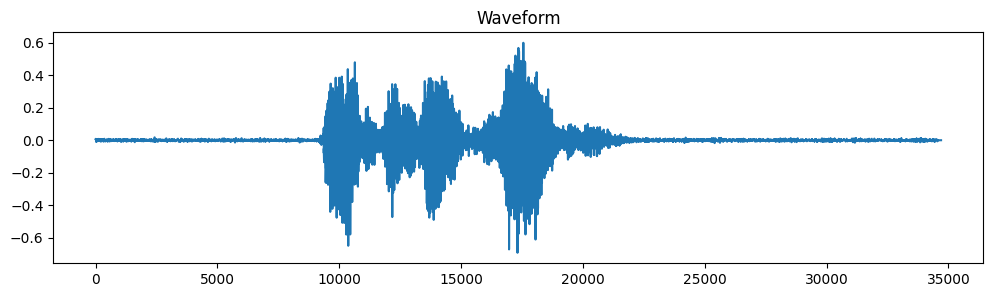

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:585: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


Spectrogram shape: torch.Size([128, 136])


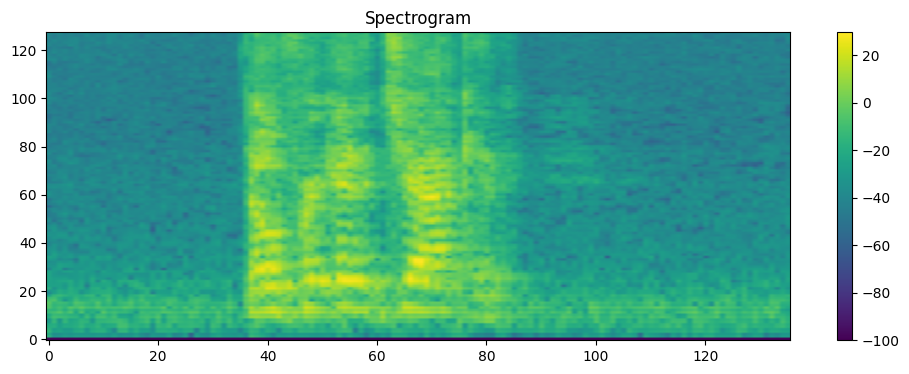

Resized spectrogram shape: torch.Size([1, 128, 313])


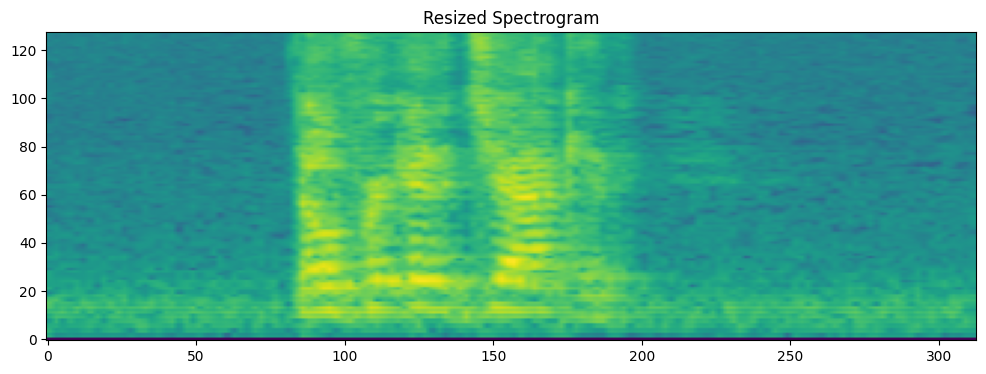

Patch embeddings shape: torch.Size([1, 152, 128])


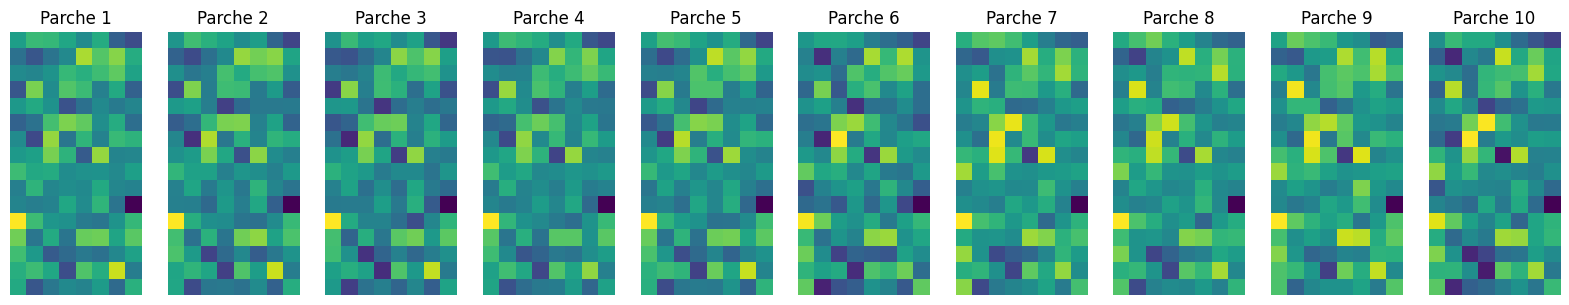

Encoded patches shape: torch.Size([1, 152, 128])


In [ ]:
import torch
import torch.nn as nn
import torchaudio
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1️⃣ Cargar audio
# ----------------------------
audio_path = "/content/1001_DFA_FEA_XX.wav"
waveform, sample_rate = torchaudio.load(audio_path)
print("Waveform shape:", waveform.shape)

# Visualizar el audio
plt.figure(figsize=(12, 3))
plt.plot(waveform.t().numpy())
plt.title("Waveform")
plt.show()

# ----------------------------
# 2️⃣ Convertir a espectrograma
# ----------------------------
n_fft = 512
hop_length = 256
spectrogram = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=128
)(waveform)

spectrogram = torchaudio.transforms.AmplitudeToDB()(spectrogram)
spectrogram = spectrogram.squeeze(0)  # [128, time]

print("Spectrogram shape:", spectrogram.shape)

plt.figure(figsize=(12, 4))
plt.imshow(spectrogram.numpy(), origin='lower', aspect='auto', cmap='viridis')
plt.title("Spectrogram")
plt.colorbar()
plt.show()

# ----------------------------
# 3️⃣ Redimensionar a tamaño ViT
# ----------------------------
img_size = (128, 313)  # tamaño esperado por el ViT
spectrogram_resized = torch.nn.functional.interpolate(
    spectrogram.unsqueeze(0).unsqueeze(0), size=img_size, mode='bilinear', align_corners=False
)
spectrogram_resized = spectrogram_resized.squeeze(0)
print("Resized spectrogram shape:", spectrogram_resized.shape)

plt.figure(figsize=(12, 4))
plt.imshow(spectrogram_resized[0].numpy(), origin='lower', aspect='auto', cmap='viridis')
plt.title("Resized Spectrogram")
plt.show()

# ----------------------------
# 4️⃣ Patch Embedding
# ----------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=(128, 313), patch_size=16, in_chans=1, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size[0] // patch_size) * (img_size[1] // patch_size)
        self.num_patches = num_patches

    def forward(self, x):
        x = self.proj(x)              # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2)              # [B, embed_dim, num_patches]
        x = x.transpose(1, 2)         # [B, num_patches, embed_dim]
        return x

patch_embed = PatchEmbedding(img_size=img_size, patch_size=16, in_chans=1, embed_dim=128)
x = spectrogram_resized.unsqueeze(0)  # [1, 1, H, W]
patch_embeddings = patch_embed(x)
print("Patch embeddings shape:", patch_embeddings.shape)

# ----------------------------
# 5️⃣ Visualizar algunos parches
# ----------------------------
num_patches_to_show = 10
fig, axes = plt.subplots(1, num_patches_to_show, figsize=(20, 4))
for i in range(num_patches_to_show):
    patch_vec = patch_embeddings[0, i].detach().numpy()
    size = int(np.sqrt(patch_vec.size))
    patch_image = patch_vec.reshape(16, 8)  # aproximación
    axes[i].imshow(patch_image, cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f'Parche {i+1}')
plt.show()

# ----------------------------
# 6️⃣ Transformador (opcional: solo primer bloque para visualizar)
# ----------------------------
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.layernorm1(x), self.layernorm1(x), self.layernorm1(x))[0]
        x = x + self.mlp(self.layernorm2(x))
        return x

encoder = TransformerEncoder(embed_dim=128)
x_encoded = encoder(patch_embeddings)
print("Encoded patches shape:", x_encoded.shape)


In [ ]:
#TRAINING


== Entrenando modelo #1 ==
    Epoch [1/10] - Loss: 3.0509
    Epoch [2/10] - Loss: 0.8230
    Epoch [3/10] - Loss: 0.4924
    Epoch [4/10] - Loss: 0.2944
    Epoch [5/10] - Loss: 0.1764
    Epoch [6/10] - Loss: 0.1056
    Epoch [7/10] - Loss: 0.0659
    Epoch [8/10] - Loss: 0.0431
    Epoch [9/10] - Loss: 0.0296
    Epoch [10/10] - Loss: 0.0204

Accuracy en validación: 99.19%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.984     0.988     0.986       254
         DIS      1.000     1.000     1.000       254
         FEA      1.000     0.992     0.996       254
         HAP      0.988     1.000     0.994       254
         NEU      0.978     1.000     0.989       218
         SAD      1.000     0.972     0.986       254

    accuracy                          0.992      1488
   macro avg      0.992     0.992     0.992      1488
weighted avg      0.992     0.992     0.992      1488



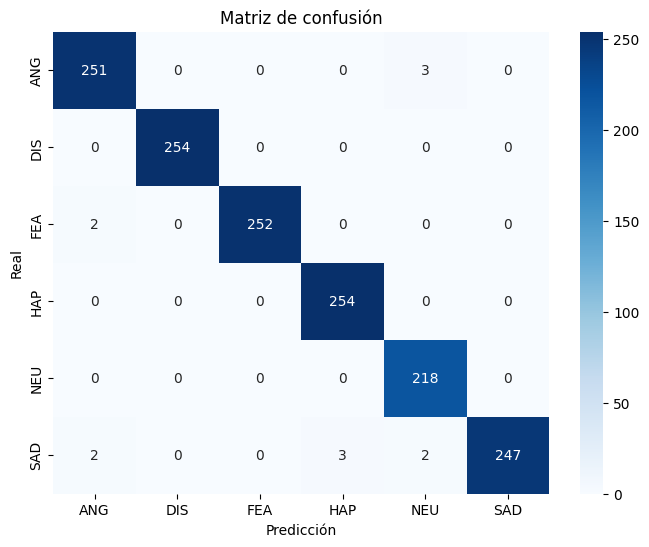

💾 Modelo #1 guardado como 'modelo_1_99_20250501_210144.pth' con accuracy de 99.19%
✔ Mejor modelo actualizado (99.19%)

== Entrenando modelo #2 ==
    Epoch [1/10] - Loss: 3.0069
    Epoch [2/10] - Loss: 0.7323
    Epoch [3/10] - Loss: 0.3721
    Epoch [4/10] - Loss: 0.1953
    Epoch [5/10] - Loss: 0.1008
    Epoch [6/10] - Loss: 0.0580
    Epoch [7/10] - Loss: 0.0363
    Epoch [8/10] - Loss: 0.0228
    Epoch [9/10] - Loss: 0.0162
    Epoch [10/10] - Loss: 0.0118

Accuracy en validación: 98.86%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.973     0.980     0.976       254
         DIS      0.992     1.000     0.996       254
         FEA      0.992     0.976     0.984       254
         HAP      1.000     0.988     0.994       254
         NEU      0.991     1.000     0.995       218
         SAD      0.984     0.988     0.986       254

    accuracy                          0.989      1488
   macro avg      0.989     0.989     0.989

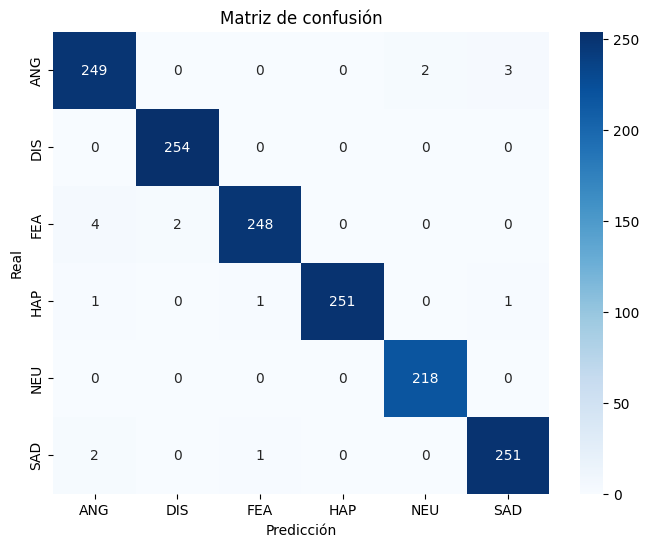

💾 Modelo #2 guardado como 'modelo_2_98_20250501_213336.pth' con accuracy de 98.86%
📄 Métricas guardadas en 'metricas_modelos_20250501_213336.csv'
💾 Modelo final guardado como 'modelo_final_99_20250501_213336.pth' con accuracy de 99.19%


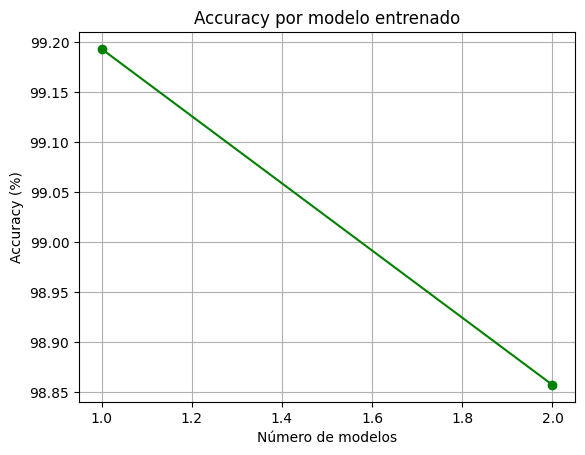

In [ ]:
#ENTRENAMIENTO 1
import os
import json
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from datetime import datetime
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clases válidas
valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Dataset personalizado
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_df, spectrogram_dir, transform=None):
        self.metadata = metadata_df.reset_index(drop=True)
        self.spectrogram_dir = spectrogram_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_path = self.metadata.iloc[idx]['spectrogram_path']
        emotion = self.metadata.iloc[idx]['emotion']
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label = valid_emotions.index(emotion)
        return image, label

# Modelo
class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, input_size=(128, 313), num_classes=len(valid_emotions)):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()
        dummy_input = torch.randn(1, 1, *input_size)
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]
        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Transformaciones
input_size = (128, 313)
transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
])

# Función para entrenamiento
def train_model(model, dataloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        print(f"    Epoch [{epoch + 1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

# Evaluación con métricas
def evaluate_model_detailed(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=valid_emotions, digits=3, output_dict=True)
    print(f"\nAccuracy en validación: {acc * 100:.2f}%")
    print("\nF1-score por emoción:")
    print(classification_report(y_true, y_pred, target_names=valid_emotions, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=valid_emotions, yticklabels=valid_emotions)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de confusión')
    plt.show()

    metricas_por_clase = {
        emo: {
            'precision': report[emo]['precision'],
            'recall': report[emo]['recall'],
            'f1': report[emo]['f1-score']
        } for emo in valid_emotions
    }

    return acc, metricas_por_clase

# Función principal de entrenamiento múltiple
def entrenar_varios_modelos(n_modelos, train_loader, val_loader, valid_emotions, guardar=True):
    mejores_accuracies = []
    mejor_modelo = None
    mejor_acc = 0.0
    resultados_modelos = []

    for run in range(n_modelos):
        print(f"\n== Entrenando modelo #{run + 1} ==")
        model = VisionTransformer()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        train_model(model, train_loader, criterion, optimizer, num_epochs=10)
        acc, metricas = evaluate_model_detailed(model, val_loader)
        mejores_accuracies.append(acc * 100)

        for emo in valid_emotions:
            resultados_modelos.append({
                'modelo': run + 1,
                'emotion': emo,
                'precision': metricas[emo]['precision'],
                'recall': metricas[emo]['recall'],
                'f1': metricas[emo]['f1'],
                'accuracy': acc
            })
        # Guardar todos los modelos entrenados con un nombre único
        if guardar:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            filename = f"modelo_{run + 1}_{int(acc * 100)}_{timestamp}.pth"
            torch.save(model.state_dict(), filename)
            print(f"💾 Modelo #{run + 1} guardado como '{filename}' con accuracy de {acc * 100:.2f}%")

        if acc > mejor_acc:
            mejor_acc = acc
            mejor_modelo = model.state_dict()
            print(f"✔ Mejor modelo actualizado ({mejor_acc * 100:.2f}%)")

    # Guardar métricas en CSV
    if guardar:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        df_resultados = pd.DataFrame(resultados_modelos)
        df_resultados.to_csv(f"metricas_modelos_{timestamp}.csv", index=False)
        print(f"📄 Métricas guardadas en 'metricas_modelos_{timestamp}.csv'")

        if mejor_modelo:
            filename = f"modelo_final_{int(mejor_acc * 100)}_{timestamp}.pth"
            torch.save(mejor_modelo, filename)
            print(f"💾 Modelo final guardado como '{filename}' con accuracy de {mejor_acc * 100:.2f}%")

    # Graficar evolución del accuracy
    plt.plot(range(1, n_modelos + 1), mejores_accuracies, marker='o', color='green')
    plt.title("Accuracy por modelo entrenado")
    plt.xlabel("Número de modelos")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.show()

    return mejores_accuracies

# ========== CARGA DE DATOS CON STRATIFIED SPLIT ==========
features_df = pd.read_csv("/content/cremad/features/features_combined.csv")
emotions_df = pd.read_csv("/content/cremad/features/emotions_metadata.csv")

# Unir por columna común (ajusta si usas otro nombre, como 'id', 'filename' o similar)
metadata = pd.merge(features_df, emotions_df, on='id')

train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata["emotion"], random_state=42)

train_dataset = SpectrogramDataset(train_df, "spectrograms", transform=transform)
val_dataset = SpectrogramDataset(val_df, "spectrograms", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# ========= EJECUTAR ENTRENAMIENTO =========
n_modelos = 2
accuracies = entrenar_varios_modelos(
    n_modelos,
    train_loader,
    val_loader,
    valid_emotions,
    guardar=True
)


In [ ]:
procesar_audios_n(
    audio_files=audio_files,
    smile_models=smiles,
    max_files=7438,
    output_root="/content/cremad",
    batch_size=batch_size,
    segment_duration=1,
    modo="test",
    modelo_de_clasificacion=model,
    transform=transform
)


🔍 Procesando con modelo: eGeMAPSv02

🎧 Procesando hasta 7438 archivos de audio en batches de 20...


  0%|          | 0/7438 [00:00<?, ?it/s]

✅ Espectrograma generado: /content/cremad/spectrograms/1028_TSI_DIS_XX_seg0.png
✅ Espectrograma generado: /content/cremad/spectrograms/1028_TSI_DIS_XX_seg1.png
✅ Espectrograma generado: /content/cremad/spectrograms/1028_TSI_DIS_XX_seg2.png


  0%|          | 1/7438 [00:08<17:06:11,  8.28s/it]

✅ Espectrograma generado: /content/cremad/spectrograms/1075_IEO_HAP_LO_seg0.png
✅ Espectrograma generado: /content/cremad/spectrograms/1075_IEO_HAP_LO_seg1.png


...

✅ Espectrograma generado: /content/cremad/spectrograms/1078_IWL_SAD_XX_seg0.png
✅ Espectrograma generado: /content/cremad/spectrograms/1078_IWL_SAD_XX_seg1.png
✅ Espectrograma generado: /content/cremad/spectrograms/1078_IWL_SAD_XX_seg2.png


 10%|▉         | 725/7438 [13:15<1:54:20,  1.02s/it]

✅ Espectrograma generado: /content/cremad/spectrograms/1011_IWW_NEU_XX_seg0.png
✅ Espectrograma generado: /content/cremad/spectrograms/1011_IWW_NEU_XX_seg1.png
✅ Espectrograma generado: /content/cremad/spectrograms/1011_IWW_NEU_XX_seg2.png


 10%|▉         | 727/7438 [13:16<1:39:05,  1.13it/s]

⏩ Espectrograma ya existe: /content/cremad/spectrograms/1012_TAI_FEA_XX_seg0.png
⏩ Espectrograma ya existe: /content/cremad/spectrograms/1012_TAI_FEA_XX_seg1.png
⏩ Espectrograma ya existe: /content/cremad/spectrograms/1012_TAI_FEA_XX_seg2.png
✅ Espectrograma generado: /content/cremad/spectrograms/1087_DFA_HAP_XX_seg0.png
✅ Espectrograma generado: /content/cremad/spectrograms/1087_DFA_HAP_XX_seg1.png


In [ ]:
#Calling in different modalities(train/test) and tail parameters(or default like the dataset in kaggle)

In [ ]:
#Base image generation

In [ ]:
#Surrogate base, config of Lasso and Dt models, and 'y' variables enhancement)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import os
import joblib


# ---------------- Configuración ----------------
SEED = 42
best_max_depth = 12
best_class_weight = None  # o 'balanced'
text_depth = 12

# Cargar datos
X_emb = np.load("/content/embeddings/crema_d/X_emb.npy")
y_pred = np.load("/content/embeddings/crema_d/y_pred.npy")
#X_emb = np.load("/content/embeddings/emo_stim/X_emb.npy")
#y_pred = np.load("/content/embeddings/emo_stim/y_pred.npy")
#val_df = pd.read_csv('/content/embeddings/emo_stim/val_df.csv')  # debe estar alineado con X_emb
#df_original = pd.read_csv('/content/features/Clips_Peliculas_EmoStim_21A_1s_Compare2016.csv')
#df_original = pd.read_csv('/content/features/Clips_Peliculas_EmoStim_21A_1s1.csv')
val_df = pd.read_csv('/content/embeddings/crema_d/val_df.csv')  # debe estar alineado con X_emb
#df_original = pd.read_csv('/content/features/features_combined_Compare2016.csv')
df_original = pd.read_csv('/content/features/features_combined.csv')

# --------- Función para filtrar y alinear IDs ---------
def filtrar_y_alinear_por_id(df_base, df_a_filtrar, id_col='id'):
    """
    Filtra y alinea df_a_filtrar para que contenga solo los IDs que estén en df_base,
    asegurando que los IDs estén en minúsculas y en string,
    y mantiene el orden de df_base.
    """
    df_base.columns = df_base.columns.str.lower()
    df_a_filtrar.columns = df_a_filtrar.columns.str.lower()

    df_base[id_col] = df_base[id_col].astype(str).str.lower()
    df_a_filtrar[id_col] = df_a_filtrar[id_col].astype(str).str.lower()

    ids_comunes = set(df_base[id_col]).intersection(set(df_a_filtrar[id_col]))

    df_base_filtrado = df_base[df_base[id_col].isin(ids_comunes)].copy()
    df_filtrado_alineado = df_a_filtrar[df_a_filtrar[id_col].isin(ids_comunes)].copy()

    df_filtrado_alineado = df_filtrado_alineado.set_index(id_col).loc[df_base_filtrado[id_col]].reset_index()

    return df_base_filtrado, df_filtrado_alineado


# --------- Entrenar surrogate ---------
def entrenar_surrogate(X_emb, y_pred,
                       model_path="/content/surrogate_model1.pkl",
                       text_path="/content/surrogate_tree1.txt",
                       max_depth=12,
                       class_weight=None,
                       seed=42,
                       text_depth=12):
    if os.path.exists(model_path) and os.path.exists(text_path):
        print("📦 Cargando surrogate ya entrenado...")
        surrogate = joblib.load(model_path)
        return surrogate

    print("🧠 Entrenando nuevo surrogate...")
    surrogate = DecisionTreeClassifier(max_depth=max_depth, random_state=seed, class_weight=class_weight)
    surrogate.fit(X_emb, y_pred)

    y_pred_surrogate = surrogate.predict(X_emb)
    fidelity = accuracy_score(y_pred, y_pred_surrogate)
    print(f"✅ Fidelidad del surrogate: {fidelity:.3f}")

    joblib.dump(surrogate, model_path)
    print(f"💾 Modelo guardado en: {model_path}")

    feature_names = [f"emb_{i}" for i in range(X_emb.shape[1])]
    tree_text = export_text(surrogate, feature_names=feature_names, max_depth=text_depth)
    with open(text_path, "w") as f:
        f.write(tree_text)
    print(f"📄 Árbol guardado en texto en: {text_path}")

    return surrogate


surrogate = entrenar_surrogate(X_emb, y_pred)

# --------- Extraer features usadas ---------
tree = surrogate.tree_
used_feature_indices = np.unique(tree.feature[tree.feature >= 0])
print(f"✅ Features de embedding usadas: {used_feature_indices.tolist()}")

data = {}
for idx, row in val_df.iterrows():
    img_id = row['id']
    data[img_id] = {f"feature_{i}": X_emb[idx, i] for i in used_feature_indices}

df_targets = pd.DataFrame.from_dict(data, orient='index').reset_index().rename(columns={'index': 'id'})
df_targets.to_csv("/content/features_surrogate_features.csv", index=False)
print("📁 Guardado df_targets en CSV con las features del surrogate")

# --------- Filtrar y alinear val_df y df_original ---------
val_df_filtrado, df_original_filtrado = filtrar_y_alinear_por_id(val_df, df_original)

print(f"Cantidad IDs en val_df después de filtrar: {len(val_df_filtrado)}")
print(f"Cantidad IDs en df_original después de filtrar: {len(df_original_filtrado)}")

# --------- Preparar X_original ---------
drop_cols = ['spectrogram_path', 'id', 'dimensions', 'height', 'width',
             'sampling_rate', 'window_size', 'hop_size', 'n_fft',
             'segment_index', 'segment_duration', 'window_function', 'emotion']
predictor_cols = [col for col in df_original_filtrado.columns if col not in drop_cols]
X_original = df_original_filtrado[predictor_cols].values

# --------- Alinear df_targets con val_df_filtrado ---------
#df_targets = df_targets.set_index('id').loc[val_df_filtrado['id']].reset_index()
df_targets_alineado = pd.merge(val_df_filtrado[['id']], df_targets, on='id', how='left')

target_columns = [col for col in df_targets.columns if col.startswith("feature_")]

assert len(X_original) == len(df_targets), "❌ Alineación incorrecta entre X_original y df_targets"

# --------- LassoCV sobre cada target ---------
results = []
for col in target_columns:
    y = df_targets[col].values
    model = LassoCV(cv=5, random_state=SEED, max_iter=100000).fit(X_original, y)
    y_pred = model.predict(X_original)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    used_vars = [var for var, coef in zip(predictor_cols, model.coef_) if coef != 0]

    results.append({
        'embedding_feature': col,
        'mse': mse,
        'r2': r2,
        'n_vars_used': len(used_vars),
        'used_vars': used_vars
    })

# --------- Guardar resultados ---------
df_results = pd.DataFrame(results).sort_values(by='mse')
df_results.to_csv("/content/resultados_lasso_embedding_vs_nuevo_dataset_CremaCompare.csv", index=False)

print("✅ Resultados guardados en: resultados_lasso_embedding_vs_nuevo_dataset_EmoCompare.csv")


📦 Cargando surrogate ya entrenado...
✅ Features de embedding usadas: [529, 533, 2076, 4089, 4283, 7902, 10682, 10843, 12383, 14488, 18489, 20666, 20678, 21924, 22686, 23074, 25912, 28332, 28413, 30181, 31067, 35902, 38422, 41055, 41208, 41525, 41885, 42545, 42929, 44044, 47595, 50448, 50452, 50460, 50934, 51807, 55460, 90249, 90371, 90397, 90702, 92993, 93465, 97204, 100226, 100554, 103304, 110372, 116707, 118278, 120495, 120634, 123357, 127153, 140314, 140477, 141090, 141829, 143867, 145530, 147608]
📁 Guardado df_targets en CSV con las features del surrogate
Cantidad IDs en val_df después de filtrar: 1870
Cantidad IDs en df_original después de filtrar: 1870
✅ Resultados guardados en: resultados_lasso_embedding_vs_nuevo_dataset_EmoCompare.csv


In [ ]:
#Reloading of training model, embeddings and features files

In [ ]:
model = VisionTransformer()
model.load_state_dict(torch.load("/content/checkpoints/modelo_final_99_20250501_213336.pth", map_location=torch.device('cpu')))
model.eval()
X_emb, y_pred_model = obtener_embeddings_y_predicciones(model, val_loader)
X_emb = np.load("/content/embeddings/emo_stim/X_emb.npy")
y_pred = np.load("/content/embeddings/emo_stim/y_pred.npy")
val_df = pd.read_csv("/content/embeddings/emo_stim/val_df.csv")
val_df = val_df.reset_index(drop=True)

In [ ]:
#Quick look of embedding and features

In [ ]:
import numpy as np
import pandas as pd

X_emb = np.load("/content/embeddings/crema_d/X_emb.npy")
y_pred = np.load("/content/embeddings/crema_d/y_pred.npy")
val_df = pd.read_csv("/content/embeddings/crema_d/val_df.csv")
val_df = val_df.reset_index(drop=True)
print(f"X_emb shape: {X_emb.shape}")   # Esperado: (n_samples, n_features)
print(f"y_pred shape: {y_pred.shape}") # Esperado: (n_samples,)
print(f"val_df shape: {val_df.shape}") # Esperado: (n_samples, n_columns)

X_emb shape: (1870, 159744)
y_pred shape: (1870,)
val_df shape: (1870, 101)


In [ ]:
#Dummy generation

In [ ]:
import opensmile
import pandas as pd
import numpy as np
import soundfile as sf

# Crear audio dummy de 1 segundo (silencio)
dummy_audio = np.zeros(16000)
sf.write("dummy.wav", dummy_audio, 16000)

# Diccionario con los modelos que usaste
smiles = {
    "eGeMAPSv02": opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals),
    "emobase": opensmile.Smile(
        feature_set=opensmile.FeatureSet.emobase,
        feature_level=opensmile.FeatureLevel.Functionals),
    "eGeMAPS": opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPS,
        feature_level=opensmile.FeatureLevel.Functionals),
}

# Extraer características y guardar los nombres
for nombre_modelo, extractor in smiles.items():
    df = extractor.process_file("dummy.wav")
    columnas = df.columns.tolist()

    # Guardar en archivo CSV
    pd.Series(columnas).to_csv(f"{nombre_modelo}_feature_names.csv", index=False, header=False)
    print(f"✅ Modelo '{nombre_modelo}' tiene {len(columnas)} columnas. Guardado en: {nombre_modelo}_feature_names.csv")


/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(


✅ Modelo 'eGeMAPSv02' tiene 88 columnas. Guardado en: eGeMAPSv02_feature_names.csv
✅ Modelo 'emobase' tiene 988 columnas. Guardado en: emobase_feature_names.csv
✅ Modelo 'eGeMAPS' tiene 88 columnas. Guardado en: eGeMAPS_feature_names.csv


In [ ]:
#Heights of class(emotion) by range and weight

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
import pandas as pd
import re

SEED = 42

max_depths = list(range(1, 13))  # Puedes ampliar esto
use_class_weight = ['balanced', None]

results = []
csv_rows = []

print("\n🔍 Evaluando fidelidad y clases en export_text por depth...\n")

for cw in use_class_weight:
    print(f"\n=== Probando class_weight={cw} ===")

    for depth in max_depths:
        # Entrenar árbol surrogate
        surrogate = DecisionTreeClassifier(max_depth=depth, random_state=SEED, class_weight=cw)
        surrogate.fit(X_emb, y_pred_model)

        # Predicciones y fidelidad
        y_pred_surrogate = surrogate.predict(X_emb)
        fidelity = accuracy_score(y_pred_model, y_pred_surrogate)

        clases_pred = np.unique(y_pred_surrogate)

        # Mostrar resumen general del modelo
        print(f"\n📌 max_depth={depth:2d} | class_weight={cw} | Fidelidad: {fidelity:.3f} | Clases cubiertas: {clases_pred}")

        # Evaluar export_text desde profundidad 1 hasta depth actual
        for d in range(1, depth + 1):
            tree_text_d = export_text(surrogate, max_depth=d)
            clases_text_d = re.findall(r"class: (\d+)", tree_text_d)
            clases_unicas_d = np.unique(np.array(clases_text_d, dtype=int))

            print(f"  └── Text_depth {d:2d} = Clases en export_text: {clases_unicas_d}")

            # Guardar en CSV
            csv_rows.append({
                'class_weight': cw,
                'model_max_depth': depth,
                'export_text_depth': d,
                'fidelity': fidelity,
                'clases_predichas': list(clases_pred),
                'n_clases_pred': len(clases_pred),
                'clases_export_text': list(clases_unicas_d),
                'n_clases_export_text': len(clases_unicas_d)
            })

# Convertir a DataFrame y guardar como CSV
df_results = pd.DataFrame(csv_rows)
df_results.to_csv("detalle_export_text_por_depth.csv", index=False)

# Mostrar en display si estás en Jupyter
from IPython.display import display
display(df_results)



🔍 Evaluando fidelidad y clases en export_text por depth...


=== Probando class_weight=balanced ===

📌 max_depth= 1 | class_weight=balanced | Fidelidad: 0.320 | Clases cubiertas: [1 3]
  └── Text_depth  1 = Clases en export_text: [1 3]

📌 max_depth= 2 | class_weight=balanced | Fidelidad: 0.595 | Clases cubiertas: [0 1 2 3]
  └── Text_depth  1 = Clases en export_text: [0 1 2 3]
  └── Text_depth  2 = Clases en export_text: [0 1 2 3]

📌 max_depth= 3 | class_weight=balanced | Fidelidad: 0.768 | Clases cubiertas: [0 1 2 3 4 5]
  └── Text_depth  1 = Clases en export_text: []
  └── Text_depth  2 = Clases en export_text: [0 1 2 3 4 5]
  └── Text_depth  3 = Clases en export_text: [0 1 2 3 4 5]

📌 max_depth= 4 | class_weight=balanced | Fidelidad: 0.919 | Clases cubiertas: [0 1 2 3 4 5]
  └── Text_depth  1 = Clases en export_text: []
  └── Text_depth  2 = Clases en export_text: [1 2]
  └── Text_depth  3 = Clases en export_text: [0 1 2 3 4 5]
  └── Text_depth  4 = Clases en export_text: [0 1 2 3 

,class_weight,model_max_depth,export_text_depth,fidelity,clases_predichas,n_clases_pred,clases_export_text,n_clases_export_text
0,balanced,1,1,0.319786,"[1, 3]",2,"[1, 3]",2
1,balanced,2,1,0.595187,"[0, 1, 2, 3]",4,"[0, 1, 2, 3]",4
2,balanced,2,2,0.595187,"[0, 1, 2, 3]",4,"[0, 1, 2, 3]",4
3,balanced,3,1,0.768449,"[0, 1, 2, 3, 4, 5]",6,[],0
4,balanced,3,2,0.768449,"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",6
...,...,...,...,...,...,...,...,...
151,None,12,8,1.000000,"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",6
152,None,12,9,1.000000,"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",6
153,None,12,10,1.000000,"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",6
154,None,12,11,1.000000,"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",6


In [ ]:
#Behavior of Embeddings

In [ ]:
#Umbral and Lasso Nr. Characteristics

   max_depth class_weight  fidelity  n_features_used  avg_lasso_mse  \
0          8         None  0.983422               42       0.001642   

   avg_lasso_r2  avg_lasso_vars_used  \
0      0.197127            16.333333   

                                         umbrales_r2  \
0  [0.0, 0.0174, 0.0424, 0.0634, 0.0821, 0.1145, ...   

               cant_vars_unicas_por_umbral  \
0  [47, 47, 47, 47, 34, 34, 31, 29, 20, 0]   

                       listas_vars_unicas_por_umbral  
0  [[F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope...  


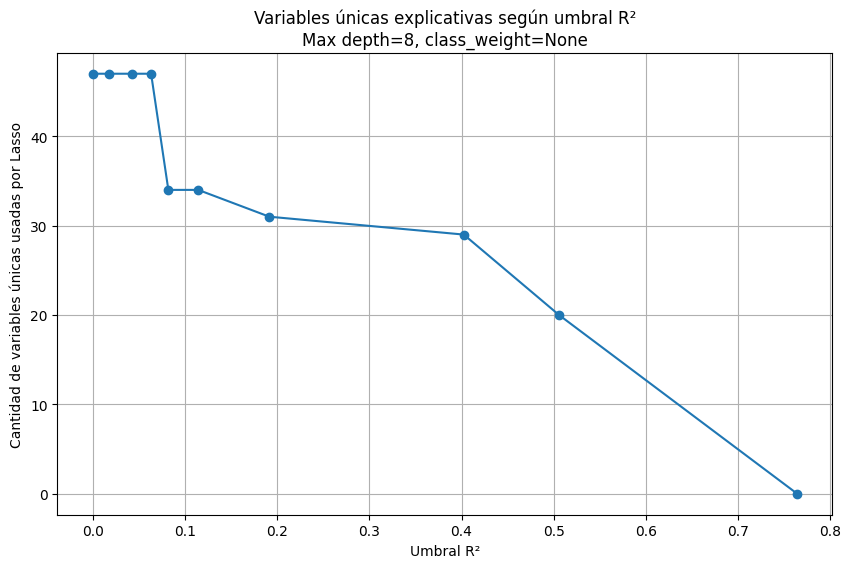

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt

SEED = 42

# Configuraciones a evaluar
model_configs = [
    {'max_depth': 8,  'class_weight': None}
]

text_depth = 12  # profundidad para extraer features del árbol

def features_usadas_hasta_depth(surrogate, max_depth):
    tree = surrogate.tree_
    features = set()
    def recurse(node_id=0, current_depth=0):
        if current_depth > max_depth or node_id == -1:
            return
        feature = tree.feature[node_id]
        if feature >= 0:
            features.add(feature)
            recurse(tree.children_left[node_id], current_depth + 1)
            recurse(tree.children_right[node_id], current_depth + 1)
    recurse()
    return sorted(features)

def calcular_variables_unicas_por_umbral(df_lasso, used_feature_names, n_points=10):
    df_usados = df_lasso[df_lasso['embedding_feature'].isin(used_feature_names)].copy()
    r2_values = np.sort(df_usados['lasso_r2'].unique())
    percentiles = np.percentile(r2_values, np.linspace(0, 100, n_points))

    cantidades = []
    listas = []
    umbrales = []

    for umbral in percentiles:
        subset = df_usados[df_usados['lasso_r2'] > umbral]
        variables_unicas = set()
        for v in subset['variables_usadas'].dropna():
            # variables_usadas es lista, no string. Si usas string, cambiar a ast.literal_eval(v)
            if isinstance(v, str):
                try:
                    vars_list = ast.literal_eval(v)
                    variables_unicas.update(vars_list)
                except:
                    continue
            else:
                variables_unicas.update(v)
        cantidades.append(len(variables_unicas))
        listas.append(sorted(list(variables_unicas)))
        umbrales.append(round(umbral, 4))

    return umbrales, cantidades, listas

# Cargar datos (ajustar paths según tu entorno)
X_emb = np.load("/content/embeddings/crema_d/X_emb.npy")  # embeddings
y_pred = np.load("/content/embeddings/crema_d/y_pred.npy")  # predicciones del modelo original (surrogate target)
val_df = pd.read_csv("/content/embeddings/crema_d/val_df.csv").reset_index(drop=True)  # datos originales

# Variables originales que no se usan para predecir embeddings
drop_cols = ['spectrogram_path', 'id', 'dimensions', 'height', 'width',
             'sampling_rate', 'window_size', 'hop_size', 'n_fft',
             'segment_index', 'segment_duration', 'window_function', 'emotion']
predictor_cols = [col for col in val_df.columns if col not in drop_cols]
X_original = val_df[predictor_cols].values

results_summary = []

for config in model_configs:
    max_depth = config['max_depth']
    class_weight = config['class_weight']

    # Entrenar surrogate
    surrogate = DecisionTreeClassifier(max_depth=max_depth, random_state=SEED, class_weight=class_weight)
    surrogate.fit(X_emb, y_pred)

    # Fidelity
    y_pred_surrogate = surrogate.predict(X_emb)
    fidelity = accuracy_score(y_pred, y_pred_surrogate)

    # Features usadas hasta cierta profundidad
    used_features = features_usadas_hasta_depth(surrogate, text_depth)
    used_feature_names = [f"embedding_feature_{i}" for i in used_features]

    # Crear DataFrame targets para Lasso solo con features usadas
    data_targets = {f"embedding_feature_{i}": X_emb[:, i] for i in used_features}
    df_targets = pd.DataFrame(data_targets)

    lasso_results = []
    variables_usadas = []

    for target_feat in df_targets.columns:
        y = df_targets[target_feat].values
        model = LassoCV(cv=5, random_state=SEED, max_iter=100000).fit(X_original, y)
        y_pred_lasso = model.predict(X_original)

        mse = mean_squared_error(y, y_pred_lasso)
        r2 = r2_score(y, y_pred_lasso)
        n_vars_used = np.sum(model.coef_ != 0)

        selected_vars = [predictor_cols[i] for i, c in enumerate(model.coef_) if c != 0]

        lasso_results.append({'mse': mse, 'r2': r2, 'n_vars_used': n_vars_used})
        variables_usadas.append(selected_vars)

    df_lasso_r2_individual = pd.DataFrame({
        'embedding_feature': df_targets.columns,
        'lasso_r2': [r['r2'] for r in lasso_results],
        'lasso_mse': [r['mse'] for r in lasso_results],
        'n_vars_used': [r['n_vars_used'] for r in lasso_results],
        'variables_usadas': variables_usadas,
        'max_depth': max_depth,
        'class_weight': class_weight
    })

    # Guardar CSV si quieres
    df_lasso_r2_individual.to_csv(f"/content/lasso_r2_por_feature_depth{max_depth}_cw{class_weight}.csv", index=False)

    # Calcular resumen variables únicas según umbral R2
    umbrales, cantidades_vars, listas_vars = calcular_variables_unicas_por_umbral(df_lasso_r2_individual, used_feature_names, n_points=10)

    avg_mse = np.mean([r['mse'] for r in lasso_results])
    avg_r2 = np.mean([r['r2'] for r in lasso_results])
    avg_vars_used = np.mean([r['n_vars_used'] for r in lasso_results])

    results_summary.append({
        'max_depth': max_depth,
        'class_weight': class_weight,
        'fidelity': fidelity,
        'n_features_used': len(used_features),
        'avg_lasso_mse': avg_mse,
        'avg_lasso_r2': avg_r2,
        'avg_lasso_vars_used': avg_vars_used,
        'umbrales_r2': umbrales,
        'cant_vars_unicas_por_umbral': cantidades_vars,
        'listas_vars_unicas_por_umbral': listas_vars
    })

# Mostrar resumen
df_comparison = pd.DataFrame(results_summary)
print(df_comparison.sort_values(by='fidelity', ascending=False))

# Graficar ejemplo para la primera configuración
plt.figure(figsize=(10,6))
plt.plot(df_comparison.loc[0, 'umbrales_r2'], df_comparison.loc[0, 'cant_vars_unicas_por_umbral'], marker='o')
plt.xlabel('Umbral R²')
plt.ylabel('Cantidad de variables únicas usadas por Lasso')
plt.title(f"Variables únicas explicativas según umbral R²\nMax depth={df_comparison.loc[0,'max_depth']}, class_weight={df_comparison.loc[0,'class_weight']}")
plt.grid(True)
plt.show()


In [ ]:
#Embeddings explanability example

In [ ]:
# Supongamos que ya tienes df_usadas que contiene las filas de embeddings usados,
# con columnas:
# - 'embedding_feature' (nombre embedding)
# - 'variables_usadas' (lista o string con variables originales que explican ese embedding)

# Primero, extraemos todas las variables originales usadas para explicar al menos un embedding
variables_usadas_total = set()

for idx, row in df_usadas.iterrows():
    usadas = row['variables_usadas']
    if isinstance(usadas, str):
        # Si está como string, lo convertimos a lista
        usadas = eval(usadas)  # ¡cuidado con eval si la fuente no es segura!
    variables_usadas_total.update(usadas)

# Contamos variables únicas usadas
num_variables_originales = len(variables_usadas_total)

# Ahora, embeddings usados por el árbol
embeddings_usados = used_features  # índices de embeddings usados
total_embeddings = X_emb.shape[1]

print(f"📌 Variables originales únicas usadas para explicar embeddings: {num_variables_originales}")
print(f"🌳 Embeddings usados por el árbol: {len(embeddings_usados)} de {total_embeddings} disponibles")
print(f"📊 Porcentaje de embeddings usados: {100 * len(embeddings_usados) / total_embeddings:.2f}%")


📌 Variables originales únicas usadas para explicar embeddings: 51
🌳 Embeddings usados por el árbol: 68 de 159744 disponibles
📊 Porcentaje de embeddings usados: 0.04%


In [ ]:
# Mostrar variables del eje X (variables originales usadas como input del Lasso)
print("📘 Variables originales disponibles como X:")
print(predictor_cols)
print(f"🔢 Total: {len(predictor_cols)} variables originales")

# Mostrar variables del eje Y (dimensiones del embedding usadas por el árbol surrogate)
print("\n📗 Features del embedding disponibles como Y:")
print(list(df_targets.columns))
print(f"🔢 Total: {df_targets.shape[1]} dimensiones del embedding seleccionadas")


📘 Variables originales disponibles como X:
['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stdde

In [ ]:
# Parámetro umbral de R² para considerar un embedding como explicable
r2_threshold = 0

# Lista con los nombres de embeddings usados por el árbol
used_feature_names = [f"embedding_feature_{i}" for i in used_features]

# Filtrar embeddings usados en el dataframe de R²
df_usados = lasso_df[lasso_df['embedding_feature'].isin(used_feature_names)]

# Total de embeddings usados por el árbol
total_emb_used = len(used_feature_names)

# Número de embeddings usados con R² > umbral
embeddings_explicados = (df_usados['lasso_r2'] > r2_threshold).sum()

# Imprimir resultados
print(f"🌳 Embeddings usados por el árbol: {total_emb_used}")
print(f"✅ Embeddings explicados (R² > {r2_threshold}): {embeddings_explicados}")
print(f"📊 Porcentaje de embeddings explicados: {100 * embeddings_explicados / total_emb_used:.2f}%")


🌳 Embeddings usados por el árbol: 42
✅ Embeddings explicados (R² > 0): 41
📊 Porcentaje de embeddings explicados: 97.62%


In [ ]:
#Fidelity with thresholds

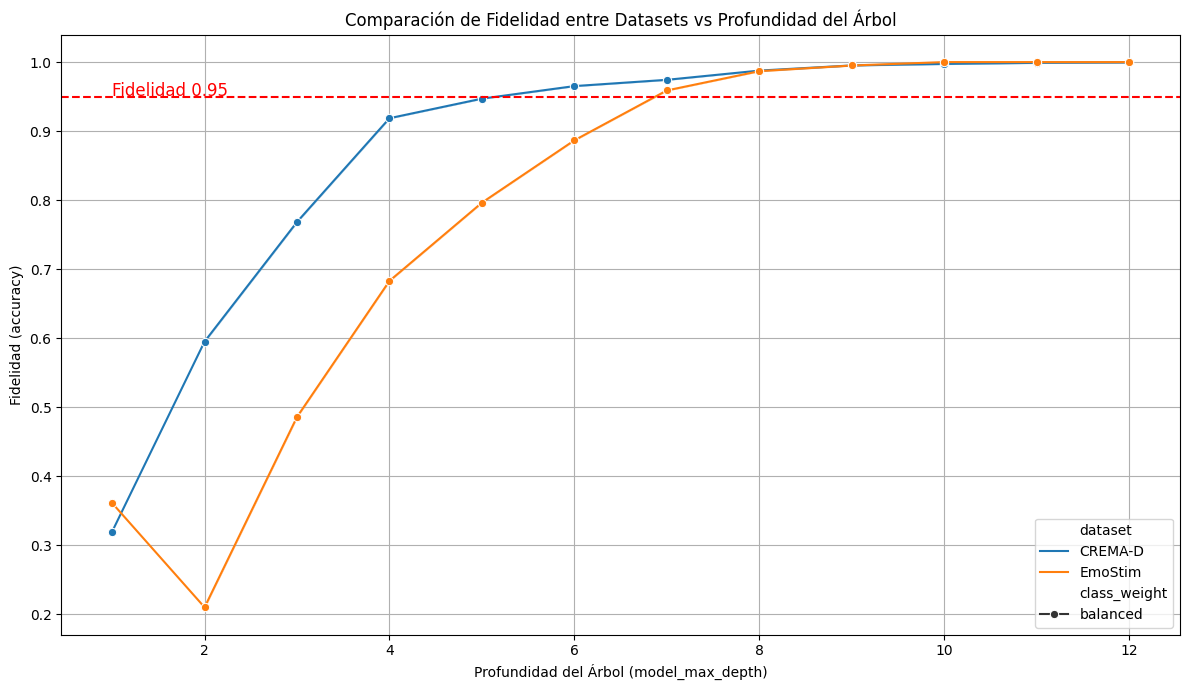

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los CSV y agregar columna para identificar la fuente
df_cremad = pd.read_csv("/content/detalle_export_text_por_depth(Cremad).csv")
df_cremad['dataset'] = 'CREMA-D'

df_otro = pd.read_csv("/content/detalle_export_text_por_depth(Emo).csv")
df_otro['dataset'] = 'EmoStim'  # Cambia esto según el nombre real

# Combinar los datasets
df_total = pd.concat([df_cremad, df_otro], ignore_index=True)


# Filtrar solo un punto por profundidad por combinación de dataset y class_weight
df_unique = df_total.drop_duplicates(subset=['dataset', 'class_weight', 'model_max_depth'])


# Graficar fidelidad vs profundidad, diferenciando por dataset y class_weight
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_total,
    x='model_max_depth',
    y='fidelity',
    hue='dataset',
    style='class_weight',
    markers=True,
    dashes=False
)
# Línea roja horizontal en fidelidad 0.95
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5)
plt.text(
    x=df_total['model_max_depth'].min(),  # Posición X de inicio
    y=0.951,  # Un poco arriba para no tapar la línea
    s='Fidelidad 0.95',
    color='red',
    fontsize=12
)
plt.title("Comparación de Fidelidad entre Datasets vs Profundidad del Árbol")
plt.xlabel("Profundidad del Árbol (model_max_depth)")
plt.ylabel("Fidelidad (accuracy)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Decission Tree example

In [ ]:
import joblib

surrogate_cargado = joblib.load(f"modelo_arbol_surrogate_depth{max_depth}_cw{class_weight}.joblib")
# Mostrar el árbol textual (ejemplo con nombres de features generados)
feature_names = [f"embedding_feature_{i}" for i in range(X_emb.shape[1])]
tree_rules = export_text(surrogate_cargado, max_depth=max_depth, feature_names=feature_names)

print("\n🌳 Árbol textual cargado:\n")
print(tree_rules)


🌳 Árbol textual cargado:

|--- embedding_feature_30339 <= 0.14
|   |--- embedding_feature_28116 <= 0.05
|   |   |--- embedding_feature_91494 <= 0.04
|   |   |   |--- embedding_feature_110069 <= 0.02
|   |   |   |   |--- embedding_feature_102118 <= 0.01
|   |   |   |   |   |--- embedding_feature_27400 <= 0.01
|   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |--- embedding_feature_27400 >  0.01
|   |   |   |   |   |   |--- class: 4
|   |   |   |   |--- embedding_feature_102118 >  0.01
|   |   |   |   |   |--- embedding_feature_5678 <= 0.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- embedding_feature_5678 >  0.00
|   |   |   |   |   |   |--- class: 2
|   |   |   |--- embedding_feature_110069 >  0.02
|   |   |   |   |--- class: 3
|   |   |--- embedding_feature_91494 >  0.04
|   |   |   |--- embedding_feature_58129 <= 0.12
|   |   |   |   |--- class: 0
|   |   |   |--- embedding_feature_58129 >  0.12
|   |   |   |   |--- class: 4
|   |--- embedding_feature_2811

In [ ]:
#Auxiliar models by Decision tree tailor of height example


🔍 Fidelidad surrogate vs modelo CNN+Transformer: 0.75

🧠 Reglas interpretables del surrogate:
|--- feature_10838 <= 0.11
|   |--- feature_110212 <= 0.02
|   |   |--- feature_107765 <= 0.05
|   |   |   |--- feature_21387 <= 0.01
|   |   |   |   |--- class: 0
|   |   |   |--- feature_21387 >  0.01
|   |   |   |   |--- class: 1
|   |   |--- feature_107765 >  0.05
|   |   |   |--- feature_112194 <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- feature_112194 >  0.00
|   |   |   |   |--- class: 0
|   |--- feature_110212 >  0.02
|   |   |--- feature_58252 <= 0.06
|   |   |   |--- feature_90382 <= 0.30
|   |   |   |   |--- class: 0
|   |   |   |--- feature_90382 >  0.30
|   |   |   |   |--- class: 2
|   |   |--- feature_58252 >  0.06
|   |   |   |--- feature_90218 <= 0.36
|   |   |   |   |--- class: 2
|   |   |   |--- feature_90218 >  0.36
|   |   |   |   |--- class: 4
|--- feature_10838 >  0.11
|   |--- feature_58123 <= 0.03
|   |   |--- feature_21612 <= 0.03
|   |   |   |--- class: 0

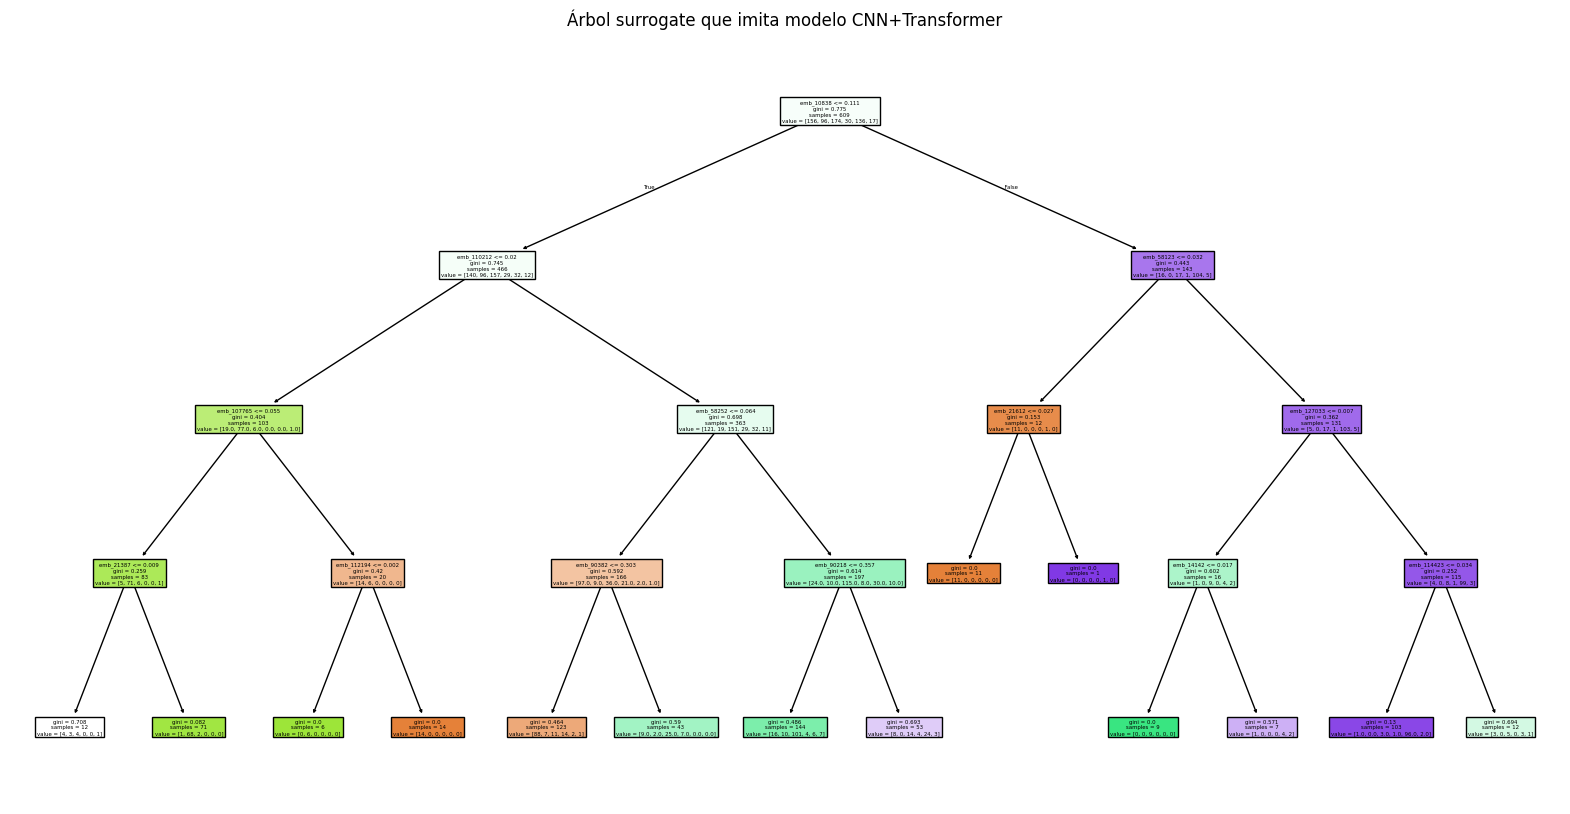

In [ ]:
# --- Entrenar surrogate model (Decision Tree) 2 ---
surrogate = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surrogate.fit(X_emb, y_pred_model)

# --- Evaluar fidelidad ---
fidelidad = accuracy_score(y_pred_model, surrogate.predict(X_emb))
print(f"\n🔍 Fidelidad surrogate vs modelo CNN+Transformer: {fidelidad:.2f}")

# --- Mostrar reglas ---
print("\n🧠 Reglas interpretables del surrogate:")
print(export_text(surrogate, max_depth=6))

# --- Visualizar árbol ---
plt.figure(figsize=(20,10))
plot_tree(surrogate, filled=True, feature_names=[f"emb_{i}" for i in range(X_emb.shape[1])])
plt.title("Árbol surrogate que imita modelo CNN+Transformer")
plt.show()

In [ ]:
#Auxiliar model of Distribution of metrics and models


📂 Procesando archivo: Clips_Peliculas_EmoStim_0.5s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_1s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_2s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_5s.csv

📂 Procesando archivo: Dataset_Cremad_4s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_11s.csv

📂 Procesando archivo: Dataset_Cremad_768_4s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_10s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_3s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_0.5s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_3s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_7s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_9s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_5s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_4s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_9s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_42_4s.csv

📂 Procesando archivo: Clips_Peliculas_EmoStim_6s.csv

📂 Procesando a

,Archivo,Profundidad,Hojas,Precisión,Árbol_txt,Cantidad_Emociones,Grupo
0,Clips_Peliculas_EmoStim_0.5s.csv,3,8,0.510271,/content/arboles_txt/Clips_Peliculas_EmoStim_0...,4,EmoStim
1,Clips_Peliculas_EmoStim_0.5s.csv,4,16,0.524240,/content/arboles_txt/Clips_Peliculas_EmoStim_0...,5,EmoStim
2,Clips_Peliculas_EmoStim_0.5s.csv,5,32,0.530813,/content/arboles_txt/Clips_Peliculas_EmoStim_0...,6,EmoStim
3,Clips_Peliculas_EmoStim_0.5s.csv,6,63,0.533279,/content/arboles_txt/Clips_Peliculas_EmoStim_0...,6,EmoStim
4,Clips_Peliculas_EmoStim_0.5s.csv,7,114,0.535744,/content/arboles_txt/Clips_Peliculas_EmoStim_0...,6,EmoStim
...,...,...,...,...,...,...,...
147,Clips_Peliculas_EmoStim_8s.csv,6,32,0.487179,/content/arboles_txt/Clips_Peliculas_EmoStim_8...,5,EmoStim
148,Clips_Peliculas_EmoStim_8s.csv,7,42,0.525641,/content/arboles_txt/Clips_Peliculas_EmoStim_8...,5,EmoStim
149,Clips_Peliculas_EmoStim_8s.csv,8,50,0.500000,/content/arboles_txt/Clips_Peliculas_EmoStim_8...,5,EmoStim
150,Clips_Peliculas_EmoStim_8s.csv,9,55,0.512821,/content/arboles_txt/Clips_Peliculas_EmoStim_8...,6,EmoStim


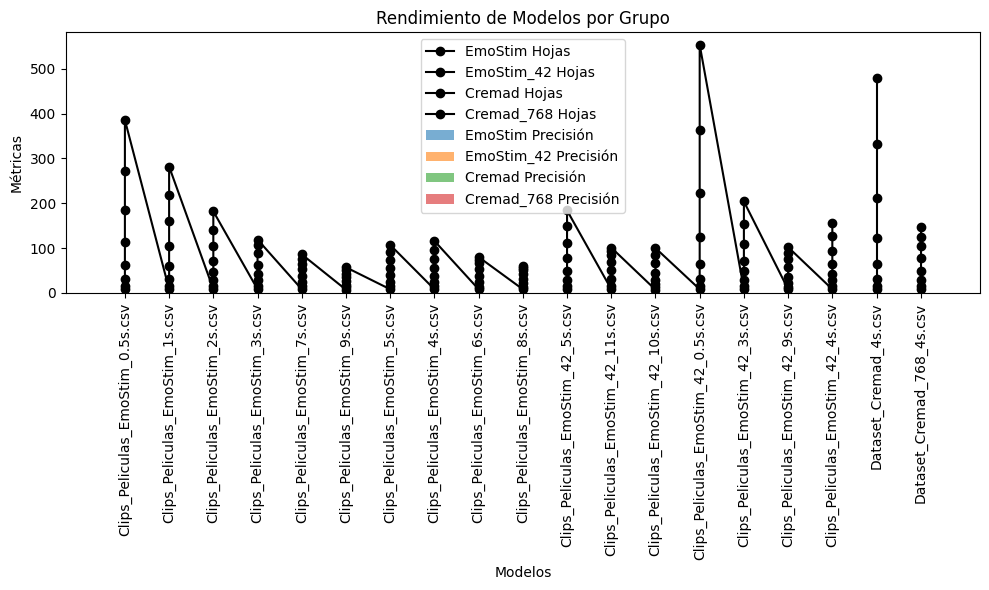

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Carpeta con CSVs y directorio para guardar los árboles
data_folder = '/content/model'
arboles_txt_folder = "/content/arboles_txt"
os.makedirs(arboles_txt_folder, exist_ok=True)

# Para almacenar los resultados
resultados = []

# Recorremos todos los archivos CSV en la carpeta
for filename in os.listdir(data_folder):
    if filename.endswith('.csv'):
        try:
            path = os.path.join(data_folder, filename)
            df = pd.read_csv(path)

            print(f"\n📂 Procesando archivo: {filename}")
            target = 'emotion'

            # Eliminar columnas no necesarias
            drop_cols = ['spectrogram_path', 'id', 'dimensions']
            X = df.drop(columns=[target] + drop_cols, errors='ignore')
            X = pd.get_dummies(X)
            y = df[target]

            # División de datos en entrenamiento y prueba
            X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

            # Modelos para diferentes profundidades del árbol
            for depth in range(3, 11):
                model = DecisionTreeClassifier(max_depth=depth, random_state=42)
                model.fit(X_train, y_train)

                # Predicción y cálculo de la precisión
                y_pred = model.predict(X_test)
                precision = accuracy_score(y_test, y_pred)
                n_hojas = model.get_n_leaves()
                tree_text = export_text(model, feature_names=list(X.columns))
                base_name = os.path.splitext(filename)[0]
                tree_txt_path = os.path.join(arboles_txt_folder, f"{base_name}_depth{depth}.txt")
                with open(tree_txt_path, "w", encoding="utf-8") as f:
                    f.write(tree_text)

                cantidad_emociones = len(set(y_pred))
                # Guardamos los resultados en la lista
                resultados.append({
                    'Archivo': filename,
                    'Profundidad': depth,
                    'Hojas': n_hojas,
                    'Precisión': precision,
                    'Árbol_txt': tree_txt_path,
                    'Cantidad_Emociones': cantidad_emociones
                })

        except Exception as e:
            print(f"❌ Error en {filename}: {e}")

# Convertimos los resultados en un DataFrame
df_resultados = pd.DataFrame(resultados)

# Agrupamos los modelos en 4 grupos específicos
df_resultados['Grupo'] = df_resultados['Archivo'].apply(
    lambda x: 'EmoStim' if 'EmoStim' in x and '42' not in x else
              ('EmoStim_42' if 'EmoStim_42' in x else
               ('Cremad' if 'Cremad' in x and '768' not in x else
                ('Cremad_768' if 'Cremad_768' in x else 'Otro')))
)


# Mostrar los resultados
display(df_resultados)

# Guardamos los resultados en un CSV
df_resultados.to_csv("/content/resultados_modelos.csv", index=False)

# Añadimos una columna con el valor del modelo
df_resultados['Valor_Modelo'] = (df_resultados['Precisión'] * df_resultados['Cantidad_Emociones']) / df_resultados['Hojas']

# Gráfica de la precisión y las hojas por grupo
plt.figure(figsize=(10, 6))

# Generamos un gráfico de barras agrupadas para ver el rendimiento por grupo y la cantidad de hojas
for grupo in df_resultados['Grupo'].unique():
    df_grupo = df_resultados[df_resultados['Grupo'] == grupo]
    plt.bar(df_grupo['Archivo'], df_grupo['Precisión'], label=f'{grupo} Precisión', alpha=0.6)
    plt.plot(df_grupo['Archivo'], df_grupo['Hojas'], label=f'{grupo} Hojas', marker='o', linestyle='-', color='black')

plt.title('Rendimiento de Modelos por Grupo')
plt.xlabel('Modelos')
plt.ylabel('Métricas')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Auxiliar model of a Decision tree with cross validation

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import numpy as np

# Rutas
data_folder = '/content/model'
arboles_txt_folder = "/content/arboles_txt"
os.makedirs(arboles_txt_folder, exist_ok=True)

# Emociones
emociones = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Resultados
resultados = []

# Procesamiento de archivos CSV
for filename in os.listdir(data_folder):
    if filename.endswith('.csv'):
        try:
            path = os.path.join(data_folder, filename)
            df = pd.read_csv(path)

            print(f"\n📂 Procesando archivo: {filename}")
            target = 'emotion'

            drop_cols = ['spectrogram_path', 'id', 'dimensions', 'height', 'width',
                         'sampling_rate', 'window_size', 'hop_size', 'n_fft',
                         'segment_index', 'segment_duration', 'window_function']
            X = df.drop(columns=[target] + drop_cols, errors='ignore')
            X = pd.get_dummies(X)
            y = df[target]

            # Árbol de decisión
            model = DecisionTreeClassifier(random_state=42)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

            # Resultados de precisión y desviación
            precision_values = []
            desviaciones_std = []

            # Calcular la precisión inicial
            cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
            initial_precision = cv_scores.mean()
            precision_values.append(initial_precision)
            print(f"🔹 Precisión inicial: {initial_precision:.6f}")

            # Función para calcular desviación estándar total
            def calcular_desviacion_std_total(df_emociones):
                totales = df_emociones[emociones].sum()
                proporciones = totales / totales.sum()
                return np.std(proporciones)

            # Empezamos con todos los clips y realizamos la eliminación iterativa
            df_actual = df.copy()

            n_max = 41  # máximo de eliminaciones
            for i in range(n_max):  # Eliminar hasta que se queden pocos clips
                mejor_clip = None
                mejor_std = float('inf')

                # Eliminar un clip a la vez y calcular desviación estándar
                for clip in df_actual.index:
                    df_test = df_actual.drop(index=clip)
                    desv_total = calcular_desviacion_std_total(df_test)

                    if desv_total < mejor_std:
                        mejor_std = desv_total
                        mejor_clip = clip

                # Si no mejora la desviación estándar, terminamos
                desv_actual = calcular_desviacion_std_total(df_actual)
                if mejor_std >= desv_actual:
                    print(f"🔔 No se mejora la desviación estándar eliminando más clips. Deteniendo.")
                    break

                # Almacenamos la nueva precisión después de eliminar el clip
                df_test_final = df_actual.drop(index=mejor_clip)
                X_test_final = df_test_final.drop(columns=[target] + drop_cols, errors='ignore')
                X_test_final = pd.get_dummies(X_test_final)
                y_test_final = df_test_final[target]

                # Recalcular precisión después de eliminación
                cv_scores = cross_val_score(model, X_test_final, y_test_final, cv=cv, scoring='accuracy')
                new_precision = cv_scores.mean()
                precision_values.append(new_precision)

                # Recalcular desviación estándar para las emociones
                proporciones = df_test_final[emociones].div(df_test_final[emociones].sum(axis=1), axis=0).fillna(0)
                desv_por_emocion = proporciones.std(ddof=0)
                desviaciones_std.append(desv_por_emocion)

                # Imprimir resultados de cada iteración
                print(f"✅ Iteración {i+1}: eliminado '{mejor_clip}', precisión: {new_precision:.6f}")
                print(f"    Desviaciones std poblacionales proporciones por emoción: {desv_por_emocion.to_dict()}")

                # Eliminar el clip seleccionado
                df_actual = df_actual.drop(index=mejor_clip)

            # Graficar precisión total con cada eliminación
            plt.figure(figsize=(10, 6))
            plt.plot(range(len(precision_values)), precision_values, marker='o', color='blue', label='Precisión Total')
            plt.title(f"Precisión del Modelo con Eliminación de Clips - {filename}")
            plt.xlabel('Número de Eliminaciones')
            plt.ylabel('Precisión')
            plt.grid(True)
            plt.legend()
            plt.show()

            # Graficar desviación estándar por emoción en cada iteración
            for i, desv_std in enumerate(desviaciones_std):
                plt.figure(figsize=(10, 6))
                plt.plot(desv_std.index, desv_std.values, marker='o', label=f"Iteración {i+1}")
                plt.title(f"Desviación Estándar por Emoción - Iteración {i+1} - {filename}")
                plt.xlabel('Emociones')
                plt.ylabel('Desviación Estándar')
                plt.legend()
                plt.grid(True)
                plt.show()

            # Guardar los resultados del modelo en un DataFrame
            resultados.append({
                'Archivo': filename,
                'Precisión_Inicial': precision_values[0],
                'Precisión_Final': precision_values[-1],
                'Número_Eliminaciones': len(precision_values) - 1,
            })

        except Exception as e:
            print(f"❌ Error en {filename}: {e}")

# Crear DataFrame con los resultados
df_resultados = pd.DataFrame(resultados)

# Guardar resultados
df_resultados.to_csv("/content/resultados_modelos_cv_alpha0.csv", index=False)

# Mostrar los resultados de precisión inicial y final para cada archivo
print("\nResumen de Resultados:")
print(df_resultados)



📂 Procesando archivo: Clips_Peliculas_EmoStim_21A_1s.csv
🔹 Precisión inicial: 0.477176
❌ Error en Clips_Peliculas_EmoStim_21A_1s.csv: "None of [Index(['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD'], dtype='object')] are in the [columns]"

📂 Procesando archivo: Clips_Peliculas_EmoStim_21B_1s.csv
🔹 Precisión inicial: 0.428082
❌ Error en Clips_Peliculas_EmoStim_21B_1s.csv: "None of [Index(['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD'], dtype='object')] are in the [columns]"

Resumen de Resultados:
Empty DataFrame
Columns: []
Index: []


In [ ]:
# Graphic of Auxiliar model with Decision tree by precision

<ipython-input-34-92919a05082a>:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


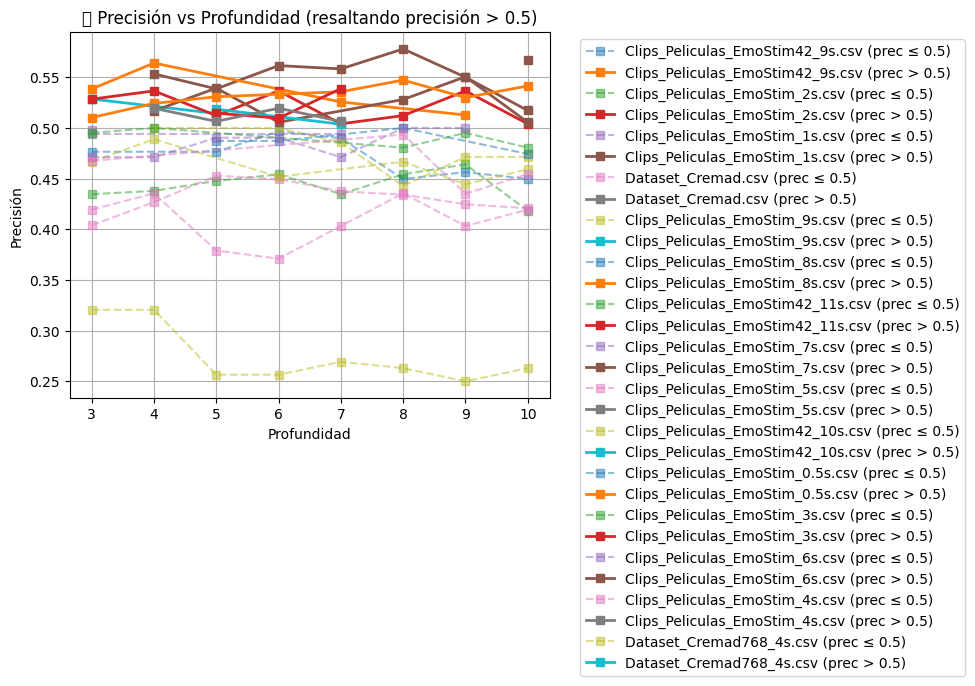

In [ ]:
plt.figure(figsize=(10, 6))
for archivo in df_resultados['Archivo'].unique():
    df_archivo = df_resultados[df_resultados['Archivo'] == archivo]

    buenos = df_archivo[df_archivo['Precisión'] > 0.5]
    malos = df_archivo[df_archivo['Precisión'] <= 0.5]

    plt.plot(malos['Profundidad'], malos['Precisión'], 's--', alpha=0.5, label=f"{archivo} (prec ≤ 0.5)")
    plt.plot(buenos['Profundidad'], buenos['Precisión'], 's-', linewidth=2, label=f"{archivo} (prec > 0.5)")

plt.title('🎯 Precisión vs Profundidad (resaltando precisión > 0.5)')
plt.xlabel('Profundidad')
plt.ylabel('Precisión')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
#Out of investigation for personal notes

In [ ]:
#Implementation of alternative standar desviation in an old generation

In [ ]:
##copy of emotion result start
import os
import librosa
import pandas as pd
import opensmile
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def generate_open_smile_selected_characteristics(audio_segment, sampling_rate=16000):
    # Definir las configuraciones de OpenSMILE para las características
    smiles = {
        "eGeMAPSv02": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02, feature_level=opensmile.FeatureLevel.Functionals),
        "emobase": opensmile.Smile(feature_set=opensmile.FeatureSet.emobase, feature_level=opensmile.FeatureLevel.Functionals),
        "eGeMAPS": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPS, feature_level=opensmile.FeatureLevel.Functionals)
    }

    # Definir los encabezados requeridos para cada conjunto de características
    required_headers = {
        "eGeMAPSv02": ["F0semitoneFrom27.5Hz_sma3nz_amean", "jitterLocal_sma3nz_amean", "shimmerLocaldB_sma3nz_amean", "mfcc1_sma3_amean"],
        "emobase": ["pcm_loudness_sma_amean", "pcm_intensity_sma_amean"],
        "eGeMAPS": ["F1frequency_sma3nz_amean", "F2frequency_sma3nz_amean", "F3frequency_sma3nz_amean"]
    }

    # Inicializar el diccionario para almacenar las características extraídas
    feature_row = {}

    # Convertir el segmento de audio en una estructura que OpenSMILE pueda procesar
    audio_array = audio_segment.astype('float32')  # Asegúrate de que esté en float32
    for name, smile in smiles.items():
        # Procesar el audio directamente en OpenSMILE
        features = smile.process_signal(audio_array, sampling_rate=sampling_rate)

        # Filtrar columnas según `required_headers` para la configuración actual
        if name in required_headers:
            for column in required_headers[name]:
                # Agregar la característica al diccionario `feature_row`
                if column in features.columns:
                    feature_row[column] = features[column].values[0]

    # Retornar las características extraídas como un diccionario
    return feature_row

def predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions):
    # Convertir el espectrograma a imagen y luego a tensor
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(log_mel_spectrogram, sr=16000, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.axis('off')

    # Guardar la imagen temporalmente en memoria
    plt.savefig('temp_spectrogram.png', bbox_inches='tight', pad_inches=0)
    plt.close()

    # Cargar la imagen y convertirla a escala de grises
    img = Image.open('temp_spectrogram.png').convert('L')

    # Aplicar las transformaciones necesarias (Redimensionar, Normalizar, Convertir a Tensor)
    transform = transforms.Compose([
        transforms.Resize((128, 313)),  # Ajusta el tamaño de la imagen al usado en el entrenamiento
        transforms.ToTensor(),          # Convierte la imagen a Tensor
    ])
    img_tensor = transform(img).unsqueeze(0)  # Añadir batch dimension (1, C, H, W)

    # Realizar la predicción
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)

    # Obtener la emoción predecida
    predicted_emotion = valid_emotions[preds.item()]
    return predicted_emotion

def generate_log_mel_spectrogram(audio_array, sampling_rate=16000, n_fft=1024, hop_size=256, window_size=512, normalize=True):
    # Calcular el espectrograma log-Mel
    stft = librosa.stft(audio_array, n_fft=n_fft, hop_length=hop_size, win_length=window_size)
    magnitude = np.abs(stft)
    mel_filter = librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=128)
    mel_spectrogram = np.dot(mel_filter, magnitude)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Normalización (opcional)
    if normalize:
        log_mel_spectrogram = (log_mel_spectrogram - np.mean(log_mel_spectrogram)) / np.std(log_mel_spectrogram)

    return log_mel_spectrogram

# 0. Definir el ConvolutionalStem
class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        return x
valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
# 2. Definir el modelo (Vision Transformer)
class VisionTransformer(nn.Module):
    def __init__(self, num_classes=len(valid_emotions)):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()  # Define tu ConvolutionalStem aquí

        # Determinar el tamaño de entrada dinámicamente
        dummy_input = torch.randn(1, 1, 128, 313)  # Cambia según las dimensiones de tus espectrogramas
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]

        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x
# 8. Inicializar el modelo, criterio y optimizador
model = VisionTransformer(num_classes=len(valid_emotions))
model.load_state_dict(torch.load('modelo_emociones.pth'))
model.eval()  # Muy importante: pon el modelo en modo evaluación



def resumen_por_emocion_y_caracteristica_multiple(folder_path, model, valid_emotions, segment_duration=5, max_duration=None):
    resumen_general = {}

    # Recorrer todos los archivos en la carpeta especificada
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        if not file_path.endswith('.wav'):
            continue  # Solo procesar archivos de audio .wav

        print(f"Procesando archivo: {file_name}")

        sampling_rate = 16000
        y, sr = librosa.load(file_path, sr=sampling_rate)
        segment_length = segment_duration * sr
        num_segments = len(y) // segment_length
        emotions = []
        prosodic_features = []

        if max_duration:
            max_segments = max_duration // segment_duration
            num_segments = min(num_segments, max_segments)

        for i in range(num_segments):
            start = i * segment_length
            end = start + segment_length
            audio_segment = y[start:end]

            log_mel_spectrogram = generate_log_mel_spectrogram(audio_segment, sampling_rate=sampling_rate)
            emotion = predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions)
            prosody = generate_open_smile_selected_characteristics(audio_segment)

            emotions.append((i * segment_duration, emotion))  # (segundo, emoción)
            prosodic_features.append(prosody)

        df = pd.DataFrame(prosodic_features)
        df['emotion'] = [e[1] for e in emotions]

        # Calcular estadísticas
        averages = df.groupby('emotion').mean()
        std_devs = df.groupby('emotion').std()

        # Agregar resultados al resumen general
        for emotion in df['emotion'].unique():
            emotion_data = df[df['emotion'] == emotion]
            total_seconds = len(emotion_data) * segment_duration

            if emotion not in resumen_general:
                resumen_general[emotion] = {
                    'total_segundos': 0,
                    'caracteristicas': {}
                }

            resumen_general[emotion]['total_segundos'] += total_seconds

            for column in df.columns[:-1]:  # sin 'emotion'
                mean = averages.loc[emotion, column]
                std = std_devs.loc[emotion, column]
                lower, upper = mean - std, mean + std

                # Detectar segmentos fuera del rango para esta característica
                outliers = emotion_data[(emotion_data[column] < lower) | (emotion_data[column] > upper)]
                anomalous_seconds = len(outliers) * segment_duration

                if column not in resumen_general[emotion]['caracteristicas']:
                    resumen_general[emotion]['caracteristicas'][column] = {
                        'segundos_con_anomalias': 0,
                        'media': 0,
                        'desviacion_estandar': 0
                    }

                resumen_general[emotion]['caracteristicas'][column]['segundos_con_anomalias'] += anomalous_seconds
                resumen_general[emotion]['caracteristicas'][column]['media'] = mean
                resumen_general[emotion]['caracteristicas'][column]['desviacion_estandar'] = std

    return resumen_general

# Llamar a la función pasando la ruta de la carpeta, el modelo y las emociones válidas
folder_path = '/content/audio'  # Ruta donde se encuentran los archivos de audio
resumen = resumen_por_emocion_y_caracteristica_multiple(folder_path, model, valid_emotions)

# Imprimir el informe consolidado
for emocion, datos in resumen.items():
    print(f"\n🎭 Emoción: {emocion}")
    print(f"  Total de segundos: {datos['total_segundos']}")
    for caracteristica, detalle in datos['caracteristicas'].items():
        print(f"    🧬 {caracteristica}")
        print(f"      Segundos con anomalías: {detalle['segundos_con_anomalias']}")
        print(f"      Media: {detalle['media']:.2f}")
        print(f"      Desviación estándar: {detalle['desviacion_estandar']:.2f}")


Procesando archivo: bojack.wav


/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.eGeMAPS' is deprecated, consider switching to 'FeatureSet.eGeMAPSv02'.
  warnings.warn(
/usr/local/lib/python3.11/dist


🎭 Emoción: SAD
  Total de segundos: 110
    🧬 F0semitoneFrom27.5Hz_sma3nz_amean
      Segundos con anomalías: 35
      Media: 22.07
      Desviación estándar: 3.38
    🧬 jitterLocal_sma3nz_amean
      Segundos con anomalías: 5
      Media: 0.03
      Desviación estándar: 0.02
    🧬 shimmerLocaldB_sma3nz_amean
      Segundos con anomalías: 25
      Media: 1.39
      Desviación estándar: 0.23
    🧬 mfcc1_sma3_amean
      Segundos con anomalías: 20
      Media: 29.03
      Desviación estándar: 2.78
    🧬 pcm_loudness_sma_amean
      Segundos con anomalías: 30
      Media: 0.22
      Desviación estándar: 0.03
    🧬 pcm_intensity_sma_amean
      Segundos con anomalías: 35
      Media: 0.00
      Desviación estándar: 0.00
    🧬 F1frequency_sma3nz_amean
      Segundos con anomalías: 40
      Media: 583.27
      Desviación estándar: 93.40
    🧬 F2frequency_sma3nz_amean
      Segundos con anomalías: 30
      Media: 1519.46
      Desviación estándar: 107.44
    🧬 F3frequency_sma3nz_amean
      

In [ ]:
def procesar_audio_y_detectar_anomalias(file_path, model, valid_emotions, segment_duration=5, max_duration=None):
    sampling_rate = 16000
    y, sr = librosa.load(file_path, sr=sampling_rate)
    segment_length = segment_duration * sr
    num_segments = len(y) // segment_length
    emotions = []
    prosodic_features = []

    if max_duration:
        max_segments = max_duration // segment_duration
        num_segments = min(num_segments, max_segments)

    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        audio_segment = y[start:end]

        # Generar el espectrograma y predecir la emoción
        log_mel_spectrogram = generate_log_mel_spectrogram(audio_segment, sampling_rate=sampling_rate)
        emotion = predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions)

        # Generar las características prosódicas
        prosody = generate_open_smile_selected_characteristics(audio_segment)

        # Guardar las emociones y las características prosódicas
        emotions.append((i * segment_duration, emotion))
        prosodic_features.append(prosody)

    # Convertir las características prosódicas a un DataFrame para su análisis
    df = pd.DataFrame(prosodic_features)
    df['emotion'] = [emotion[1] for emotion in emotions]  # Asignar las emociones a cada segmento

    # Calcular los promedios y desviaciones estándar por emoción
    averages = df.groupby('emotion').mean()
    std_devs = df.groupby('emotion').std()

    # Detectar anomalías en función de las características prosódicas más comunes
    anomalies = {}
    for interval, data in results.items():  # Usando los resultados previos de los intervalos
        # Tomar la emoción más común para este intervalo
        most_common_emotion = data['most_common_emotion']

        # Filtrar las características prosódicas correspondientes a la emoción más común
        emotion_data = df[df['emotion'] == most_common_emotion]

        # Detectar anomalías para cada característica prosódica de este intervalo
        anomalies[interval] = []
        for column in df.columns[:-1]:  # Excluyendo la columna 'emotion'
            mean = averages.loc[most_common_emotion, column]
            std = std_devs.loc[most_common_emotion, column]

            # Rango permitido: media ± desviación estándar
            lower_bound = mean - std
            upper_bound = mean + std

            # Verificar si algún valor está fuera de este rango
            outliers = emotion_data[(emotion_data[column] < lower_bound) | (emotion_data[column] > upper_bound)]
            if not outliers.empty:
                # Contar las ocurrencias y calcular el porcentaje de características fuera de rango
                total_values = len(emotion_data)
                outlier_count = len(outliers)
                outlier_percentage = (outlier_count / total_values) * 100

                anomalies[interval].append({
                    'característica': column,
                    'media': mean,
                    'desviación estándar': std,
                    'valores fuera de rango': outliers[column].tolist(),
                    'conteo de anomalías': outlier_count,
                    'porcentaje de anomalías': outlier_percentage
                })

    return anomalies

# Uso de la función
file_path = '/content/audios/BatmanReturns(1992)_clip_2.wav'
# model = torch.load('modelo_emociones.pth')
# valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Comparar las anomalías para los intervalos
anomalias = procesar_audio_y_detectar_anomalias(file_path, model, valid_emotions)

# Mostrar anomalías detectadas
for interval, anomaly_data in anomalias.items():
    print(f"\nIntervalo de {interval} segundos:")
    if not anomaly_data:
        print("  Sin anomalías detectadas.")
    else:
        for anomaly in anomaly_data:
            print(f"  Característica: {anomaly['característica']}")
            print(f"    Media: {anomaly['media']:.2f}, Desviación estándar: {anomaly['desviación estándar']:.2f}")
            print(f"    Valores fuera de rango: {anomaly['valores fuera de rango']}")
            print(f"    Conteo de anomalías: {anomaly['conteo de anomalías']}")
            print(f"    Porcentaje de anomalías: {anomaly['porcentaje de anomalías']:.2f}%")



Intervalo de 5 segundos:
  Característica: F0semitoneFrom27.5Hz_sma3nz_amean
    Media: 29.85, Desviación estándar: 6.96
    Valores fuera de rango: [38.97930908203125, 18.16904640197754]
    Conteo de anomalías: 2
    Porcentaje de anomalías: 33.33%
  Característica: jitterLocal_sma3nz_amean
    Media: 0.02, Desviación estándar: 0.01
    Valores fuera de rango: [0.015380931086838245, 0.035344645380973816]
    Conteo de anomalías: 2
    Porcentaje de anomalías: 33.33%
  Característica: shimmerLocaldB_sma3nz_amean
    Media: 1.13, Desviación estándar: 0.12
    Valores fuera de rango: [0.9525957703590393, 1.3056143522262573]
    Conteo de anomalías: 2
    Porcentaje de anomalías: 33.33%
  Característica: mfcc1_sma3_amean
    Media: 15.48, Desviación estándar: 6.05
    Valores fuera de rango: [26.67795181274414]
    Conteo de anomalías: 1
    Porcentaje de anomalías: 16.67%
  Característica: pcm_loudness_sma_amean
    Media: 0.35, Desviación estándar: 0.19
    Valores fuera de rango: [0.

In [ ]:

def procesar_audio_y_detectar_anomalias(file_path, model, valid_emotions, segment_duration=5, max_duration=None):
    sampling_rate = 16000
    y, sr = librosa.load(file_path, sr=sampling_rate)
    segment_length = segment_duration * sr
    num_segments = len(y) // segment_length
    emotions = []
    prosodic_features = []

    if max_duration:
        max_segments = max_duration // segment_duration
        num_segments = min(num_segments, max_segments)

    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        audio_segment = y[start:end]

        log_mel_spectrogram = generate_log_mel_spectrogram(audio_segment, sampling_rate=sampling_rate)
        emotion = predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions)
        prosody = generate_open_smile_selected_characteristics(audio_segment)

        emotions.append((i * segment_duration, emotion))
        prosodic_features.append(prosody)

    df = pd.DataFrame(prosodic_features)
    df['emotion'] = [emotion[1] for emotion in emotions]

    averages = df.groupby('emotion').mean()
    std_devs = df.groupby('emotion').std()

    anomalies = {}
    for i, row in df.iterrows():
        interval = i * segment_duration
        emotion = row['emotion']
        emotion_data = df[df['emotion'] == emotion]
        anomalies[interval] = []

        for column in df.columns[:-1]:  # Excluir 'emotion'
            mean = averages.loc[emotion, column]
            std = std_devs.loc[emotion, column]
            value = row[column]
            if value < (mean - std) or value > (mean + std):
                anomalies[interval].append({
                    'característica': column,
                    'valor': value,
                    'media': mean,
                    'desviación estándar': std,
                    'anomalía': True
                })

    return anomalies

def procesar_carpeta_de_audios(folder_path, model, valid_emotions):
    resultados = {}

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".wav"):
            file_path = os.path.join(folder_path, file_name)
            print(f"\nProcesando: {file_name}")
            anomalias = procesar_audio_y_detectar_anomalias(file_path, model, valid_emotions)
            resultados[file_name] = anomalias

    return resultados
folder_path = '/content/audios'
# model = torch.load('modelo_emociones.pth')
# valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

resultados = procesar_carpeta_de_audios(folder_path, model, valid_emotions)

# Mostrar resultados
for archivo, anomalias in resultados.items():
    print(f"\n📂 Archivo: {archivo}")
    for intervalo, datos in anomalias.items():
        print(f"  ⏱ Intervalo {intervalo} seg:")
        if not datos:
            print("    ✅ Sin anomalías")
        else:
            for a in datos:
                print(f"    ⚠️ Característica: {a['característica']}")
                print(f"       Valor: {a['valor']:.3f}, Media: {a['media']:.3f}, STD: {a['desviación estándar']:.3f}")



Procesando: HotelRwanda_clip_8.wav

Procesando: AmericanHistoryX_clip_1.wav

Procesando: InTheNameOfTheFather_clip_1.wav

Procesando: HotelRwanda_clip_4.wav

Procesando: Bambi_clip_2.wav

Procesando: ForrestGump_clip_1.wav

Procesando: HotelRwanda_clip_3.wav

Procesando: ET_clip1.wav

Procesando: KillBill1_clip_2.wav

Procesando: DeadManWalking_clip_1.wav

Procesando: HotelRwanda_clip_1.wav

Procesando: 28DaysLater_clip_3.wav

Procesando: APerfectWorld_clip_1.wav

Procesando: 28DaysLater_clip_6.wav

Procesando: 12YearsASlave_clip_1.wav

Procesando: BatmanReturns(1992)_clip_2.wav

Procesando: 28DaysLater_clip_5.wav

Procesando: 28DaysLater_clip_7.wav

Procesando: DangerousMinds.wav

Procesando: HotelRwanda_clip_7.wav

Procesando: CryFreedom_clip_2.wav

📂 Archivo: HotelRwanda_clip_8.wav
  ⏱ Intervalo 0 seg:
    ⚠️ Característica: F0semitoneFrom27.5Hz_sma3nz_amean
       Valor: 0.000, Media: 32.771, STD: 22.361
    ⚠️ Característica: jitterLocal_sma3nz_amean
       Valor: 0.000, Media: 0

In [ ]:
#Basic elements to count emotion

In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
from collections import Counter

valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Initialize the model *instance*
model = VisionTransformer(num_classes=len(valid_emotions))

# Load the saved state dictionary into the model instance
model.load_state_dict(torch.load('modelo_emociones.pth'))

# Now you can call eval() on the model instance
model.eval()

# Función para generar el log-mel espectrograma
def generate_log_mel_spectrogram(audio_array, sampling_rate=16000, n_fft=1024, hop_size=256, window_size=512, normalize=True):
    # Calcular el espectrograma log-Mel
    stft = librosa.stft(audio_array, n_fft=n_fft, hop_length=hop_size, win_length=window_size)
    magnitude = np.abs(stft)
    mel_filter = librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=128)
    mel_spectrogram = np.dot(mel_filter, magnitude)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Normalización (opcional)
    if normalize:
        log_mel_spectrogram = (log_mel_spectrogram - np.mean(log_mel_spectrogram)) / np.std(log_mel_spectrogram)

    return log_mel_spectrogram
def generate_open_smile_selected_characteristics(file_path):
    # Definir las configuraciones de OpenSMILE para las características
    smiles = {
        "eGeMAPSv02": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02, feature_level=opensmile.FeatureLevel.Functionals),
        "emobase": opensmile.Smile(feature_set=opensmile.FeatureSet.emobase, feature_level=opensmile.FeatureLevel.Functionals),
        "eGeMAPS": opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPS, feature_level=opensmile.FeatureLevel.Functionals)
    }

    # Definir los encabezados requeridos para cada conjunto de características
    required_headers = {
        "eGeMAPSv02": ["F0semitoneFrom27.5Hz_sma3nz_amean", "jitterLocal_sma3nz_amean", "shimmerLocaldB_sma3nz_amean", "mfcc1_sma3_amean"],
        "emobase": ["pcm_loudness_sma_amean", "pcm_intensity_sma_amean"],
        "eGeMAPS": ["F1frequency_sma3nz_amean", "F2frequency_sma3nz_amean", "F3frequency_sma3nz_amean"]
    }

    # Inicializar el diccionario para almacenar las características extraídas
    feature_row = {}

    # Extraer características para cada configuración en `smiles`
    for name, smile in smiles.items():
        # Procesar el archivo de audio
        features = smile.process_file(file_path)

        # Filtrar columnas según `required_headers` para la configuración actual
        if name in required_headers:
            for column in required_headers[name]:
                # Agregar la característica al diccionario `feature_row`
                if column in features.columns:
                    feature_row[column] = features[column].values[0]

    # Retornar las características extraídas como un diccionario
    return feature_row
# Función para predecir la emoción a partir del espectrograma
def predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions):
    # Convertir el espectrograma a imagen y luego a tensor
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(log_mel_spectrogram, sr=16000, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.axis('off')

    # Guardar la imagen temporalmente en memoria
    plt.savefig('temp_spectrogram.png', bbox_inches='tight', pad_inches=0)
    plt.close()

    # Cargar la imagen y convertirla a escala de grises
    img = Image.open('temp_spectrogram.png').convert('L')

    # Aplicar las transformaciones necesarias (Redimensionar, Normalizar, Convertir a Tensor)
    transform = transforms.Compose([
        transforms.Resize((128, 313)),  # Ajusta el tamaño de la imagen al usado en el entrenamiento
        transforms.ToTensor(),          # Convierte la imagen a Tensor
    ])
    img_tensor = transform(img).unsqueeze(0)  # Añadir batch dimension (1, C, H, W)

    # Realizar la predicción
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)

    # Obtener la emoción predecida
    predicted_emotion = valid_emotions[preds.item()]
    return predicted_emotion

# Función principal que procesa el audio y predice las emociones
def process_audio_and_predict(file_path, model, valid_emotions):
    # Generar el espectrograma log-Mel
    log_mel_spectrogram = generate_log_mel_spectrogram(file_path)

    # Guardar el espectrograma como imagen
    spectrogram_filename = f'{file_path[:-4]}_spectrogram.png'  # Nombre del archivo sin extensión .wav
    spectrogram_path = os.path.join('.', spectrogram_filename)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(log_mel_spectrogram, sr=16000, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Log-Mel Spectrogram')
    plt.tight_layout()
    plt.savefig(spectrogram_path)
    plt.close()

    # Predecir la emoción a partir del espectrograma generado
    predicted_emotion = load_and_predict_image(spectrogram_path, model, valid_emotions)
    return predicted_emotion

# Función para procesar el audio en segmentos de 5 segundos y predecir emociones
def process_audio_in_segments_and_predict(file_path, model, valid_emotions, segment_duration=5, max_duration=None):
    sampling_rate = 16000
    y, sr = librosa.load(file_path, sr=sampling_rate)
    segment_length = segment_duration * sr
    num_segments = len(y) // segment_length
    emotions = []

    if max_duration:
        max_segments = max_duration // segment_duration
        num_segments = min(num_segments, max_segments)

    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        audio_segment = y[start:end]

        log_mel_spectrogram = generate_log_mel_spectrogram(audio_segment, sampling_rate=sampling_rate)
        emotion = predict_emotion_from_spectrogram(log_mel_spectrogram, model, valid_emotions)

        start_time_sec = i * segment_duration
        start_time_min = f"{start_time_sec // 60}:{start_time_sec % 60:02d}"
        #print(f"Tiempo {start_time_min}: Emoción predicha - {emotion}")
        emotions.append((start_time_min, emotion))

    return emotions
# Función para analizar el promedio de emociones y comparar resultados
def analyze_emotion_results(emotions_by_segment):
    emotions_only = [emotion for _, emotion in emotions_by_segment]
    emotion_count = Counter(emotions_only)
    total_emotions = len(emotions_only)

    # Calcular el porcentaje de cada emoción
    emotion_percentage = {emotion: (count / total_emotions) * 100 for emotion, count in emotion_count.items()}

    # Obtener la emoción más común
    most_common_emotion = emotion_count.most_common(1)[0][0]

    return most_common_emotion, emotion_count, emotion_percentage

# Función para comparar resultados de diferentes intervalos de tiempo
def compare_intervals(file_path, model, valid_emotions, intervals=[1, 2, 3, 4, 5], max_duration=60):
    results = {}
    for interval in intervals:
        # Procesar el audio en segmentos de acuerdo al intervalo
        emotions = process_audio_in_segments_and_predict(
            file_path, model, valid_emotions, segment_duration=interval, max_duration=max_duration
        )

        # Analizar resultados y obtener el conteo y porcentaje de emociones
        most_common_emotion, emotion_count, emotion_percentage = analyze_emotion_results(emotions)

        # Guardar los resultados en el diccionario
        results[interval] = {
            'emotions': emotions,
            'most_common_emotion': most_common_emotion,
            'emotion_count': emotion_count,
            'emotion_percentage': emotion_percentage
        }

    return results

# Ejemplo de uso
file_path = '/content/output_audio/concatenated_audio.wav'  # Ruta del archivo de audio
#model = torch.load('modelo_emociones.pth')  # Cargar tu modelo previamente entrenado
#valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Comparar emociones para intervalos de tiempo de 1 a 5 segundos con un límite de 60 segundos
results = compare_intervals(file_path, model, valid_emotions, intervals=[1, 2, 3, 4, 5], max_duration=20)

# Mostrar los resultados
for interval, data in results.items():
    print(f"\nIntervalo de {interval} segundos:")
    print(f"  Emoción más común: {data['most_common_emotion']}")
    print(f"  Conteo de emociones: {data['emotion_count']}")
    print(f"  Porcentaje de emociones: {data['emotion_percentage']}")
    print(f"  Emociones predichas por tiempo: {data['emotions']}")
#print("Cada 1 s",process_audio_in_segments_and_predict(file_path, model, valid_emotions,1,120))

<ipython-input-46-7e23c58a4e8c>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('modelo_emociones.pth'))



Intervalo de 1 segundos:
  Emoción más común: SAD
  Conteo de emociones: Counter({'SAD': 9, 'HAP': 7, 'FEA': 3, 'DIS': 1})
  Porcentaje de emociones: {'SAD': 45.0, 'HAP': 35.0, 'FEA': 15.0, 'DIS': 5.0}
  Emociones predichas por tiempo: [('0:00', 'SAD'), ('0:01', 'SAD'), ('0:02', 'SAD'), ('0:03', 'SAD'), ('0:04', 'SAD'), ('0:05', 'HAP'), ('0:06', 'FEA'), ('0:07', 'HAP'), ('0:08', 'HAP'), ('0:09', 'FEA'), ('0:10', 'SAD'), ('0:11', 'SAD'), ('0:12', 'HAP'), ('0:13', 'HAP'), ('0:14', 'HAP'), ('0:15', 'DIS'), ('0:16', 'FEA'), ('0:17', 'SAD'), ('0:18', 'SAD'), ('0:19', 'HAP')]

Intervalo de 2 segundos:
  Emoción más común: DIS
  Conteo de emociones: Counter({'DIS': 4, 'FEA': 2, 'SAD': 2, 'HAP': 2})
  Porcentaje de emociones: {'FEA': 20.0, 'SAD': 20.0, 'DIS': 40.0, 'HAP': 20.0}
  Emociones predichas por tiempo: [('0:00', 'FEA'), ('0:02', 'SAD'), ('0:04', 'DIS'), ('0:06', 'HAP'), ('0:08', 'FEA'), ('0:10', 'SAD'), ('0:12', 'DIS'), ('0:14', 'HAP'), ('0:16', 'DIS'), ('0:18', 'DIS')]

Intervalo de

In [ ]:
#Modelo auxiliar Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(spectrogram_images_resized, spectrogram_emotions, test_size=0.3, random_state=42)

# Entrenar un modelo de Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7000


In [ ]:
#Alternative analisi of the category 'intensity' by a vocal characteristic

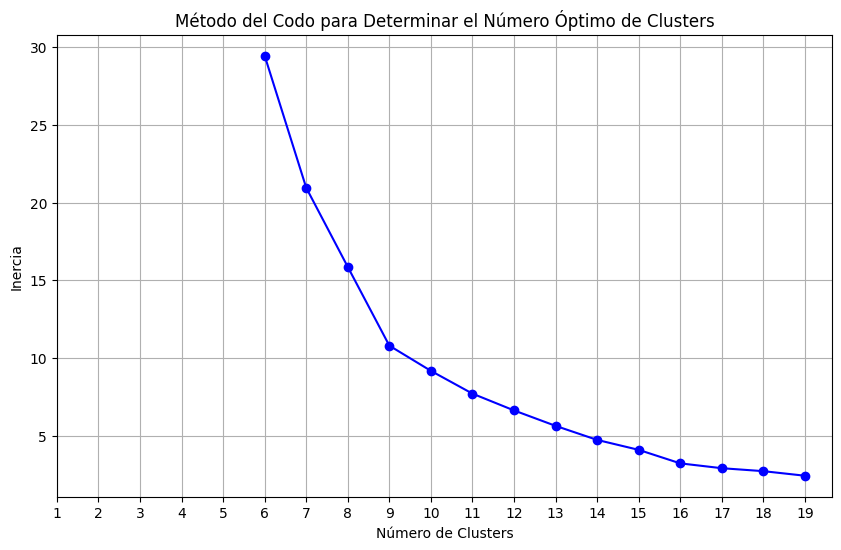

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Usamos solo la columna de intensidad
intensity = df[['pcm_intensity_sma_amean']]

# Normalizamos los datos
scaler = StandardScaler()
intensity_scaled = scaler.fit_transform(intensity)

# Calcular el codo
inertia = []
for k in range(6, 20):  # Probar de 1 a 10 clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(intensity_scaled)
    inertia.append(kmeans.inertia_)

# Visualizar el codo
plt.figure(figsize=(10, 6))
plt.plot(range(6, 20), inertia, marker='o', color='b')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.xticks(range(1, 20))
plt.grid(True)
plt.show()


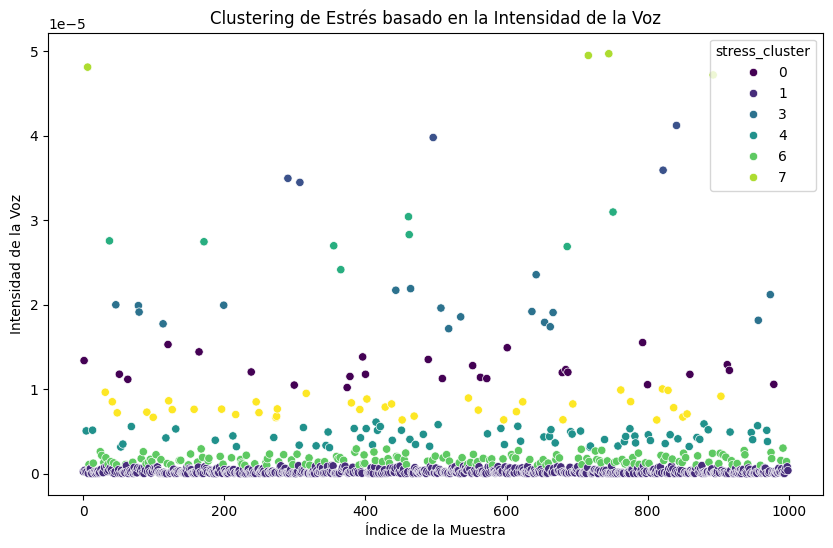

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_csv('metadata.csv')  # Asegúrate de poner la ruta correcta del archivo

# Seleccionar solo la columna de intensidad
intensity = df[['pcm_intensity_sma_amean']]

# Normalizar la intensidad
scaler = StandardScaler()
intensity_scaled = scaler.fit_transform(intensity)

# Aplicar K-Means para el clustering
kmeans = KMeans(n_clusters=9, random_state=42)  # Número de clusters basado en el patrón de estrés
df['stress_cluster'] = kmeans.fit_predict(intensity_scaled)

# Visualizar los clusters en un gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df['pcm_intensity_sma_amean'], hue=df['stress_cluster'], palette='viridis')
plt.title('Clustering de Estrés basado en la Intensidad de la Voz')
plt.xlabel('Índice de la Muestra')
plt.ylabel('Intensidad de la Voz')
plt.show()


In [ ]:
#Alternative with Heatmap patrons search

Epoch [1/10], Loss: 3.1441
Epoch [2/10], Loss: 1.9413
Epoch [3/10], Loss: 1.6357
Epoch [4/10], Loss: 1.0783
Epoch [5/10], Loss: 0.7457
Epoch [6/10], Loss: 0.5196
Epoch [7/10], Loss: 0.5694
Epoch [8/10], Loss: 0.4019
Epoch [9/10], Loss: 0.2188
Epoch [10/10], Loss: 0.1801
Accuracy: 76.50%
Modelo guardado.


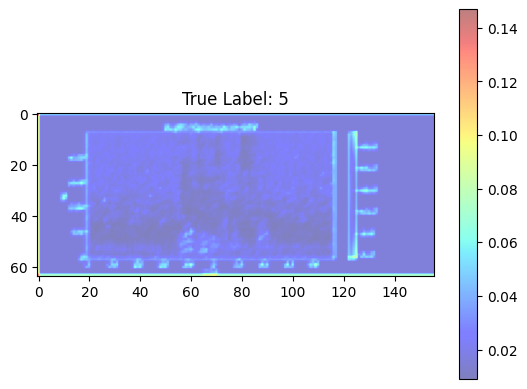

Entrenamiento, evaluación y visualización completados.


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 0. Definir el ConvolutionalStem
class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

# 1. Definir el dataset
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_file, spectrogram_dir, transform=None):
        self.metadata = pd.read_csv(metadata_file)
        self.spectrogram_dir = spectrogram_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_path = os.path.join(self.spectrogram_dir, self.metadata.iloc[idx]['id'])
        emotion = self.metadata.iloc[idx]['emotion']

        # Cargar la imagen
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)

        label = valid_emotions.index(emotion)
        return image, label

# 2. Definir el modelo (Vision Transformer)
class VisionTransformer(nn.Module):
    def __init__(self, num_classes=6):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()

        # Determinar el tamaño de entrada dinámicamente
        dummy_input = torch.randn(1, 1, 128, 313)
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]

        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def get_activations(self, x):
        x = self.convolutional_stem(x)
        return x  # Devuelve las activaciones de la capa convolucional

# 3. Definir la función de entrenamiento
def train_model(model, dataloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# 4. Configurar transformaciones y datos
transform = transforms.Compose([
    transforms.Resize((128, 313)),
    transforms.ToTensor(),
])

# 5. Crear el dataset
dataset = SpectrogramDataset(metadata_file='metadata.csv',
                             spectrogram_dir='spectrograms',
                             transform=transform)

# 6. Dividir el dataset en entrenamiento y validación
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 7. Crear DataLoaders para entrenamiento y validación
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 8. Inicializar el modelo, criterio y optimizador
model = VisionTransformer(num_classes=len(valid_emotions))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 9. Entrenar el modelo
train_model(model, train_dataloader, criterion, optimizer, num_epochs=10)

# 10. Evaluar el modelo
def evaluate_model(model, dataloader):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy: {accuracy * 100:.2f}%')

# 11. Evaluar el modelo en el conjunto de validación
evaluate_model(model, val_dataloader)

# 12. Guardar el modelo entrenado
torch.save(model.state_dict(), 'modelo_entrenado.pth')
print("Modelo guardado.")

# 13. Función para visualizar el mapa de calor
def plot_heatmap(model, dataloader, index):
    model.eval()
    with torch.no_grad():
        images, labels = next(iter(dataloader))
        image = images[index].unsqueeze(0)  # Selecciona la imagen deseada
        true_label = labels[index].item()

        # Obtener activaciones
        activations = model.get_activations(image)

        # Calcular el mapa de calor
        heatmap = activations.squeeze().cpu().numpy()
        heatmap = np.mean(heatmap, axis=0)

        # Visualizar
        plt.imshow(heatmap, cmap='jet', alpha=0.5)
        plt.title(f'True Label: {true_label}')
        plt.colorbar()
        plt.show()

# 14. Visualizar el mapa de calor para una imagen específica
plot_heatmap(model, val_dataloader, index=0)  # Cambia el índice según lo que desees visualizar

print("Entrenamiento, evaluación y visualización completados.")


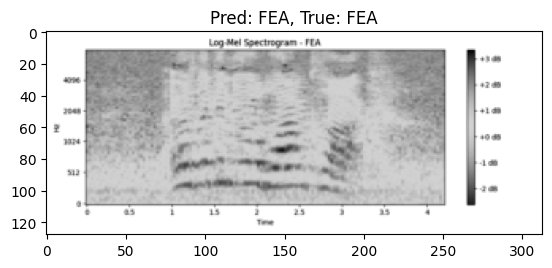

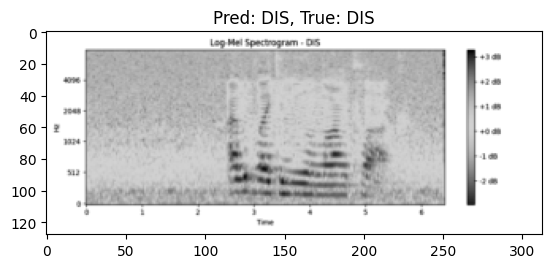

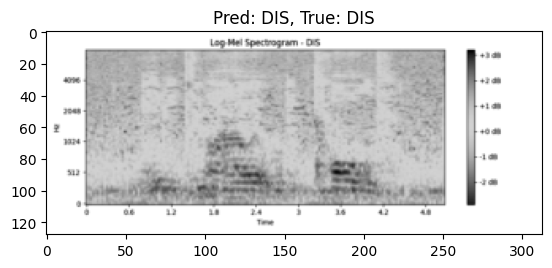

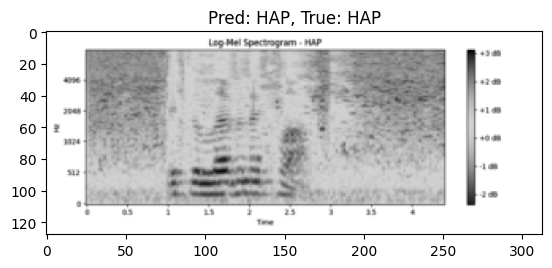

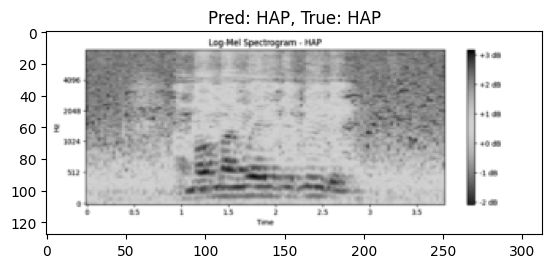

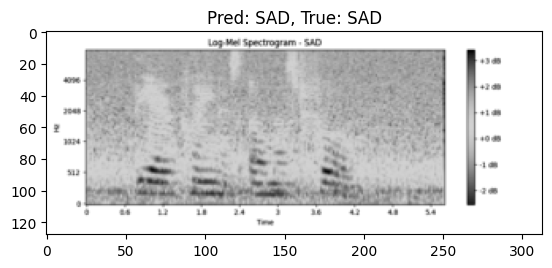

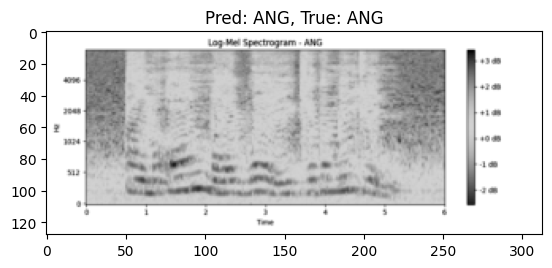

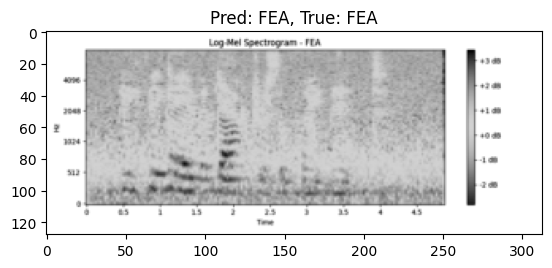

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(dataloader):
    model.eval()
    with torch.no_grad():
        for i, (images, labels) in enumerate(dataloader):
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for j in range(4):  # Visualizar los primeros 4 ejemplos de cada batch
                plt.imshow(images[j].cpu().squeeze(), cmap='gray')
                plt.title(f'Pred: {valid_emotions[preds[j]]}, True: {valid_emotions[labels[j]]}')
                plt.show()

            if i >= 1:  # Solo mostrar un par de batches
                break

plot_predictions(val_dataloader)


In [ ]:
#First model to archive more than 70%

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from sklearn.metrics import accuracy_score

valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# 0. Definir el ConvolutionalStem
class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

# 1. Definir el dataset
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_file, spectrogram_dir, transform=None):
        self.metadata = pd.read_csv(metadata_file)
        self.spectrogram_dir = spectrogram_dir  # Store the directory of spectrograms
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_path = os.path.join(self.spectrogram_dir, self.metadata.iloc[idx]['id'])  # Join with spectrogram dir
        emotion = self.metadata.iloc[idx]['emotion']

        # Cargar la imagen
        image = Image.open(img_path).convert('L')  # Convertir a escala de grises
        if self.transform:
            image = self.transform(image)

        # Convertir la etiqueta a un índice
        label = valid_emotions.index(emotion)
        return image, label

# 2. Definir el modelo (Vision Transformer)
class VisionTransformer(nn.Module):
    def __init__(self, num_classes=len(valid_emotions)):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()  # Define tu ConvolutionalStem aquí

        # Determinar el tamaño de entrada dinámicamente
        dummy_input = torch.randn(1, 1, 128, 313)  # Cambia según las dimensiones de tus espectrogramas
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]

        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# 3. Definir la función de entrenamiento
def train_model(model, dataloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# 4. Configurar transformaciones y datos
transform = transforms.Compose([
    transforms.Resize((128, 313)),  # Ajusta al tamaño que necesita tu modelo
    transforms.ToTensor(),            # Convierte a tensor
])

# 5. Crear el dataset
dataset = SpectrogramDataset(metadata_file='metadata.csv',
                             spectrogram_dir='spectrograms',  # Pass the spectrogram directory
                             transform=transform)

# 6. Dividir el dataset en entrenamiento y validación
train_size = int(0.8 * len(dataset))  # 80% para entrenamiento
val_size = len(dataset) - train_size   # 20% para validación
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 7. Crear DataLoaders para entrenamiento y validación
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 8. Inicializar el modelo, criterio y optimizador
model = VisionTransformer(num_classes=len(valid_emotions))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 9. Entrenar el modelo
train_model(model, train_dataloader, criterion, optimizer, num_epochs=10)

# 10. Evaluar el modelo
def evaluate_model(model, dataloader):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy: {accuracy * 100:.2f}%')

# 11. Evaluar el modelo en el conjunto de validación
evaluate_model(model, val_dataloader)
print("Entrenamiento y evaluación completados.")
torch.save(model.state_dict(), 'modelo_emociones.pth')
print("Modelo guardado como 'modelo_emociones.pth'")

Epoch [1/10], Loss: 2.1648
Epoch [2/10], Loss: 1.3407
Epoch [3/10], Loss: 0.8605
Epoch [4/10], Loss: 0.9315
Epoch [5/10], Loss: 0.5766
Epoch [6/10], Loss: 0.3471
Epoch [7/10], Loss: 0.3966
Epoch [8/10], Loss: 0.1261
Epoch [9/10], Loss: 0.2347
Epoch [10/10], Loss: 0.0893
Accuracy: 95.00%
Entrenamiento y evaluación completados.
Modelo guardado como 'modelo_emociones.pth'


In [ ]:
#Example of multiple training for score


== Entrenando modelo #1 ==
    Epoch [1/10] - Loss: 2.3872
    Epoch [2/10] - Loss: 0.9378
    Epoch [3/10] - Loss: 0.5727
    Epoch [4/10] - Loss: 0.3535
    Epoch [5/10] - Loss: 0.2284
    Epoch [6/10] - Loss: 0.1373
    Epoch [7/10] - Loss: 0.0920
    Epoch [8/10] - Loss: 0.0578
    Epoch [9/10] - Loss: 0.0401
    Epoch [10/10] - Loss: 0.0284

Accuracy en validación: 98.05%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.980     0.968     0.974       253
         DIS      0.981     1.000     0.990       254
         FEA      1.000     0.969     0.984       254
         HAP      0.948     1.000     0.973       253
         NEU      0.991     0.995     0.993       217
         SAD      0.988     0.953     0.970       253

    accuracy                          0.980      1484
   macro avg      0.981     0.981     0.981      1484
weighted avg      0.981     0.980     0.980      1484



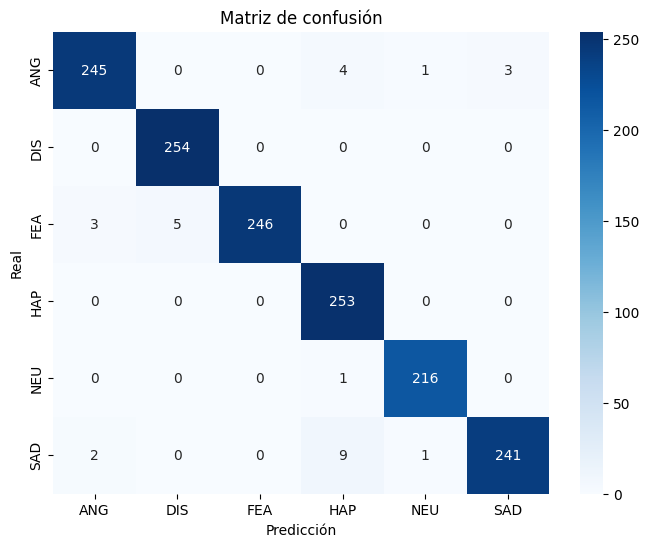

💾 Modelo #1 guardado como 'modelo_1_acc_98_20250426_113056.pth'
✔ Mejor modelo actualizado (98.05%)

== Entrenando modelo #2 ==
    Epoch [1/10] - Loss: 4.1290
    Epoch [2/10] - Loss: 0.8455
    Epoch [3/10] - Loss: 0.5311
    Epoch [4/10] - Loss: 0.3185
    Epoch [5/10] - Loss: 0.1914
    Epoch [6/10] - Loss: 0.1153
    Epoch [7/10] - Loss: 0.0732
    Epoch [8/10] - Loss: 0.0476
    Epoch [9/10] - Loss: 0.0315
    Epoch [10/10] - Loss: 0.0229

Accuracy en validación: 98.32%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.951     0.988     0.969       253
         DIS      0.992     1.000     0.996       254
         FEA      1.000     0.976     0.988       254
         HAP      1.000     0.976     0.988       253
         NEU      0.977     1.000     0.989       217
         SAD      0.980     0.960     0.970       253

    accuracy                          0.983      1484
   macro avg      0.983     0.984     0.983      1484
weighted

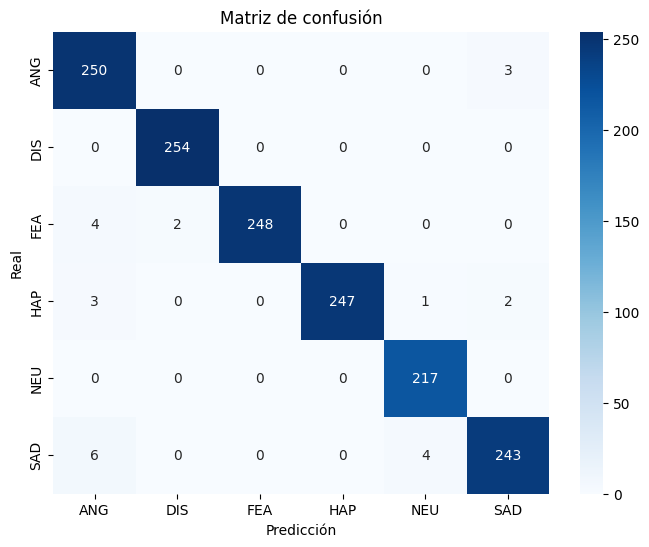

💾 Modelo #2 guardado como 'modelo_2_acc_98_20250426_113056.pth'
✔ Mejor modelo actualizado (98.32%)

== Entrenando modelo #3 ==
    Epoch [1/10] - Loss: 3.3946
    Epoch [2/10] - Loss: 0.9342
    Epoch [3/10] - Loss: 0.6476
    Epoch [4/10] - Loss: 0.4298
    Epoch [5/10] - Loss: 0.2770
    Epoch [6/10] - Loss: 0.1767
    Epoch [7/10] - Loss: 0.1144
    Epoch [8/10] - Loss: 0.0713
    Epoch [9/10] - Loss: 0.0462
    Epoch [10/10] - Loss: 0.0308

Accuracy en validación: 98.72%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.969     0.980     0.974       253
         DIS      0.996     0.996     0.996       254
         FEA      1.000     0.980     0.990       254
         HAP      1.000     0.988     0.994       253
         NEU      0.991     1.000     0.995       217
         SAD      0.969     0.980     0.974       253

    accuracy                          0.987      1484
   macro avg      0.987     0.987     0.987      1484
weighted

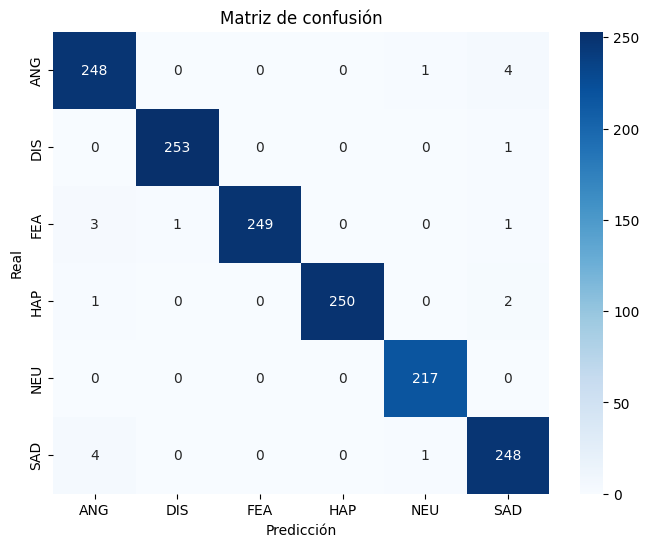

💾 Modelo #3 guardado como 'modelo_3_acc_98_20250426_113056.pth'
✔ Mejor modelo actualizado (98.72%)

== Entrenando modelo #4 ==
    Epoch [1/10] - Loss: 3.4279
    Epoch [2/10] - Loss: 0.8859
    Epoch [3/10] - Loss: 0.5684
    Epoch [4/10] - Loss: 0.3678
    Epoch [5/10] - Loss: 0.2291
    Epoch [6/10] - Loss: 0.1372
    Epoch [7/10] - Loss: 0.0839
    Epoch [8/10] - Loss: 0.0554
    Epoch [9/10] - Loss: 0.0357
    Epoch [10/10] - Loss: 0.0255

Accuracy en validación: 98.79%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.962     0.988     0.975       253
         DIS      1.000     1.000     1.000       254
         FEA      1.000     0.984     0.992       254
         HAP      1.000     0.996     0.998       253
         NEU      0.977     1.000     0.989       217
         SAD      0.988     0.960     0.974       253

    accuracy                          0.988      1484
   macro avg      0.988     0.988     0.988      1484
weighted

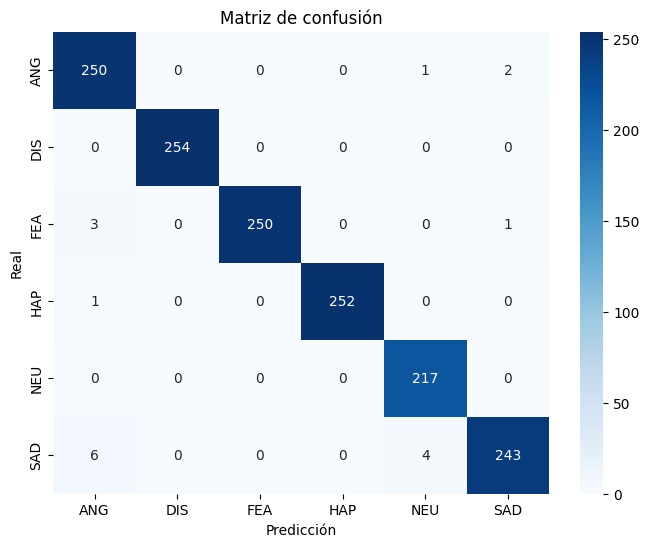

💾 Modelo #4 guardado como 'modelo_4_acc_98_20250426_113056.pth'
✔ Mejor modelo actualizado (98.79%)

== Entrenando modelo #5 ==
    Epoch [1/10] - Loss: 3.0972
    Epoch [2/10] - Loss: 0.9237
    Epoch [3/10] - Loss: 0.6238
    Epoch [4/10] - Loss: 0.4135
    Epoch [5/10] - Loss: 0.2467
    Epoch [6/10] - Loss: 0.1439
    Epoch [7/10] - Loss: 0.0837
    Epoch [8/10] - Loss: 0.0504
    Epoch [9/10] - Loss: 0.0343
    Epoch [10/10] - Loss: 0.0235

Accuracy en validación: 98.79%

F1-score por emoción:
              precision    recall  f1-score   support

         ANG      0.980     0.980     0.980       253
         DIS      0.996     1.000     0.998       254
         FEA      1.000     0.988     0.994       254
         HAP      0.984     1.000     0.992       253
         NEU      0.982     0.995     0.989       217
         SAD      0.984     0.964     0.974       253

    accuracy                          0.988      1484
   macro avg      0.988     0.988     0.988      1484
weighted

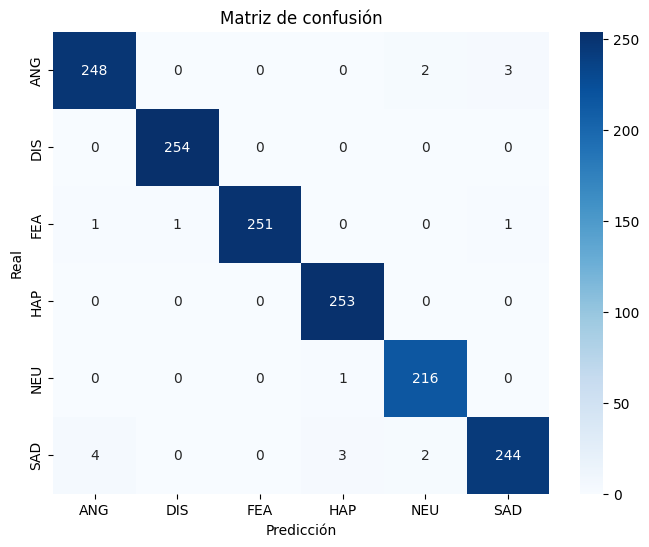

💾 Modelo #5 guardado como 'modelo_5_acc_98_20250426_113056.pth'

== Entrenando modelo #6 ==
    Epoch [1/10] - Loss: 4.5706
    Epoch [2/10] - Loss: 0.7933
    Epoch [3/10] - Loss: 0.4899
    Epoch [4/10] - Loss: 0.2816
    Epoch [5/10] - Loss: 0.1284
    Epoch [6/10] - Loss: 0.0634
    Epoch [7/10] - Loss: 0.0363
    Epoch [8/10] - Loss: 0.0232


In [ ]:
import os
import json
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from datetime import datetime
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clases válidas
valid_emotions = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# ========== CARGA DE DATOS ==========

# Cargar los archivos CSV correctos
emotions_df = pd.read_csv("/content/cremad/features/emotions_metadata.csv")
features_df = pd.read_csv("/content/cremad/features/features_combined.csv")

metadata = pd.merge(features_df, emotions_df, on='id')


# Separar en entrenamiento y validación estratificados
train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata["emotion"], random_state=42)

# Transformaciones
input_size = (128, 313)
transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
])


# Dataset con path completo ya incluido
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_df, transform=None):
        self.metadata = metadata_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_path = self.metadata.iloc[idx]['spectrogram_path']
        emotion = self.metadata.iloc[idx]['emotion']
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label = valid_emotions.index(emotion)
        return image, label

# Crear datasets y loaders
train_dataset = SpectrogramDataset(train_df, transform=transform)
val_dataset = SpectrogramDataset(val_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

class ConvolutionalStem(nn.Module):
    def __init__(self):
        super(ConvolutionalStem, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, input_size=(128, 313), num_classes=len(valid_emotions)):
        super(VisionTransformer, self).__init__()
        self.convolutional_stem = ConvolutionalStem()
        dummy_input = torch.randn(1, 1, *input_size)
        dummy_output = self.convolutional_stem(dummy_input)
        self.fc_input_size = dummy_output.view(dummy_output.size(0), -1).shape[1]
        self.fc = nn.Linear(self.fc_input_size, num_classes)

    def forward(self, x):
        x = self.convolutional_stem(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Función para entrenamiento
def train_model(model, dataloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        print(f"    Epoch [{epoch + 1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

# Evaluación con métricas
def evaluate_model_detailed(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=valid_emotions, digits=3, output_dict=True)
    print(f"\nAccuracy en validación: {acc * 100:.2f}%")
    print("\nF1-score por emoción:")
    print(classification_report(y_true, y_pred, target_names=valid_emotions, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=valid_emotions, yticklabels=valid_emotions)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de confusión')
    plt.show()

    metricas_por_clase = {
        emo: {
            'precision': report[emo]['precision'],
            'recall': report[emo]['recall'],
            'f1': report[emo]['f1-score']
        } for emo in valid_emotions
    }

    return acc, metricas_por_clase

# Función principal de entrenamiento múltiple
def entrenar_varios_modelos(n_modelos, input_size, train_loader, val_loader, valid_emotions, guardar=True):
    mejores_accuracies = []
    mejor_modelo = None
    mejor_acc = 0.0
    resultados_modelos = []

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # Moverlo aquí arriba para reutilizar

    for run in range(n_modelos):
        print(f"\n== Entrenando modelo #{run + 1} ==")
        model = VisionTransformer(input_size=input_size)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        train_model(model, train_loader, criterion, optimizer, num_epochs=10)
        acc, metricas = evaluate_model_detailed(model, val_loader)
        mejores_accuracies.append(acc * 100)

        for emo in valid_emotions:
            resultados_modelos.append({
                'modelo': run + 1,
                'emotion': emo,
                'precision': metricas[emo]['precision'],
                'recall': metricas[emo]['recall'],
                'f1': metricas[emo]['f1'],
                'accuracy': acc
            })

        # Guardar este modelo con su número y accuracy
        model_filename = f"modelo_{run + 1}_acc_{int(acc * 100)}_{timestamp}.pth"
        torch.save(model.state_dict(), model_filename)
        print(f"💾 Modelo #{run + 1} guardado como '{model_filename}'")

        # Actualizar si es el mejor modelo
        if acc > mejor_acc:
            mejor_acc = acc
            mejor_modelo = model.state_dict()
            mejor_modelo_filename = model_filename  # Guardar nombre del mejor
            print(f"✔ Mejor modelo actualizado ({mejor_acc * 100:.2f}%)")


    # Guardar métricas en CSV
    if guardar:
        df_resultados = pd.DataFrame(resultados_modelos)
        df_resultados.to_csv(f"metricas_modelos_{timestamp}.csv", index=False)
        print(f"📄 Métricas guardadas en 'metricas_modelos_{timestamp}.csv'")

        if mejor_modelo:
            torch.save(mejor_modelo, mejor_modelo_filename)
            print(f"🏆 Mejor modelo: '{mejor_modelo_filename}' con accuracy de {mejor_acc * 100:.2f}%")


    # Graficar evolución del accuracy
    plt.plot(range(1, n_modelos + 1), mejores_accuracies, marker='o', color='green')
    plt.title("Accuracy por modelo entrenado")
    plt.xlabel("Número de modelos")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.show()

    return mejores_accuracies

# ========= EJECUTAR ENTRENAMIENTO =========
n_modelos = 10
accuracies = entrenar_varios_modelos(
    n_modelos,
    input_size,
    train_loader,
    val_loader,
    valid_emotions,
    guardar=True
)
